First, create a new conda environment named BI2025 and install the required packages from requirements.txt


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


In [2]:
import numpy as np, scipy, sklearn, matplotlib
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)


numpy: 2.4.1
scipy: 1.16.3
sklearn: 1.8.0
matplotlib: 3.10.7


In [3]:
import numpy, pandas, scipy, sklearn, matplotlib
print("OK – core packages are installed")


OK – core packages are installed


In [4]:
import sys
print("Python:", sys.executable)


Python: C:\conda_envs\BI2025\python.exe


In [5]:
#!conda create -n BI2025 python=3.11 -y
#!conda activate BI2025
#!pip install -r requirements.txt

In [6]:
import sys
print(sys.executable)

C:\conda_envs\BI2025\python.exe


## Graph-based documentation preliminaries

**!!!IMPORTANT!!!**

Everytime you work on this notebook, enter your student ID in the `executed_by` variable so that the cell executions are accredited to you.

In [7]:
executed_by ='stud-id_12432933'  # Replace the digits after "id_" with your own student ID
#executed_by ='stud-id_01529258'

Set your group and student IDs. Do this only once.

In [8]:
# DO NOT MODIFY OR COPY THIS CELL!!
# Note: The only imports allowed are Python's standard library, pandas, numpy, scipy, matplotlib, seaborn and scikit-learn
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import plotly.express as px
import datetime
import typing
import requests
import time
import shutil
import json
from starvers.starvers import TripleStoreEngine

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [10]:
#!pip install git+https://github.com/AllStarsAT/starvers.git

In [11]:
def now_dt_utc():
    from datetime import datetime, timezone
    return datetime.now(timezone.utc)

def q_ts(query: str):
    return engine.query(query, yn_timestamp_query=True, timestamp=now_dt_utc(), as_df=True)


In [12]:
# group id for this project
group_id = '13'  # Replace the digits with your group id

# Students working on this notebook
student_a = 'stud-id_12432933'  # Replace the digits after "id_" with student A's student ID
student_b = 'stud-id_01529258'  # Replace the digits after "id_" with student B's student ID

In [13]:
# Roles. Don't change these values.
code_writer_role = 'code_writer'
code_executor_role = 'code_executor'

Setup the starvers API for logging your steps into our server-sided graph database.

In [14]:
get_endpoint = "https://starvers.ec.tuwien.ac.at/BI2025"
post_endpoint = "https://starvers.ec.tuwien.ac.at/BI2025/statements"
engine = TripleStoreEngine(get_endpoint, post_endpoint, skip_connection_test=True)

Use these prefixes in your notebooks. You can extend this dict with your prefixes of additional ontologies that you use in this notebook. Replace 00 with your group id

In [15]:
prefixes = {
    'xsd': 'http://www.w3.org/2001/XMLSchema#',
    'rdfs': 'http://www.w3.org/2000/01/rdf-schema#',
    'rdf': 'http://www.w3.org/1999/02/22-rdf-syntax-ns#',
    'foaf': 'http://xmlns.com/foaf/0.1/',
    'prov': 'http://www.w3.org/ns/prov#',
    'sc': 'https://schema.org/',
    'cr': 'http://mlcommons.org/croissant/',
    'mls': 'http://www.w3.org/ns/mls#',
    'mlso': 'http://w3id.org/mlso',
    'siu': 'https://si-digital-framework.org/SI/units/',
    'siq': 'https://si-digital-framework.org/SI/quantities/',
    'qudt': 'http://qudt.org/schema/qudt/',
    '': f'https://starvers.ec.tuwien.ac.at/BI2025/{group_id}/',
}

prefix_header = '\n'.join([f'PREFIX {k}: <{v}>' for k, v in prefixes.items()]) + '\n\n'

Ontologies to use
* Provenance of the experiment process
    * PROV-O: 
        * doc: https://www.w3.org/TR/prov-o/
        * serialization: https://www.w3.org/ns/prov-o
* Data used and created
    * schema.org - Dataset: 
        * doc: https://schema.org/Dataset
        * serialization: https://schema.org/version/latest/schemaorg-current-https.ttl
    * Crossaint
        * doc: https://docs.mlcommons.org/croissant/docs/croissant-spec.html
        * serialization: https://github.com/mlcommons/croissant/blob/main/docs/croissant.ttl
* ML experiments performed
    * MLSO: 
        * doc: https://github.com/dtai-kg/MLSO
        * doc: https://dtai-kg.github.io/MLSO/#http://w3id.org/
        * serialization: https://dtai-kg.github.io/MLSO/ontology.ttl
* Measurements, Metrics, Units
    * QUDT
        * doc:https://qudt.org/
        * doc: https://github.com/qudt/qudt-public-repo
        * serialization: https://github.com/qudt/qudt-public-repo/blob/main/src/main/rdf/schema/SCHEMA_QUDT.ttl
    * SI Digital Framework
        * doc: https://github.com/TheBIPM/SI_Digital_Framework/blob/main/SI_Reference_Point/docs/README.md
        * doc: https://si-digital-framework.org/
        * doc: https://si-digital-framework.org/SI
        * serialization: https://github.com/TheBIPM/SI_Digital_Framework/blob/main/SI_Reference_Point/TTL/si.ttl
    * Quantities and Units
        * doc: https://www.omg.org/spec/Commons
        * serialization: https://www.omg.org/spec/Commons/QuantitiesAndUnits.ttl

Use this function to record execution times.

In [16]:
def now() -> str:
    """
    Returns the current time in ISO 8601 format with UTC timezone in the following format:
    YYYY-MM-DDTHH:MM:SS.sssZ
    """
    timestamp = datetime.datetime.now(datetime.timezone.utc)
    timestamp_formated = timestamp.strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3]  +"Z"

    return timestamp_formated

Register yourself in the Knowledge Graph using ProvO. Change the given name, family name and immatriculation number to reflect your own data.

In [17]:
# Ontologies used: foaf, prov, IAO
'''
reigstration_triples_a = [
f':{student_a} rdf:type foaf:Person .',
f':{student_a} rdf:type prov:Agent .',
f':{student_a} foaf:givenName "Ekaterina" .',
f':{student_a} foaf:familyName "Grigorashchenko" .',
f':{student_a} <http://vivoweb.org/ontology/core#identifier> :{student_a} .',
f':{student_a} rdf:type <http://purl.obolibrary.org/obo/IAO_0000578> .',
f':{student_a} <http://www.w3.org/2000/01/rdf-schema#label> "Immatriculation number" .',
f':{student_a} <http://purl.obolibrary.org/obo/IAO_0000219> "12432933"^^xsd:string .',
]

reigstration_triples_b = [
f':{student_b} rdf:type foaf:Person .',
f':{student_b} rdf:type prov:Agent .',
f':{student_b} foaf:givenName "Aigerim" .',
f':{student_b} foaf:familyName "Doskozha" .',
f':{student_b} <http://vivoweb.org/ontology/core#identifier> :{student_b} .',
f':{student_b} rdf:type <http://purl.ob olibrary.org/obo/IAO_0000578> .',
f':{student_b} <http://www.w3.org/2000/01/rdf-schema#label> "Immatriculation number" .',
f':{student_b} <http://purl.obolibrary.org/obo/IAO_0000219> "01529258"^^xsd:string .',
]

role_triples = [
    f':{code_writer_role} rdf:type prov:Role .',
    f':{code_executor_role} rdf:type prov:Role .',
]


engine.insert(reigstration_triples_a, prefixes=prefixes)
engine.insert(reigstration_triples_b, prefixes=prefixes)
engine.insert(role_triples, prefixes=prefixes)
'''

'\nreigstration_triples_a = [\nf\':{student_a} rdf:type foaf:Person .\',\nf\':{student_a} rdf:type prov:Agent .\',\nf\':{student_a} foaf:givenName "Ekaterina" .\',\nf\':{student_a} foaf:familyName "Grigorashchenko" .\',\nf\':{student_a} <http://vivoweb.org/ontology/core#identifier> :{student_a} .\',\nf\':{student_a} rdf:type <http://purl.obolibrary.org/obo/IAO_0000578> .\',\nf\':{student_a} <http://www.w3.org/2000/01/rdf-schema#label> "Immatriculation number" .\',\nf\':{student_a} <http://purl.obolibrary.org/obo/IAO_0000219> "12432933"^^xsd:string .\',\n]\n\nreigstration_triples_b = [\nf\':{student_b} rdf:type foaf:Person .\',\nf\':{student_b} rdf:type prov:Agent .\',\nf\':{student_b} foaf:givenName "Aigerim" .\',\nf\':{student_b} foaf:familyName "Doskozha" .\',\nf\':{student_b} <http://vivoweb.org/ontology/core#identifier> :{student_b} .\',\nf\':{student_b} rdf:type <http://purl.ob olibrary.org/obo/IAO_0000578> .\',\nf\':{student_b} <http://www.w3.org/2000/01/rdf-schema#label> "Immatr

In [18]:
base = f"https://starvers.ec.tuwien.ac.at/BI2025/{group_id}/"
def U(local: str) -> str:
    return f"<{base}{local}>"


In [19]:
base = f"https://starvers.ec.tuwien.ac.at/BI2025/{group_id}/"
def U(local: str) -> str:
    return f"<{base}{local}>"

reigstration_triples_a = [
f'{U(student_a)} rdf:type foaf:Person .',
f'{U(student_a)} rdf:type prov:Agent .',
f'{U(student_a)} foaf:givenName "Ekaterina" .',
f'{U(student_a)} foaf:familyName "Grigorashchenko" .',
f'{U(student_a)} rdfs:label "Ekaterina Grigorashchenko" .',
f'{U(student_a)} <http://purl.obolibrary.org/obo/IAO_0000219> "12432933"^^xsd:string .',
]

reigstration_triples_b = [
f'{U(student_b)} rdf:type foaf:Person .',
f'{U(student_b)} rdf:type prov:Agent .',
f'{U(student_b)} foaf:givenName "Aigerim" .',
f'{U(student_b)} foaf:familyName "Doskozha" .',
f'{U(student_b)} rdfs:label "Aigerim Doskozha" .',
f'{U(student_b)} <http://purl.obolibrary.org/obo/IAO_0000219> "01529258"^^xsd:string .',
]

role_triples = [
    f':{code_writer_role} rdf:type prov:Role .',
    f':{code_executor_role} rdf:type prov:Role .',
]

engine.insert(reigstration_triples_a, prefixes=prefixes)
engine.insert(reigstration_triples_b, prefixes=prefixes)
engine.insert(role_triples, prefixes=prefixes)


## Check KG

In [20]:
print("\n".join(reigstration_triples_b))


<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_01529258> rdf:type foaf:Person
<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_01529258> rdf:type prov:Agent
<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_01529258> foaf:givenName "Aigerim"
<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_01529258> foaf:familyName "Doskozha"
<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_01529258> rdfs:label "Aigerim Doskozha"
<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_01529258> <http://purl.obolibrary.org/obo/IAO_0000219> "01529258"^^xsd:string


In [21]:
GROUP_BASE = f"https://starvers.ec.tuwien.ac.at/BI2025/{group_id}/"

q_people_group = f"""{prefix_header}
SELECT DISTINCT ?p ?given ?family WHERE {{
  ?p a foaf:Person ;
     foaf:givenName ?given ;
     foaf:familyName ?family .
  FILTER(STRSTARTS(STR(?p), "{GROUP_BASE}"))
}}
ORDER BY ?family
"""
q_ts(q_people_group)


,p,given,family
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_01529258>,"""Aigerim""","""Doskozha"""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,"""Ekaterina""","""Grigorashchenko"""


**What not do do**

Do not use [blank nodes](https://www.w3.org/wiki/BlankNodes).

PROV-O uses blank nodes to connect multiple elements with each other.
Such blank nodes (such as _:association) should not be used.
Instead, assign a fixed node ID such as
:5119fcd7-b571-41e0-9464-a37c7be0f574 by generating them outside of the
notebook.
We suggest that, for each setting where such a blank node is needed to
connect multiple elements, you create a unique hash (using uuid.uuid4())
and keep this as hard-coded identifier for the blank node. The template
notebook contains examples of this. Do *not* use these provided values,
as otherwise, your provenance documentations will all be connected via
these identifiers!
Also, do not generate them dynamically in every cell execution, e.g. by
using uuid.uuid4() in a cell. This would generate many new linking nodes
for connecting the same elements.
Compute one for each node (cell) where you need them and make sure to
use the same one on each re-execution of the notebook.

# 1. Business Understanding

In [22]:
## Each Activity that follows is part of the Business Understanding Phase

business_understanding_phase_executor = [
f':business_understanding_phase rdf:type prov:Activity .',
f':business_understanding_phase rdfs:label "Business Understanding Phase" .', ## Phase 1: Business Understanding
]
engine.insert(business_understanding_phase_executor, prefixes=prefixes)


In [23]:
#############################################
# Documentation
#############################################

data_src_and_scenario_comment = """
The dataset used in this project is the Ames Housing Dataset, originating from residential home sales in Ames, Iowa, USA. It contains 2,930 instances and 79 features describing physical property characteristics such as lot dimensions, building quality, neighborhood, construction year, and interior attributes. The target variable is SalePrice, representing the final selling price of each home.

For this assignment, we assume the role of a real-estate analytics company aiming to support property valuation workflows. Each row corresponds to a single house sale, and the diverse feature set makes it suitable for regression modeling and real-world price prediction tasks.
"""

business_objectives_comment = """
The business objective is to predict residential property sale prices accurately to support real-estate valuation and decision-making. The model will help reduce manual appraisal time, provide consistent price estimates, and support identification of overvalued or undervalued properties.

Non-goals: We do not forecast future market trends, buyer behavior, or housing demand. We also do not perform demographic analysis unrelated to property characteristics.
"""

business_success_criteria_comment = """
Business success criteria include:
1) Reduction of manual appraisal time by 20% through automated pre-valuation.
2) Reduction of valuation deviation from expert appraisers by at least 10%.
3) Increased consistency of valuations across agents, reducing internal price variance by 15%.

Stakeholders include real-estate valuation analysts, acquisition teams, and management.
"""

data_mining_goals_comment = """
The goal is to build a regression model that predicts SalePrice using the most relevant features of the Ames dataset.
This includes evaluating all variables, identifying the most informative ones, and removing irrelevant or redundant features
to improve model accuracy and interpretability. The model will be trained, tuned, and compared across several algorithms
while ensuring reproducibility and avoiding data leakage.
"""

data_mining_success_criteria_comment = """
Success is defined as achieving:
- RMSE ≤ 35,000 or MAE ≤ 20,000 on the test set,
- R² ≥ 0.80,
- A reduced and meaningful feature set that retains or improves predictive performance,
- Stable results across different random splits,
- Full reproducibility of preprocessing, feature selection, and model training steps.
"""

ai_risk_aspects_comment = """
AI risk aspects include location-based bias because neighborhood variables may reflect socioeconomic patterns. The model could unintentionally reproduce valuation disparities between neighborhoods.

This model is categorized as 'Limited Risk' under EU AI guidelines, since it supports but does not automate legally binding decisions. Ethical mitigation includes monitoring errors across neighborhoods, ensuring human oversight in final valuations, and avoiding overreliance on sensitive location features.
"""


bu_ass_uuid_executor = "06e829a8-0222-4b42-9916-56301c4cd2b0"
business_understanding_executor = [
f':business_understanding rdf:type prov:Activity .',
f':business_understanding sc:isPartOf :business_understanding_phase .', # connecting Activity to Parent Business Understanding Phase Activity
f':business_understanding prov:qualifiedAssociation :{bu_ass_uuid_executor} .',
f':{bu_ass_uuid_executor} prov:agent :{executed_by} .',
f':{bu_ass_uuid_executor} rdf:type prov:Association .',
f':{bu_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(business_understanding_executor, prefixes=prefixes)


business_understanding_data_executor = [
# 1a
f':bu_data_source_and_scenario rdf:type prov:Entity .',
f':bu_data_source_and_scenario prov:wasGeneratedBy :business_understanding .',
f':bu_data_source_and_scenario rdfs:label "1a Data Source and Scenario" .',
f':bu_data_source_and_scenario rdfs:comment """{data_src_and_scenario_comment}""" .',
# 1b
f':bu_business_objectives rdf:type prov:Entity .',
f':bu_business_objectives prov:wasGeneratedBy :business_understanding .',
f':bu_business_objectives rdfs:label "1b Business Objectives" .',
f':bu_business_objectives rdfs:comment """{business_objectives_comment}""" .',
# 1c
f':bu_business_success_criteria rdf:type prov:Entity .',
f':bu_business_success_criteria prov:wasGeneratedBy :business_understanding .',
f':bu_business_success_criteria rdfs:label "1c Business Success Criteria" .',
f':bu_business_success_criteria rdfs:comment """{business_success_criteria_comment}""" .',
# 1d
f':bu_data_mining_goals rdf:type prov:Entity .',
f':bu_data_mining_goals prov:wasGeneratedBy :business_understanding .',
f':bu_data_mining_goals rdfs:label "1d Data Mining Goals" .',
f':bu_data_mining_goals rdfs:comment """{data_mining_goals_comment}""" .',
# 1e
f':bu_data_mining_success_criteria rdf:type prov:Entity .',
f':bu_data_mining_success_criteria prov:wasGeneratedBy :business_understanding .',
f':bu_data_mining_success_criteria rdfs:label "1e Data Mining Success Criteria" .',
f':bu_data_mining_success_criteria rdfs:comment """{data_mining_success_criteria_comment}""" .',
# 1f
f':bu_ai_risk_aspects rdf:type prov:Entity .',
f':bu_ai_risk_aspects prov:wasGeneratedBy :business_understanding .',
f':bu_ai_risk_aspects rdfs:label "1f AI risk aspects" .',
f':bu_ai_risk_aspects rdfs:comment """{ai_risk_aspects_comment}""" .',

]
engine.insert(business_understanding_data_executor, prefixes=prefixes)

## Check KG

In [24]:
q_phase = f"""{prefix_header}
SELECT ?phase ?label WHERE {{
  ?phase a prov:Activity ;
         rdfs:label ?label .
  FILTER(STR(?phase) = "{GROUP_BASE}business_understanding_phase")
}}
"""
q_ts(q_phase)


,phase,label
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>,"""Business Understanding Phase"""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>,"""Business Understanding Phase"""
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>,"""Business Understanding Phase"""
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>,"""Business Understanding Phase"""
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>,"""Business Understanding Phase"""
5,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>,"""Business Understanding Phase"""
6,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>,"""Business Understanding Phase"""
7,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>,"""Business Understanding Phase"""
8,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>,"""Business Understanding Phase"""
9,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>,"""Business Understanding Phase"""


In [25]:
q_bu_activity = f"""{prefix_header}
SELECT ?a ?partOf WHERE {{
  ?a a prov:Activity ;
     sc:isPartOf ?partOf .
  FILTER(STR(?a) = "{GROUP_BASE}business_understanding")
}}
"""
q_ts(q_bu_activity)


,a,partOf
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding>,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding>,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding>,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding>,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding>,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>
5,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding>,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>
6,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding>,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>
7,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding>,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>
8,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding>,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>
9,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding>,<https://starvers.ec.tuwien.ac.at/BI2025/13/business_understanding_phase>


In [26]:
q_bu_agent = f"""{prefix_header}
SELECT ?agent ?role WHERE {{
  :business_understanding prov:qualifiedAssociation ?ass .
  ?ass prov:agent ?agent ;
       prov:hadRole ?role .
}}
"""
q_ts(q_bu_agent)


,agent,role
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
...,...,...
59,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
60,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
61,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
62,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>


In [27]:
q_bu_entities = f"""{prefix_header}
SELECT ?e ?label WHERE {{
  ?e a prov:Entity ;
     prov:wasGeneratedBy :business_understanding ;
     rdfs:label ?label .
}}
ORDER BY ?label
"""
q_ts(q_bu_entities)


,e,label
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/bu_data_source_and_scenario>,"""1a Data Source and Scenario"""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/bu_data_source_and_scenario>,"""1a Data Source and Scenario"""
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/bu_data_source_and_scenario>,"""1a Data Source and Scenario"""
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/bu_data_source_and_scenario>,"""1a Data Source and Scenario"""
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/bu_data_source_and_scenario>,"""1a Data Source and Scenario"""
...,...,...
379,<https://starvers.ec.tuwien.ac.at/BI2025/13/bu_ai_risk_aspects>,"""1f AI risk aspects"""
380,<https://starvers.ec.tuwien.ac.at/BI2025/13/bu_ai_risk_aspects>,"""1f AI risk aspects"""
381,<https://starvers.ec.tuwien.ac.at/BI2025/13/bu_ai_risk_aspects>,"""1f AI risk aspects"""
382,<https://starvers.ec.tuwien.ac.at/BI2025/13/bu_ai_risk_aspects>,"""1f AI risk aspects"""


# 2. Data Understanding

## Load Data

In [267]:
DATA_PATH = "data/AmesHousing.csv"
data = pd.read_csv(DATA_PATH)

print("Dataset shape:", data.shape)

Dataset shape: (2930, 82)


In [29]:
## Each Activity that follows is part of the Data Understanding Phase

data_understanding_phase_executor = [
    f':data_understanding_phase rdf:type prov:Activity .',
    f':data_understanding_phase rdfs:label "Data Understanding Phase" .',
]
engine.insert(data_understanding_phase_executor, prefixes=prefixes)


In [30]:
dataset_entity = [
    ":data rdf:type prov:Entity .",
    ":data rdf:type sc:Dataset .",
    ':data rdfs:label "Ames Housing Dataset (raw)" .',
    ':data rdfs:comment "Residential housing data from Ames, Iowa. Used for regression of SalePrice." .',
    ':data prov:atLocation "https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques" .',
]

engine.insert(dataset_entity, prefixes=prefixes)


## Dataset Overview

In [31]:
overview_code_writer = student_a  # author of the code for this step

def build_dataset_overview(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build two overview tables:
    1) Column-level overview (dtype, missingness, unique counts, role)
    2) Numeric summary stats (mean/std/min/median/max) for numeric columns only
    """
    df = data.copy()

    # Column-level overview
    overview = pd.DataFrame({
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "n_missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).values,
        "n_unique": df.nunique(dropna=True).values,
    })

    # Simple role inference: numeric vs categorical/other
    numeric_cols = df.select_dtypes(include=["number"]).columns
    overview["role"] = overview["column"].apply(lambda c: "numeric" if c in numeric_cols else "categorical_or_other")

    # Numeric summary stats
    num = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    numeric_summary = pd.DataFrame({
        "mean": num.mean(skipna=True),
        "std": num.std(skipna=True),
        "min": num.min(skipna=True),
        "median": num.median(skipna=True),
        "max": num.max(skipna=True),
    }).reset_index().rename(columns={"index": "column"})

    # Sort overview: highest missing % first helps spot issues quickly
    overview = overview.sort_values(["missing_pct", "n_unique"], ascending=[False, False]).reset_index(drop=True)

    return overview, numeric_summary


start_time_do = now()
overview_table, numeric_summary_table = build_dataset_overview(data)
end_time_do = now()

display(overview_table.head(15))
display(numeric_summary_table.head(15))

,column,dtype,n_missing,missing_pct,n_unique,role
0,Pool QC,object,2917,99.556314,4,categorical_or_other
1,Misc Feature,object,2824,96.382253,5,categorical_or_other
2,Alley,object,2732,93.242321,2,categorical_or_other
3,Fence,object,2358,80.477816,4,categorical_or_other
4,Mas Vnr Type,object,1775,60.580205,4,categorical_or_other
5,Fireplace Qu,object,1422,48.532423,5,categorical_or_other
6,Lot Frontage,float64,490,16.723549,128,numeric
7,Garage Yr Blt,float64,159,5.426621,103,numeric
8,Garage Qual,object,159,5.426621,5,categorical_or_other
9,Garage Cond,object,159,5.426621,5,categorical_or_other


,column,mean,std,min,median,max
0,Order,1.465500e+03,8.459625e+02,1.0,1465.5,2.930000e+03
1,PID,7.144645e+08,1.887308e+08,526301100.0,535453620.0,1.007100e+09
2,MS SubClass,5.738737e+01,4.263802e+01,20.0,50.0,1.900000e+02
3,Lot Frontage,6.922459e+01,2.336533e+01,21.0,68.0,3.130000e+02
4,Lot Area,1.014792e+04,7.880018e+03,1300.0,9436.5,2.152450e+05
5,Overall Qual,6.094881e+00,1.411026e+00,1.0,6.0,1.000000e+01
6,Overall Cond,5.563140e+00,1.111537e+00,1.0,5.0,9.000000e+00
7,Year Built,1.971356e+03,3.024536e+01,1872.0,1973.0,2.010000e+03
8,Year Remod/Add,1.984267e+03,2.086029e+01,1950.0,1993.0,2.010000e+03
9,Mas Vnr Area,1.018968e+02,1.791126e+02,0.0,0.0,1.600000e+03


In [32]:
#############################################
# Documentation / Provenance of overview step
#############################################

def sparql_escape_literal(s: str) -> str:
    """
    Escape a Python string so it can safely be inserted as a SPARQL string literal.
    This prevents malformed SPARQL when the string contains quotes, backslashes, or newlines.
    """
    return (
        s.replace("\\", "\\\\")
         .replace('"', '\\"')
         .replace("\n", "\\n")
         .replace("\r", "\\r")
    )

# Prepare SPARQL-safe JSON literals (avoid MALFORMED QUERY)
overview_json = sparql_escape_literal(
    overview_table.to_json(orient="records", force_ascii=False)
)
numeric_json = sparql_escape_literal(
    numeric_summary_table.to_json(orient="records", force_ascii=False)
)

# Executor association
do_ass_uuid_executor = "085bd3c4-2cec-4a98-8dea-025d212dee28"
dataset_overview_executor = [
    f':dataset_overview prov:qualifiedAssociation :{do_ass_uuid_executor} .',
    f':{do_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{do_ass_uuid_executor} rdf:type prov:Association .',
    f':{do_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(dataset_overview_executor, prefixes=prefixes)

# Code-writer association + activity record
do_ass_uuid_writer = "14baa9d4-3c59-4822-8efd-8d7a35f21554"
do_comment = """
Create a systematic dataset overview across all variables in the loaded Ames Housing data.
This includes data types, missingness (counts and percentages), and uniqueness per column,
as well as summary statistics for numeric features. The outputs support Data Understanding
by identifying potential quality issues (missing values, suspicious ranges) and by providing
a non-arbitrary basis for selecting variables for deeper analysis in later steps.
"""

dataset_overview_activity = [
    ':dataset_overview rdf:type prov:Activity .',
    ':dataset_overview sc:isPartOf :data_understanding_phase .',
    ":dataset_overview rdfs:comment 'Data Understanding' .",
    f':dataset_overview rdfs:comment """{do_comment}""" .',
    f':dataset_overview prov:startedAtTime "{start_time_do}"^^xsd:dateTime .',
    f':dataset_overview prov:endedAtTime "{end_time_do}"^^xsd:dateTime .',

    # Code writer association
    f':dataset_overview prov:qualifiedAssociation :{do_ass_uuid_writer} .',
    f':{do_ass_uuid_writer} prov:agent :{overview_code_writer} .',
    f':{do_ass_uuid_writer} rdf:type prov:Association .',
    f':{do_ass_uuid_writer} prov:hadRole :{code_writer_role} .',

    # Input
    ':dataset_overview prov:used :data .',

    # Outputs as entities
    ':dataset_overview_table rdf:type prov:Entity .',
    ':dataset_overview_table rdfs:label "Dataset overview table (types, missingness, uniqueness)" .',
    f':dataset_overview_table rdfs:comment "{overview_json}" .',
    ':dataset_overview_table prov:wasGeneratedBy :dataset_overview .',
    ':dataset_overview_table prov:wasDerivedFrom :data .',

    ':numeric_summary_table rdf:type prov:Entity .',
    ':numeric_summary_table rdfs:label "Numeric summary statistics table (mean/std/min/median/max)" .',
    f':numeric_summary_table rdfs:comment "{numeric_json}" .',
    ':numeric_summary_table prov:wasGeneratedBy :dataset_overview .',
    ':numeric_summary_table prov:wasDerivedFrom :data .',
]
engine.insert(dataset_overview_activity, prefixes=prefixes)


### KG check

In [33]:
q_ts(f"""
{prefix_header}
SELECT ?a ?start ?end WHERE {{
  ?a sc:isPartOf :data_understanding_phase .
  OPTIONAL {{ ?a prov:startedAtTime ?start }}
  OPTIONAL {{ ?a prov:endedAtTime ?end }}
  FILTER(?a = :dataset_overview)
}}
""")


,a,start,end
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,"""2026-01-14T16:18:46.344Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-14T16:18:46.394Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,"""2026-01-14T16:18:46.344Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-15T15:32:25.538Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,"""2026-01-14T16:18:46.344Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:09:19.424Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,"""2026-01-15T15:32:25.516Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-14T16:18:46.394Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,"""2026-01-15T15:32:25.516Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-15T15:32:25.538Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
5,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,"""2026-01-15T15:32:25.516Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:09:19.424Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
6,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,"""2026-01-17T12:09:19.381Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-14T16:18:46.394Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
7,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,"""2026-01-17T12:09:19.381Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-15T15:32:25.538Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
8,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,"""2026-01-17T12:09:19.381Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:09:19.424Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
9,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,"""2026-01-14T16:18:46.344Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-14T16:18:46.394Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"


In [34]:
q_ts(f"""
{prefix_header}
SELECT ?e ?label WHERE {{
  VALUES ?e {{ :dataset_overview_table :numeric_summary_table }}
  OPTIONAL {{ ?e rdfs:label ?label }}
}}
""")


,e,label
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview_table>,"""Dataset overview table (types, missingness, uniqueness)"""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview_table>,"""Dataset overview table (types, missingness, uniqueness)"""
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview_table>,"""Dataset overview table (types, missingness, uniqueness)"""
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/numeric_summary_table>,"""Numeric summary statistics table (mean/std/min/median/max)"""
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/numeric_summary_table>,"""Numeric summary statistics table (mean/std/min/median/max)"""
5,<https://starvers.ec.tuwien.ac.at/BI2025/13/numeric_summary_table>,"""Numeric summary statistics table (mean/std/min/median/max)"""


In [35]:
q_executor = f"""
{prefix_header}
SELECT ?activity ?agent ?role WHERE {{
  :dataset_overview a prov:Activity .
  :dataset_overview prov:qualifiedAssociation ?assoc .
  ?assoc prov:agent ?agent .
  OPTIONAL {{ ?assoc prov:hadRole ?role . }}
  BIND(:dataset_overview AS ?activity)
}}
"""
q_ts(q_executor)


,activity,agent,role
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
...,...,...,...
157,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
158,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
159,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
160,<https://starvers.ec.tuwien.ac.at/BI2025/13/dataset_overview>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>


## 2a. Data dictionary: semantics + units + roles

In [36]:
start_dd = now()

# key attributes
data_dictionary = [
    {"column": "SalePrice", "role": "target", "type_expected": "numeric", "unit": "USD",
     "semantics": "Final sale price of the house."},

    {"column": "Neighborhood", "role": "categorical", "type_expected": "category", "unit": "none",
     "semantics": "Neighborhood within Ames; proxy for location/market segment."},

    {"column": "Gr Liv Area", "role": "numeric", "type_expected": "numeric", "unit": "square_feet",
     "semantics": "Above-grade (ground) living area in square feet."},

    {"column": "Total Bsmt SF", "role": "numeric", "type_expected": "numeric", "unit": "square_feet",
     "semantics": "Total basement area in square feet."},

    {"column": "Year Built", "role": "numeric", "type_expected": "integer", "unit": "year",
     "semantics": "Construction year of the dwelling."},

    {"column": "Overall Qual", "role": "ordinal", "type_expected": "integer", "unit": "score_1_10",
     "semantics": "Overall material/finish quality (ordinal score, higher is better)."},

    {"column": "Overall Cond", "role": "ordinal", "type_expected": "integer", "unit": "score_1_10",
     "semantics": "Overall condition rating (ordinal score)."},

    {"column": "Lot Area", "role": "numeric", "type_expected": "numeric", "unit": "square_feet",
     "semantics": "Lot size in square feet."},

    {"column": "Full Bath", "role": "count", "type_expected": "integer", "unit": "count",
     "semantics": "Number of full bathrooms above grade."},

    {"column": "Bedroom AbvGr", "role": "count", "type_expected": "integer", "unit": "count",
     "semantics": "Number of bedrooms above grade."},
]

dd_df = pd.DataFrame(data_dictionary)


n_rows = len(data)

def _obs_dtype(c):
    return str(data[c].dtype) if c in data.columns else "NOT_IN_DATA"

def _missing_count(c):
    return int(data[c].isna().sum()) if c in data.columns else np.nan

def _missing_pct(c):
    return float(data[c].isna().mean() * 100) if c in data.columns else np.nan

def _n_unique(c):
    return int(data[c].nunique(dropna=True)) if c in data.columns else np.nan

def _example_values(c, k=3):
    if c not in data.columns:
        return []

    vals = data[c].dropna().astype(str).unique().tolist()
    return vals[:k]

def _numeric_stats(c):
    if c not in data.columns:
        return (np.nan, np.nan, np.nan)
    s = pd.to_numeric(data[c], errors="coerce")
    if s.notna().sum() == 0:
        return (np.nan, np.nan, np.nan)
    return (float(s.min()), float(s.median()), float(s.max()))

dd_df["dtype_observed"] = dd_df["column"].map(_obs_dtype)
dd_df["missing_count"] = dd_df["column"].map(_missing_count)
dd_df["missing_pct"] = dd_df["column"].map(_missing_pct)
dd_df["n_unique_non_null"] = dd_df["column"].map(_n_unique)
dd_df["example_values"] = dd_df["column"].map(_example_values)

# numeric summary columns (only meaningful for numeric-like)
mins, meds, maxs = [], [], []
for c in dd_df["column"].tolist():
    mn, md, mx = _numeric_stats(c)
    mins.append(mn); meds.append(md); maxs.append(mx)

dd_df["min"] = mins
dd_df["median"] = meds
dd_df["max"] = maxs


dd_df["in_dataset"] = dd_df["column"].map(lambda c: c in data.columns)


dd_df = dd_df[
    ["column", "role", "type_expected", "dtype_observed", "unit", "semantics",
     "in_dataset", "missing_count", "missing_pct", "n_unique_non_null",
     "min", "median", "max", "example_values"]
]

end_dd = now()
display(dd_df)


,column,role,type_expected,dtype_observed,unit,semantics,in_dataset,missing_count,missing_pct,n_unique_non_null,min,median,max,example_values
0,SalePrice,target,numeric,int64,USD,Final sale price of the house.,True,0,0.00000,1032,12789.0,160000.0,755000.0,"[215000, 105000, 172000]"
1,Neighborhood,categorical,category,object,none,Neighborhood within Ames; proxy for location/market segment.,True,0,0.00000,28,NaN,NaN,NaN,"[NAmes, Gilbert, StoneBr]"
2,Gr Liv Area,numeric,numeric,int64,square_feet,Above-grade (ground) living area in square feet.,True,0,0.00000,1292,334.0,1442.0,5642.0,"[1656, 896, 1329]"
3,Total Bsmt SF,numeric,numeric,float64,square_feet,Total basement area in square feet.,True,1,0.03413,1058,0.0,990.0,6110.0,"[1080.0, 882.0, 1329.0]"
4,Year Built,numeric,integer,int64,year,Construction year of the dwelling.,True,0,0.00000,118,1872.0,1973.0,2010.0,"[1960, 1961, 1958]"
5,Overall Qual,ordinal,integer,int64,score_1_10,"Overall material/finish quality (ordinal score, higher is better).",True,0,0.00000,10,1.0,6.0,10.0,"[6, 5, 7]"
6,Overall Cond,ordinal,integer,int64,score_1_10,Overall condition rating (ordinal score).,True,0,0.00000,9,1.0,5.0,9.0,"[5, 6, 7]"
7,Lot Area,numeric,numeric,int64,square_feet,Lot size in square feet.,True,0,0.00000,1960,1300.0,9436.5,215245.0,"[31770, 11622, 14267]"
8,Full Bath,count,integer,int64,count,Number of full bathrooms above grade.,True,0,0.00000,5,0.0,2.0,4.0,"[1, 2, 3]"
9,Bedroom AbvGr,count,integer,int64,count,Number of bedrooms above grade.,True,0,0.00000,8,0.0,3.0,8.0,"[3, 2, 1]"


In [37]:
# =========================
# KG LOGGING: DU(a) data dictionary table (dd_df)
# =========================

dd_json = sparql_escape_literal(dd_df.to_json(orient="records", force_ascii=False))

dd_exec_uuid = "d5f8c3a2-1c4a-4c57-9f4d-2b8f3a1d9a10"
dd_writer_uuid = "5c81d6d2-9b6a-4a32-8b2e-6b3d5d9b8a11"

triples = [
    # Activity
    ":du_data_dictionary rdf:type prov:Activity .",
    ":du_data_dictionary sc:isPartOf :data_understanding_phase .",
    ':du_data_dictionary rdfs:label "DU(a) Data dictionary: semantics, units, observed stats" .',
    f':du_data_dictionary prov:startedAtTime "{start_dd}"^^xsd:dateTime .',
    f':du_data_dictionary prov:endedAtTime "{end_dd}"^^xsd:dateTime .',
    ":du_data_dictionary prov:used :data .",

    # Associations
    f":du_data_dictionary prov:qualifiedAssociation :{dd_exec_uuid} .",
    f":{dd_exec_uuid} rdf:type prov:Association .",
    f":{dd_exec_uuid} prov:agent :{executed_by} .",
    f":{dd_exec_uuid} prov:hadRole :{code_executor_role} .",

    f":du_data_dictionary prov:qualifiedAssociation :{dd_writer_uuid} .",
    f":{dd_writer_uuid} rdf:type prov:Association .",
    f":{dd_writer_uuid} prov:agent :{student_b} .",  # change to student_a if needed
    f":{dd_writer_uuid} prov:hadRole :{code_writer_role} .",

    # Entity
    ":du_data_dictionary_entity rdf:type prov:Entity .",
    ':du_data_dictionary_entity rdfs:label "DU(a) Data dictionary table" .',
    f':du_data_dictionary_entity rdfs:comment "{dd_json}" .',
    ":du_data_dictionary_entity prov:wasGeneratedBy :du_data_dictionary .",
    ":du_data_dictionary_entity prov:wasDerivedFrom :data .",
]

engine.insert(triples, prefixes=prefixes)
print("KG: DU(a) data dictionary logged -> :du_data_dictionary_entity")


KG: DU(a) data dictionary logged -> :du_data_dictionary_entity


**KG Check**

In [38]:
q_entity_dd = f"""
{prefix_header}
SELECT ?entity ?label WHERE {{
  :du_data_dictionary a prov:Activity .
  ?entity a prov:Entity .
  ?entity prov:wasGeneratedBy :du_data_dictionary .
  OPTIONAL {{ ?entity rdfs:label ?label . }}
}}
"""
q_ts(q_entity_dd)


,entity,label
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_data_dictionary_entity>,"""DU(a) Data dictionary table"""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_data_dictionary_entity>,"""DU(a) Data dictionary table"""
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_data_dictionary_entity>,"""DU(a) Data dictionary table"""
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_data_dictionary_entity>,"""DU(a) Data dictionary table"""
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_data_dictionary_entity>,"""DU(a) Data dictionary table"""
...,...,...
76,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_data_dictionary_entity>,"""DU(a) Data dictionary table"""
77,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_data_dictionary_entity>,"""DU(a) Data dictionary table"""
78,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_data_dictionary_entity>,"""DU(a) Data dictionary table"""
79,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_data_dictionary_entity>,"""DU(a) Data dictionary table"""


## 2b. Statistical Properties

In [39]:
# =========================
# DU(2b)Statistical properties
# =========================
start_2b = now()

TARGET = "SalePrice"
TOPK_TARGET_CORR = 30
TOPK_REDUNDANT_PAIRS = 30

num = data.select_dtypes(include=["number"]).apply(pd.to_numeric, errors="coerce")

# ---- 1) Descriptive statistics
desc = num.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T.reset_index()
desc = desc.rename(columns={"index": "column"})
desc["missing_count"] = desc["column"].map(lambda c: int(num[c].isna().sum()))
desc["missing_pct"] = desc["column"].map(lambda c: float(num[c].isna().mean() * 100))
desc["skew"] = desc["column"].map(lambda c: float(num[c].skew(skipna=True)))
desc["kurtosis"] = desc["column"].map(lambda c: float(num[c].kurtosis(skipna=True)))

desc_cols = [
    "column", "count", "missing_count", "missing_pct",
    "mean", "std", "min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max",
    "skew", "kurtosis"
]
desc = desc[[c for c in desc_cols if c in desc.columns]]

# ---- 2) Correlation with target (Pearson + Spearman)
if TARGET not in num.columns:
    raise ValueError(f"Target '{TARGET}' not found in numeric columns.")

pearson = num.corr(method="pearson")[TARGET].drop(labels=[TARGET], errors="ignore").dropna()
spearman = num.corr(method="spearman")[TARGET].drop(labels=[TARGET], errors="ignore").dropna()

corr_target = (
    pd.DataFrame({
        "feature": pearson.index,
        "pearson_corr": pearson.values,
        "spearman_corr": spearman.reindex(pearson.index).values
    })
    .assign(abs_pearson=lambda df: df["pearson_corr"].abs(),
            abs_spearman=lambda df: df["spearman_corr"].abs())
    .sort_values("abs_pearson", ascending=False)
    .reset_index(drop=True)
    .head(TOPK_TARGET_CORR)
)

# ---- 3) Redundant feature pairs (numeric Pearson, absolute)
corr_mat = num.corr(method="pearson").abs()
cols = corr_mat.columns.tolist()

pairs = []
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        a, b = cols[i], cols[j]
        v = corr_mat.iloc[i, j]
        if pd.notna(v):
            pairs.append({"feature_1": a, "feature_2": b, "abs_pearson_corr": float(v)})

redundant_pairs = (
    pd.DataFrame(pairs)
    .sort_values("abs_pearson_corr", ascending=False)
    .head(TOPK_REDUNDANT_PAIRS)
    .reset_index(drop=True)
)

end_2b = now()

print("Statistical properties:")
display(desc.head(15))
display(corr_target.head(15))
display(redundant_pairs.head(15))

du_2b_payload = {
    "target": TARGET,
    "parameters": {
        "topk_target_corr": TOPK_TARGET_CORR,
        "topk_redundant_pairs": TOPK_REDUNDANT_PAIRS,
        "corr_methods": ["pearson", "spearman"],
        "redundancy_metric": "abs(pearson_corr)"
    },
    "descriptive_stats_numeric": json.loads(desc.to_json(orient="records")),
    "corr_with_target_top": json.loads(corr_target.to_json(orient="records")),
    "top_redundant_numeric_pairs": json.loads(redundant_pairs.to_json(orient="records")),
}


Statistical properties:


,column,count,missing_count,missing_pct,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurtosis
0,Order,2930.0,0,0.000000,1.465500e+03,8.459625e+02,1.0,3.029000e+01,1.474500e+02,7.332500e+02,1465.5,2.197750e+03,2.783550e+03,2.900710e+03,2.930000e+03,0.000000,-1.200000
1,PID,2930.0,0,0.000000,7.144645e+08,1.887308e+08,526301100.0,5.271064e+08,5.273012e+08,5.284770e+08,535453620.0,9.071811e+08,9.164032e+08,9.232750e+08,1.007100e+09,0.055886,-1.995146
2,MS SubClass,2930.0,0,0.000000,5.738737e+01,4.263802e+01,20.0,2.000000e+01,2.000000e+01,2.000000e+01,50.0,7.000000e+01,1.600000e+02,1.900000e+02,1.900000e+02,1.357579,1.386775
3,Lot Frontage,2440.0,490,16.723549,6.922459e+01,2.336533e+01,21.0,2.100000e+01,3.200000e+01,5.800000e+01,68.0,8.000000e+01,1.070000e+02,1.356100e+02,3.130000e+02,1.499067,11.234851
4,Lot Area,2930.0,0,0.000000,1.014792e+04,7.880018e+03,1300.0,1.680000e+03,3.188300e+03,7.440250e+03,9436.5,1.155525e+04,1.713100e+04,3.298892e+04,2.152450e+05,12.820898,265.023671
5,Overall Qual,2930.0,0,0.000000,6.094881e+00,1.411026e+00,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.0,7.000000e+00,8.000000e+00,1.000000e+01,1.000000e+01,0.190634,0.052412
6,Overall Cond,2930.0,0,0.000000,5.563140e+00,1.111537e+00,1.0,3.000000e+00,4.000000e+00,5.000000e+00,5.0,6.000000e+00,8.000000e+00,9.000000e+00,9.000000e+00,0.574429,1.491450
7,Year Built,2930.0,0,0.000000,1.971356e+03,3.024536e+01,1872.0,1.900000e+03,1.915000e+03,1.954000e+03,1973.0,2.001000e+03,2.007000e+03,2.008000e+03,2.010000e+03,-0.604462,-0.501715
8,Year Remod/Add,2930.0,0,0.000000,1.984267e+03,2.086029e+01,1950.0,1.950000e+03,1.950000e+03,1.965000e+03,1993.0,2.004000e+03,2.007000e+03,2.009000e+03,2.010000e+03,-0.451863,-1.341516
9,Mas Vnr Area,2907.0,23,0.784983,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1.640000e+02,4.660000e+02,7.708200e+02,1.600000e+03,2.606985,9.286634


,feature,pearson_corr,spearman_corr,abs_pearson,abs_spearman
0,Overall Qual,0.799262,0.808800,0.799262,0.808800
1,Gr Liv Area,0.706780,0.723342,0.706780,0.723342
2,Garage Cars,0.647877,0.701813,0.647877,0.701813
3,Garage Area,0.640401,0.660676,0.640401,0.660676
4,Total Bsmt SF,0.632280,0.606184,0.632280,0.606184
5,1st Flr SF,0.621676,0.581536,0.621676,0.581536
6,Year Built,0.558426,0.680822,0.558426,0.680822
7,Full Bath,0.545604,0.634161,0.545604,0.634161
8,Year Remod/Add,0.532974,0.601454,0.532974,0.601454
9,Garage Yr Blt,0.526965,0.637674,0.526965,0.637674


,feature_1,feature_2,abs_pearson_corr
0,Order,Yr Sold,0.975993
1,Garage Cars,Garage Area,0.889676
2,Year Built,Garage Yr Blt,0.834849
3,Gr Liv Area,TotRms AbvGrd,0.807772
4,Total Bsmt SF,1st Flr SF,0.800720
5,Overall Qual,SalePrice,0.799262
6,Gr Liv Area,SalePrice,0.706780
7,Bedroom AbvGr,TotRms AbvGrd,0.672647
8,2nd Flr SF,Gr Liv Area,0.655251
9,Year Remod/Add,Garage Yr Blt,0.652310


In [40]:
# =========================
# DU(2b): Statistical properties incl. correlations (for KG)
# =========================
start_2b = now()

TARGET = "SalePrice"
TOPK_TARGET_CORR = 30
TOPK_REDUNDANT = 30
REDUNDANCY_MIN = 0.80

# numeric-only
num = data.select_dtypes(include=["number"]).apply(pd.to_numeric, errors="coerce")

# ---- descriptive stats
desc = num.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T.reset_index()
desc = desc.rename(columns={"index": "column"})
desc["missing_count"] = desc["column"].map(lambda c: int(num[c].isna().sum()))
desc["missing_pct"] = desc["column"].map(lambda c: float(num[c].isna().mean() * 100))
desc["skew"] = desc["column"].map(lambda c: float(num[c].skew(skipna=True)))
desc["kurtosis"] = desc["column"].map(lambda c: float(num[c].kurtosis(skipna=True)))

desc_cols = [
    "column", "count", "missing_count", "missing_pct",
    "mean", "std", "min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max",
    "skew", "kurtosis"
]
desc = desc[[c for c in desc_cols if c in desc.columns]]

# ---- correlation with target (pearson + spearman)
pearson = num.corr(method="pearson")[TARGET].drop(labels=[TARGET], errors="ignore").dropna()
spearman = num.corr(method="spearman")[TARGET].drop(labels=[TARGET], errors="ignore").dropna()

corr_target = (
    pd.DataFrame({
        "feature": pearson.index,
        "pearson_corr": pearson.values,
        "spearman_corr": spearman.reindex(pearson.index).values
    })
    .assign(abs_pearson=lambda df: df["pearson_corr"].abs(),
            abs_spearman=lambda df: df["spearman_corr"].abs())
    .sort_values("abs_pearson", ascending=False)
    .reset_index(drop=True)
    .head(TOPK_TARGET_CORR)
)

# ---- redundancy among predictors (exclude TARGET + ID-like)
exclude_from_redundancy = {TARGET, "Order", "PID"}
pred_cols = [c for c in num.columns if c not in exclude_from_redundancy]

corr_mat = num[pred_cols].corr(method="pearson").abs()

pairs = []
cols = corr_mat.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = corr_mat.iloc[i, j]
        if pd.notna(v) and float(v) >= REDUNDANCY_MIN:
            pairs.append({"feature_1": cols[i], "feature_2": cols[j], "abs_pearson_corr": float(v)})

redundant_pairs = (
    pd.DataFrame(pairs)
    .sort_values("abs_pearson_corr", ascending=False)
    .head(TOPK_REDUNDANT)
    .reset_index(drop=True)
)

end_2b = now()

display(desc.head(15))
display(corr_target.head(15))
display(redundant_pairs.head(15))


,column,count,missing_count,missing_pct,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurtosis
0,Order,2930.0,0,0.000000,1.465500e+03,8.459625e+02,1.0,3.029000e+01,1.474500e+02,7.332500e+02,1465.5,2.197750e+03,2.783550e+03,2.900710e+03,2.930000e+03,0.000000,-1.200000
1,PID,2930.0,0,0.000000,7.144645e+08,1.887308e+08,526301100.0,5.271064e+08,5.273012e+08,5.284770e+08,535453620.0,9.071811e+08,9.164032e+08,9.232750e+08,1.007100e+09,0.055886,-1.995146
2,MS SubClass,2930.0,0,0.000000,5.738737e+01,4.263802e+01,20.0,2.000000e+01,2.000000e+01,2.000000e+01,50.0,7.000000e+01,1.600000e+02,1.900000e+02,1.900000e+02,1.357579,1.386775
3,Lot Frontage,2440.0,490,16.723549,6.922459e+01,2.336533e+01,21.0,2.100000e+01,3.200000e+01,5.800000e+01,68.0,8.000000e+01,1.070000e+02,1.356100e+02,3.130000e+02,1.499067,11.234851
4,Lot Area,2930.0,0,0.000000,1.014792e+04,7.880018e+03,1300.0,1.680000e+03,3.188300e+03,7.440250e+03,9436.5,1.155525e+04,1.713100e+04,3.298892e+04,2.152450e+05,12.820898,265.023671
5,Overall Qual,2930.0,0,0.000000,6.094881e+00,1.411026e+00,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.0,7.000000e+00,8.000000e+00,1.000000e+01,1.000000e+01,0.190634,0.052412
6,Overall Cond,2930.0,0,0.000000,5.563140e+00,1.111537e+00,1.0,3.000000e+00,4.000000e+00,5.000000e+00,5.0,6.000000e+00,8.000000e+00,9.000000e+00,9.000000e+00,0.574429,1.491450
7,Year Built,2930.0,0,0.000000,1.971356e+03,3.024536e+01,1872.0,1.900000e+03,1.915000e+03,1.954000e+03,1973.0,2.001000e+03,2.007000e+03,2.008000e+03,2.010000e+03,-0.604462,-0.501715
8,Year Remod/Add,2930.0,0,0.000000,1.984267e+03,2.086029e+01,1950.0,1.950000e+03,1.950000e+03,1.965000e+03,1993.0,2.004000e+03,2.007000e+03,2.009000e+03,2.010000e+03,-0.451863,-1.341516
9,Mas Vnr Area,2907.0,23,0.784983,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1.640000e+02,4.660000e+02,7.708200e+02,1.600000e+03,2.606985,9.286634


,feature,pearson_corr,spearman_corr,abs_pearson,abs_spearman
0,Overall Qual,0.799262,0.808800,0.799262,0.808800
1,Gr Liv Area,0.706780,0.723342,0.706780,0.723342
2,Garage Cars,0.647877,0.701813,0.647877,0.701813
3,Garage Area,0.640401,0.660676,0.640401,0.660676
4,Total Bsmt SF,0.632280,0.606184,0.632280,0.606184
5,1st Flr SF,0.621676,0.581536,0.621676,0.581536
6,Year Built,0.558426,0.680822,0.558426,0.680822
7,Full Bath,0.545604,0.634161,0.545604,0.634161
8,Year Remod/Add,0.532974,0.601454,0.532974,0.601454
9,Garage Yr Blt,0.526965,0.637674,0.526965,0.637674


,feature_1,feature_2,abs_pearson_corr
0,Garage Cars,Garage Area,0.889676
1,Year Built,Garage Yr Blt,0.834849
2,Gr Liv Area,TotRms AbvGrd,0.807772
3,Total Bsmt SF,1st Flr SF,0.800720


In [41]:
# KG Logging
KEY_COLS = [
    "SalePrice","Overall Qual","Gr Liv Area","Garage Cars","Garage Area",
    "Total Bsmt SF","1st Flr SF","Year Built","Year Remod/Add",
    "Lot Frontage","Lot Area","Full Bath","TotRms AbvGrd","Fireplaces","Mas Vnr Area"
]

desc_compact = desc[desc["column"].isin(KEY_COLS)].copy()
corr_compact = corr_target.head(15).copy()
redund_compact = redundant_pairs.head(15).copy()

payload_2b = {
    "descriptive_stats_numeric": json.loads(desc_compact.to_json(orient="records")),
    "corr_with_target_top": json.loads(corr_compact.to_json(orient="records")),
    "top_redundant_numeric_pairs": json.loads(redund_compact.to_json(orient="records")),
}

payload_2b_json = sparql_escape_literal(json.dumps(payload_2b, ensure_ascii=False))


ass_exec_uuid = "5a1c2e3d-aaaa-4b1b-9c1c-111111111111"
ass_writer_uuid = "6b2d3f4e-bbbb-4c2c-9d2d-222222222222"

triples = [
    ":du_2b_statistical_properties rdf:type prov:Activity .",
    ":du_2b_statistical_properties sc:isPartOf :data_understanding_phase .",
    ':du_2b_statistical_properties rdfs:label "DU(2b) Statistical properties incl. correlations" .',
    f':du_2b_statistical_properties prov:startedAtTime "{start_2b}"^^xsd:dateTime .',
    f':du_2b_statistical_properties prov:endedAtTime "{end_2b}"^^xsd:dateTime .',
    ":du_2b_statistical_properties prov:used :data .",

    f":du_2b_statistical_properties prov:qualifiedAssociation :{ass_exec_uuid} .",
    f":{ass_exec_uuid} rdf:type prov:Association .",
    f":{ass_exec_uuid} prov:agent :{executed_by} .",
    f":{ass_exec_uuid} prov:hadRole :{code_executor_role} .",

    f":du_2b_statistical_properties prov:qualifiedAssociation :{ass_writer_uuid} .",
    f":{ass_writer_uuid} rdf:type prov:Association .",
    f":{ass_writer_uuid} prov:agent :{student_a} .",
    f":{ass_writer_uuid} prov:hadRole :{code_writer_role} .",

    ":du_2b_statistical_properties_entity rdf:type prov:Entity .",
    ':du_2b_statistical_properties_entity rdfs:label "DU(2b) Stats+correlations (compact JSON)" .',
    f':du_2b_statistical_properties_entity rdfs:comment "{payload_2b_json}" .',
    ":du_2b_statistical_properties_entity prov:wasGeneratedBy :du_2b_statistical_properties .",
    ":du_2b_statistical_properties_entity prov:wasDerivedFrom :data .",
]

engine.insert(triples, prefixes=prefixes)
print("KG: DU(2b) logged -> :du_2b_statistical_properties_entity")


KG: DU(2b) logged -> :du_2b_statistical_properties_entity


**KG check**

In [42]:
q_2b_activity = f"""
{prefix_header}
SELECT ?activity ?agent ?role WHERE {{
  :du_2b_statistical_properties a prov:Activity .
  :du_2b_statistical_properties prov:qualifiedAssociation ?assoc .
  ?assoc prov:agent ?agent .
  OPTIONAL {{ ?assoc prov:hadRole ?role . }}
  BIND(:du_2b_statistical_properties AS ?activity)
}}
"""
q_ts(q_2b_activity)


,activity,agent,role
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_2b_statistical_properties>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_2b_statistical_properties>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_2b_statistical_properties>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_2b_statistical_properties>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_2b_statistical_properties>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
...,...,...,...
280,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_2b_statistical_properties>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
281,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_2b_statistical_properties>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
282,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_2b_statistical_properties>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
283,<https://starvers.ec.tuwien.ac.at/BI2025/13/du_2b_statistical_properties>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>


## 2c. Data quality

### Missingness of values

In [43]:
missingness_code_writer = student_a  # author of the code for this step

def build_missingness_report(data: pd.DataFrame) -> pd.DataFrame:
    """
    Build a column-level missingness report:
    - n_missing
    - missing_pct
    Sorted by missing_pct descending.
    """
    df = data.copy()

    report = pd.DataFrame({
        "column": df.columns,
        "n_missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).values,
        "dtype": [str(t) for t in df.dtypes],
        "n_unique": df.nunique(dropna=True).values
    })

    report = report.sort_values("missing_pct", ascending=False).reset_index(drop=True)
    return report


start_time_mr = now()
missingness_report_df = build_missingness_report(data)
end_time_mr = now()

# Optional: show the worst offenders
display(missingness_report_df.head(20))

,column,n_missing,missing_pct,dtype,n_unique
0,Pool QC,2917,99.556314,object,4
1,Misc Feature,2824,96.382253,object,5
2,Alley,2732,93.242321,object,2
3,Fence,2358,80.477816,object,4
4,Mas Vnr Type,1775,60.580205,object,4
5,Fireplace Qu,1422,48.532423,object,5
6,Lot Frontage,490,16.723549,float64,128
7,Garage Qual,159,5.426621,object,5
8,Garage Yr Blt,159,5.426621,float64,103
9,Garage Cond,159,5.426621,object,5


In [44]:
HIGH_MISSING_PCT = 40.0
MODERATE_MISSING_PCT = 10.0

flagged_high_missing = missingness_report_df[missingness_report_df["missing_pct"] >= HIGH_MISSING_PCT]["column"].tolist()
flagged_moderate_missing = missingness_report_df[
    (missingness_report_df["missing_pct"] >= MODERATE_MISSING_PCT) &
    (missingness_report_df["missing_pct"] < HIGH_MISSING_PCT)
]["column"].tolist()

print("High missingness columns (>= 40%):", flagged_high_missing)
print("Moderate missingness columns (10% - 40%):", flagged_moderate_missing)

High missingness columns (>= 40%): ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type', 'Fireplace Qu']
Moderate missingness columns (10% - 40%): ['Lot Frontage']


In [45]:
def sparql_escape_literal(s: str) -> str:
    """
    Escape a Python string so it can safely be inserted as a SPARQL string literal.
    """
    return (
        s.replace("\\", "\\\\")
         .replace('"', '\\"')
         .replace("\n", "\\n")
         .replace("\r", "\\r")
    )

# Prepare SPARQL-safe literals
missingness_json = sparql_escape_literal(
    missingness_report_df.to_json(orient="records", force_ascii=False)
)
high_missing_json = sparql_escape_literal(
    json.dumps(flagged_high_missing, ensure_ascii=False)
)
moderate_missing_json = sparql_escape_literal(
    json.dumps(flagged_moderate_missing, ensure_ascii=False)
)

mr_ass_uuid_writer = "953111de-3b17-48ab-81d6-f06632d2ccd9"
mr_comment = """
Assess missing data systematically across all variables in the loaded Ames Housing dataset.
This step produces a missingness report (counts and percentages per column) and flags columns
with moderate and high missingness for later imputation or removal decisions. No columns are
dropped or imputed in the Data Understanding phase; transformations are implemented later in
the Data Preparation phase to avoid premature data leakage and to maintain traceability.
"""

missingness_report_activity = [
    ':missingness_report rdf:type prov:Activity .',
    ':missingness_report sc:isPartOf :data_understanding_phase .',
    ":missingness_report rdfs:comment 'Data Understanding' .",
    f':missingness_report rdfs:comment """{mr_comment}""" .',
    f':missingness_report prov:startedAtTime "{start_time_mr}"^^xsd:dateTime .',
    f':missingness_report prov:endedAtTime "{end_time_mr}"^^xsd:dateTime .',

    # Code writer association
    f':missingness_report prov:qualifiedAssociation :{mr_ass_uuid_writer} .',
    f':{mr_ass_uuid_writer} prov:agent :{missingness_code_writer} .',
    f':{mr_ass_uuid_writer} rdf:type prov:Association .',
    f':{mr_ass_uuid_writer} prov:hadRole :{code_writer_role} .',

    # Input
    ':missingness_report prov:used :data .',

    # Output report entity
    ':missingness_report_table rdf:type prov:Entity .',
    ':missingness_report_table rdfs:label "Missingness report table (counts and percentages)" .',
    f':missingness_report_table rdfs:comment "{missingness_json}" .',
    ':missingness_report_table prov:wasGeneratedBy :missingness_report .',
    ':missingness_report_table prov:wasDerivedFrom :data .',

    # Store flagged column lists as entities
    ':high_missing_columns rdf:type prov:Entity .',
    ':high_missing_columns rdfs:label "Columns flagged for high missingness (>=40%)" .',
    f':high_missing_columns rdfs:comment "{high_missing_json}" .',
    ':high_missing_columns prov:wasGeneratedBy :missingness_report .',
    ':high_missing_columns prov:wasDerivedFrom :missingness_report_table .',

    ':moderate_missing_columns rdf:type prov:Entity .',
    ':moderate_missing_columns rdfs:label "Columns flagged for moderate missingness (10%-40%)" .',
    f':moderate_missing_columns rdfs:comment "{moderate_missing_json}" .',
    ':moderate_missing_columns prov:wasGeneratedBy :missingness_report .',
    ':moderate_missing_columns prov:wasDerivedFrom :missingness_report_table .',
]
engine.insert(missingness_report_activity, prefixes=prefixes)

In [46]:
start_time_md = now()
end_time_md = now()

md_ass_uuid_executor = "a6b584df-c82f-4f71-b0fd-9fb086761f40"

missingness_plan = {
    "high_missingness_strategy": {
        "Pool QC": "fill NA with 'NoPool' (absence, not unknown)",
        "Misc Feature": "fill NA with 'None' (absence)",
        "Alley": "fill NA with 'NoAlleyAccess' (absence)",
        "Fence": "fill NA with 'NoFence' (absence)",
        "Mas Vnr Type": "fill NA with 'None' (absence); consider Mas Vnr Area NA -> 0",
        "Fireplace Qu": "fill NA with 'NoFireplace' (absence)"
    },
    "moderate_missingness_strategy": {
        "Lot Frontage": "impute NA with median Lot Frontage by Neighborhood (fallback: overall median)"
    },
    "note": "No imputation or dropping is executed in Data Understanding; transformations will be implemented in Data Preparation."
}

plan_json = sparql_escape_literal(json.dumps(missingness_plan, ensure_ascii=False, indent=2))

missingness_decision_activity = [
    ':missingness_decision rdf:type prov:Activity .',
    ':missingness_decision sc:isPartOf :data_understanding_phase .',
    ":missingness_decision rdfs:comment 'Data Understanding' .",
    f':missingness_decision rdfs:comment "{sparql_escape_literal("Decision on handling missing values based on missingness report. Implementation occurs in Data Preparation.")}" .',
    f':missingness_decision prov:startedAtTime "{start_time_md}"^^xsd:dateTime .',
    f':missingness_decision prov:endedAtTime "{end_time_md}"^^xsd:dateTime .',

    f':missingness_decision prov:qualifiedAssociation :{md_ass_uuid_executor} .',
    f':{md_ass_uuid_executor} rdf:type prov:Association .',
    f':{md_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{md_ass_uuid_executor} prov:hadRole :{code_executor_role} .',

    ':missingness_decision prov:used :missingness_report_table .',

    ':missing_value_handling_plan rdf:type prov:Entity .',
    ':missing_value_handling_plan rdfs:label "Missing value handling plan (to implement in Data Preparation)" .',
    f':missing_value_handling_plan rdfs:comment "{plan_json}" .',
    ':missing_value_handling_plan prov:wasGeneratedBy :missingness_decision .',
    ':missing_value_handling_plan prov:wasDerivedFrom :missingness_report_table .',
]
engine.insert(missingness_decision_activity, prefixes=prefixes)


### KG Check

In [47]:
q_miss_activity = f"""{prefix_header}
SELECT ?a ?label ?comment WHERE {{
  ?a a prov:Activity .
  OPTIONAL {{ ?a rdfs:label ?label . }}
  OPTIONAL {{ ?a rdfs:comment ?comment . }}
  FILTER(STRSTARTS(STR(?a), "{GROUP_BASE}"))
  FILTER(CONTAINS(STR(?a), "missingness"))
}}
ORDER BY ?a
"""
q_ts(q_miss_activity)


,a,label,comment
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/dp_missingness_report_train>,None,"""Data Preparation"""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/dp_missingness_report_train>,None,"""Data Preparation"""
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/dp_missingness_report_train>,None,"""Data Preparation"""
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/dp_missingness_report_train>,None,"""Data Preparation"""
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/inspect_missingness_report>,"""Inspect missingness report (train only)""",None
...,...,...,...
202,<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_report>,None,"""Categorical: Neighborhood stratifies prices clearly; location must be encoded."""
203,<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_report>,None,"""Redundancy: Garage Cars~Garage Area and Year Built~Garage Yr Blt indicate multicollinearity risk."""
204,<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_report>,None,"""Missingness: concentrated in amenity/quality fields (Pool QC/Alley/Fence etc.) → likely 'absence' not random."""
205,<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_report>,None,"""""""\nDU(2e) Ethical sensitivity, minority categories, and imbalance assessment.\n\nThe dataset does not contain explicit protected personal attributes (e.g., race, gender, health).\nHowever, several variables can act as proxies for socioeconomic or structural factors, including\nNeighborhood, MS Zoning, Condition 1/2, Bldg Type, House Style, Sale Type, Sale Condition, and Central Air.\nIn particular, Neighborhood is a strong proxy for location-based socioeconomic effects and local market\nconditions.\n\nThe Neighborhood attribute contains 28 unique categories with highly imbalanced representation.\nSeveral neighborhoods are strongly underrepresented, including Landmrk (~0.03%), GrnHill (~0.07%),\nGreens (~0.27%), Blueste (~0.34%), and NPkVill (~0.78%). Such minority categories may lead to unstable\nestimates and higher uncertainty in model predictions for these groups.\n\nAcross categorical variables, similar patterns of rare categories (<2%) are observed. These minority\nclasses risk being underweighted during training and insufficiently represented in evaluation metrics.\nTo mitigate this risk in later phases, we will consider grouping rare levels, applying robust categorical\nencodings, and using evaluation strategies that account for class imbalance (e.g., macro-averaged metrics\nor subgroup analysis).\n\nConclusion: Potential bias risk arises primarily from proxy variables related to location and housing\nstructure, as well as from strong category imbalance. These issues are documented here to guide\nfeature engineering and evaluation choices; no bias mitigation is applied yet in the Data Understanding phase.\n"""""""


In [48]:
q_miss_activity_exact = f"""{prefix_header}
SELECT ?p ?o WHERE {{
  :missingness_report ?p ?o .
}}
"""
q_ts(q_miss_activity_exact)


,p,o
0,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/ns/prov#Activity>
1,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/ns/prov#Activity>
2,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/ns/prov#Activity>
3,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/ns/prov#Activity>
4,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/ns/prov#Activity>
5,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/ns/prov#Activity>
6,<http://www.w3.org/2000/01/rdf-schema#comment>,"""Data Understanding"""
7,<http://www.w3.org/2000/01/rdf-schema#comment>,"""Data Understanding"""
8,<http://www.w3.org/2000/01/rdf-schema#comment>,"""Data Understanding"""
9,<http://www.w3.org/2000/01/rdf-schema#comment>,"""Data Understanding"""


In [49]:
q_miss_entities = f"""{prefix_header}
SELECT ?e ?label ?genBy WHERE {{
  VALUES ?e {{
    :missingness_report_table
    :high_missing_columns
    :moderate_missing_columns
    :missing_value_handling_plan
  }}
  OPTIONAL {{ ?e rdfs:label ?label . }}
  OPTIONAL {{ ?e prov:wasGeneratedBy ?genBy . }}
}}
"""
q_ts(q_miss_entities)


,e,label,genBy
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_report_table>,"""Missingness report table (counts and percentages)""",<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_report>
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_report_table>,"""Missingness report table (counts and percentages)""",<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_report>
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_report_table>,"""Missingness report table (counts and percentages)""",<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_report>
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_report_table>,"""Missingness report table (counts and percentages)""",<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_report>
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_report_table>,"""Missingness report table (counts and percentages)""",<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_report>
...,...,...,...
128,<https://starvers.ec.tuwien.ac.at/BI2025/13/missing_value_handling_plan>,"""Missing value handling plan (to implement in Data Preparation)""",<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_decision>
129,<https://starvers.ec.tuwien.ac.at/BI2025/13/missing_value_handling_plan>,"""Missing value handling plan (to implement in Data Preparation)""",<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_decision>
130,<https://starvers.ec.tuwien.ac.at/BI2025/13/missing_value_handling_plan>,"""Missing value handling plan (to implement in Data Preparation)""",<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_decision>
131,<https://starvers.ec.tuwien.ac.at/BI2025/13/missing_value_handling_plan>,"""Missing value handling plan (to implement in Data Preparation)""",<https://starvers.ec.tuwien.ac.at/BI2025/13/missingness_decision>


### Correlation

In [50]:
correlation_code_writer = student_a  # author of this step

def sparql_escape_literal(s: str) -> str:
    return (
        s.replace("\\", "\\\\")
         .replace('"', '\\"')
         .replace("\n", "\\n")
         .replace("\r", "\\r")
    )

def correlation_analysis_numeric(
    data: pd.DataFrame,
    target: str = "SalePrice",
    min_abs_corr_with_target: float = 0.20,
    redundancy_threshold: float = 0.80,
    top_k: int = 25
) -> dict:
    """
    Exploratory correlation analysis for numeric variables:
    1) Correlation of each numeric variable with the target.
    2) Correlations among candidate predictors to flag redundancy.

    Returns a dict with:
    - corr_with_target: sorted list of correlations
    - candidates: variables meeting min_abs_corr_with_target
    - redundant_pairs: highly correlated predictor pairs among candidates
    - thresholds: stored thresholds used for reproducibility
    """
    df = data.copy()

    # Ensure target exists
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found in data.")

    # Numeric columns only
    num_df = df.select_dtypes(include=["number"]).copy()

    # Convert all to numeric (coerce errors)
    num_df = num_df.apply(pd.to_numeric, errors="coerce")

    # Drop columns with all-NaN
    num_df = num_df.dropna(axis=1, how="all")

    # Compute correlations with target (Pearson)
    corr_series = num_df.corr()[target].drop(labels=[target], errors="ignore")
    corr_series = corr_series.dropna()

    corr_sorted = corr_series.reindex(corr_series.abs().sort_values(ascending=False).index)

    # Candidate predictors by absolute correlation threshold
    candidates = corr_sorted[corr_sorted.abs() >= min_abs_corr_with_target].index.tolist()

    # Redundancy analysis among candidates
    redundant_pairs = []
    if len(candidates) >= 2:
        corr_mat = num_df[candidates].corr().abs()

        # upper triangle pairs only
        for i, c1 in enumerate(candidates):
            for c2 in candidates[i+1:]:
                val = corr_mat.loc[c1, c2]
                if pd.notna(val) and val >= redundancy_threshold:
                    redundant_pairs.append({
                        "var_1": c1,
                        "var_2": c2,
                        "abs_corr": float(val)
                    })

        # sort most redundant first
        redundant_pairs = sorted(redundant_pairs, key=lambda x: x["abs_corr"], reverse=True)

    # Prepare report objects (keep it reasonably sized)
    corr_with_target_report = [
        {"variable": k, "corr_with_target": float(v)}
        for k, v in corr_sorted.head(top_k).items()
    ]

    return {
        "target": target,
        "thresholds": {
            "min_abs_corr_with_target": min_abs_corr_with_target,
            "redundancy_threshold": redundancy_threshold,
            "top_k_reported": top_k
        },
        "corr_with_target_top": corr_with_target_report,
        "candidate_predictors": candidates,
        "redundant_pairs": redundant_pairs
    }


start_time_ca = now()
corr_results = correlation_analysis_numeric(
    data=data,
    target="SalePrice",
    min_abs_corr_with_target=0.20,  # exploratory: moderate signal threshold
    redundancy_threshold=0.80,       # exploratory redundancy flag
    top_k=25
)
end_time_ca = now()

# Show a quick human-readable preview
print("Top correlations with SalePrice (reported):")
for row in corr_results["corr_with_target_top"]:
    print(row)

print("\nCandidate predictors (abs corr >= threshold):", corr_results["candidate_predictors"][:20], "...")
print("\nRedundant pairs (abs corr >= redundancy_threshold):", corr_results["redundant_pairs"][:10])

Top correlations with SalePrice (reported):
{'variable': 'Overall Qual', 'corr_with_target': 0.7992617947690243}
{'variable': 'Gr Liv Area', 'corr_with_target': 0.7067799209766268}
{'variable': 'Garage Cars', 'corr_with_target': 0.64787659539566}
{'variable': 'Garage Area', 'corr_with_target': 0.640400766987396}
{'variable': 'Total Bsmt SF', 'corr_with_target': 0.632280457106512}
{'variable': '1st Flr SF', 'corr_with_target': 0.6216760632702522}
{'variable': 'Year Built', 'corr_with_target': 0.5584261057120437}
{'variable': 'Full Bath', 'corr_with_target': 0.5456039005201108}
{'variable': 'Year Remod/Add', 'corr_with_target': 0.532973754026694}
{'variable': 'Garage Yr Blt', 'corr_with_target': 0.5269653487423996}
{'variable': 'Mas Vnr Area', 'corr_with_target': 0.5082848443957307}
{'variable': 'TotRms AbvGrd', 'corr_with_target': 0.4954744168570339}
{'variable': 'Fireplaces', 'corr_with_target': 0.47455809259177717}
{'variable': 'BsmtFin SF 1', 'corr_with_target': 0.4329144106073952}
{

In [51]:
#############################################
# Documentation / Provenance of correlation analysis
#############################################

# SPARQL-safe JSON strings
corr_report_json = sparql_escape_literal(json.dumps(corr_results, ensure_ascii=False, indent=2))

# Build a clean "decision" object (flags + interpretation, no hard deletion)
decision_obj = {
    "purpose": "Exploratory feature screening (Data Understanding)",
    "rule_1": f"Keep numeric predictors with |corr(SalePrice)| >= {corr_results['thresholds']['min_abs_corr_with_target']} as candidates.",
    "rule_2": f"Flag redundancy where |corr(predictor_i, predictor_j)| >= {corr_results['thresholds']['redundancy_threshold']}.",
    "candidates": corr_results["candidate_predictors"],
    "redundant_pairs_flagged": corr_results["redundant_pairs"],
    "note": (
        "These are preliminary flags only. Final feature selection and any removals "
        "will be validated in Data Preparation / Modeling to avoid premature decisions."
    )
}
corr_decision_json = sparql_escape_literal(json.dumps(decision_obj, ensure_ascii=False, indent=2))

# Executor association
ca_ass_uuid_executor = "909f0f65-579a-4850-935c-63c4169f840c"
correlation_executor = [
    f':correlation_analysis prov:qualifiedAssociation :{ca_ass_uuid_executor} .',
    f':{ca_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{ca_ass_uuid_executor} rdf:type prov:Association .',
    f':{ca_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(correlation_executor, prefixes=prefixes)

# Writer association + activity + outputs
ca_ass_uuid_writer = "cb3b4f27-14b3-44c2-96b0-d1589f08c0df"
ca_comment = """
Perform exploratory correlation analysis for numeric variables in the Ames Housing dataset.
This includes (1) correlation of numeric predictors with SalePrice to identify potentially
informative variables and (2) correlation among candidate predictors to flag highly correlated
pairs that may indicate redundancy (multicollinearity). The result is used to guide later
feature selection; no variables are dropped in the Data Understanding phase.
"""

correlation_activity = [
    ':correlation_analysis rdf:type prov:Activity .',
    ':correlation_analysis sc:isPartOf :data_understanding_phase .',
    ":correlation_analysis rdfs:comment 'Data Understanding' .",
    f':correlation_analysis rdfs:comment """{ca_comment}""" .',
    f':correlation_analysis prov:startedAtTime "{start_time_ca}"^^xsd:dateTime .',
    f':correlation_analysis prov:endedAtTime "{end_time_ca}"^^xsd:dateTime .',

    # Code writer association
    f':correlation_analysis prov:qualifiedAssociation :{ca_ass_uuid_writer} .',
    f':{ca_ass_uuid_writer} prov:agent :{correlation_code_writer} .',
    f':{ca_ass_uuid_writer} rdf:type prov:Association .',
    f':{ca_ass_uuid_writer} prov:hadRole :{code_writer_role} .',

    # Input
    ':correlation_analysis prov:used :data .',

    # Output: correlation report
    ':correlation_report rdf:type prov:Entity .',
    ':correlation_report rdfs:label "Correlation report (numeric predictors vs SalePrice + redundancy pairs)" .',
    f':correlation_report rdfs:comment "{corr_report_json}" .',
    ':correlation_report prov:wasGeneratedBy :correlation_analysis .',
    ':correlation_report prov:wasDerivedFrom :data .',

    # Output: decision/flags entity
    ':correlation_decision rdf:type prov:Entity .',
    ':correlation_decision rdfs:label "Correlation-based candidate and redundancy flags (preliminary)" .',
    f':correlation_decision rdfs:comment "{corr_decision_json}" .',
    ':correlation_decision prov:wasGeneratedBy :correlation_analysis .',
    ':correlation_decision prov:wasDerivedFrom :correlation_report .',
]
engine.insert(correlation_activity, prefixes=prefixes)

### KG Check

In [52]:
q_corr_activity = f"""{prefix_header}
SELECT ?a ?comment WHERE {{
  ?a a prov:Activity ;
     sc:isPartOf :data_understanding_phase .
  FILTER(STRSTARTS(STR(?a), "{GROUP_BASE}correlation"))
  OPTIONAL {{ ?a rdfs:comment ?comment . }}
}}
"""
q_ts(q_corr_activity)


,a,comment
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""Data Understanding"""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""Data Understanding"""
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""Data Understanding"""
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""""""\nPerform exploratory correlation analysis for numeric variables in the Ames Housing dataset.\nThis includes (1) correlation of numeric predictors with SalePrice to identify potentially\ninformative variables and (2) correlation among candidate predictors to flag highly correlated\npairs that may indicate redundancy (multicollinearity). The result is used to guide later\nfeature selection; no variables are dropped in the Data Understanding phase.\n"""""""
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""""""\nPerform exploratory correlation analysis for numeric variables in the Ames Housing dataset.\nThis includes (1) correlation of numeric predictors with SalePrice to identify potentially\ninformative variables and (2) correlation among candidate predictors to flag highly correlated\npairs that may indicate redundancy (multicollinearity). The result is used to guide later\nfeature selection; no variables are dropped in the Data Understanding phase.\n"""""""
5,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""""""\nPerform exploratory correlation analysis for numeric variables in the Ames Housing dataset.\nThis includes (1) correlation of numeric predictors with SalePrice to identify potentially\ninformative variables and (2) correlation among candidate predictors to flag highly correlated\npairs that may indicate redundancy (multicollinearity). The result is used to guide later\nfeature selection; no variables are dropped in the Data Understanding phase.\n"""""""
6,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""Data Understanding"""
7,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""Data Understanding"""
8,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""Data Understanding"""
9,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""""""\nPerform exploratory correlation analysis for numeric variables in the Ames Housing dataset.\nThis includes (1) correlation of numeric predictors with SalePrice to identify potentially\ninformative variables and (2) correlation among candidate predictors to flag highly correlated\npairs that may indicate redundancy (multicollinearity). The result is used to guide later\nfeature selection; no variables are dropped in the Data Understanding phase.\n"""""""


In [53]:
q_corr_activity = f"""{prefix_header}
SELECT ?a ?comment WHERE {{
  ?a a prov:Activity ;
     sc:isPartOf :data_understanding_phase .
  FILTER(STRSTARTS(STR(?a), "{GROUP_BASE}correlation"))
  OPTIONAL {{ ?a rdfs:comment ?comment . }}
}}
"""
q_ts(q_corr_activity)

,a,comment
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""Data Understanding"""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""Data Understanding"""
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""Data Understanding"""
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""""""\nPerform exploratory correlation analysis for numeric variables in the Ames Housing dataset.\nThis includes (1) correlation of numeric predictors with SalePrice to identify potentially\ninformative variables and (2) correlation among candidate predictors to flag highly correlated\npairs that may indicate redundancy (multicollinearity). The result is used to guide later\nfeature selection; no variables are dropped in the Data Understanding phase.\n"""""""
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""""""\nPerform exploratory correlation analysis for numeric variables in the Ames Housing dataset.\nThis includes (1) correlation of numeric predictors with SalePrice to identify potentially\ninformative variables and (2) correlation among candidate predictors to flag highly correlated\npairs that may indicate redundancy (multicollinearity). The result is used to guide later\nfeature selection; no variables are dropped in the Data Understanding phase.\n"""""""
5,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""""""\nPerform exploratory correlation analysis for numeric variables in the Ames Housing dataset.\nThis includes (1) correlation of numeric predictors with SalePrice to identify potentially\ninformative variables and (2) correlation among candidate predictors to flag highly correlated\npairs that may indicate redundancy (multicollinearity). The result is used to guide later\nfeature selection; no variables are dropped in the Data Understanding phase.\n"""""""
6,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""Data Understanding"""
7,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""Data Understanding"""
8,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""Data Understanding"""
9,<https://starvers.ec.tuwien.ac.at/BI2025/13/correlation_analysis>,"""""""\nPerform exploratory correlation analysis for numeric variables in the Ames Housing dataset.\nThis includes (1) correlation of numeric predictors with SalePrice to identify potentially\ninformative variables and (2) correlation among candidate predictors to flag highly correlated\npairs that may indicate redundancy (multicollinearity). The result is used to guide later\nfeature selection; no variables are dropped in the Data Understanding phase.\n"""""""


### Outliers Report

In [54]:
outlier_code_writer = student_a


def sparql_escape_literal(s: str) -> str:
    return (
        s.replace("\\", "\\\\")
         .replace('"', '\\"')
         .replace("\n", "\\n")
         .replace("\r", "\\r")
    )

def build_outliers_report_iqr(
    df: pd.DataFrame,
    cols: list[str] | None = None,
    k: float = 1.5,
    top_k_rows: int = 30
) -> dict:
    """
    Outlier report using IQR rule:
      outlier if x < Q1 - k*IQR or x > Q3 + k*IQR
    Returns a dict with per-column thresholds + flagged row indices.
    """
    num = df.select_dtypes(include=["number"]).copy()
    if cols is not None:
        cols = [c for c in cols if c in num.columns]
        num = num[cols]

    report = {
        "method": "IQR",
        "k": k,
        "columns": {},
        "flagged_rows_union": [],
        "flagged_rows_union_count": 0,
        "top_rows_by_outlier_count": []
    }

    union = set()
    outlier_counts = pd.Series(0, index=df.index, dtype=int)

    for c in num.columns:
        s = pd.to_numeric(num[c], errors="coerce")
        s_non_na = s.dropna()
        if s_non_na.empty:
            continue

        q1 = float(s_non_na.quantile(0.25))
        q3 = float(s_non_na.quantile(0.75))
        iqr = float(q3 - q1)
        lo = q1 - k * iqr
        hi = q3 + k * iqr

        mask = (s < lo) | (s > hi)
        idx = df.index[mask.fillna(False)].tolist()

        report["columns"][c] = {
            "q1": q1, "q3": q3, "iqr": iqr,
            "lower_bound": float(lo),
            "upper_bound": float(hi),
            "n_outliers": int(len(idx)),
            "outlier_indices": idx[:200]  # cap to keep report size reasonable
        }

        union.update(idx)
        outlier_counts.loc[idx] += 1

    report["flagged_rows_union"] = sorted(list(union))[:2000]  # cap
    report["flagged_rows_union_count"] = int(len(union))

    top_rows = (
    outlier_counts.sort_values(ascending=False)
    .head(top_k_rows)
    .reset_index()
    )
    top_rows.columns = ["row_index", "outlier_count"]
    top_rows = top_rows[top_rows["outlier_count"] > 0]


    report["top_rows_by_outlier_count"] = top_rows.to_dict(orient="records")

    return report


# Run it
start_time_or = now()
outliers_report = build_outliers_report_iqr(
    data,
    cols=None,       
    k=1.5
)
end_time_or = now()

print("Union flagged rows:", outliers_report["flagged_rows_union_count"])
print("Top 5 columns by outliers:")
top_cols = sorted(
    outliers_report["columns"].items(),
    key=lambda kv: kv[1]["n_outliers"],
    reverse=True
)[:5]
for c, info in top_cols:
    print(c, "->", info["n_outliers"])

Union flagged rows: 1814
Top 5 columns by outliers:
Enclosed Porch -> 459
BsmtFin SF 2 -> 351
Screen Porch -> 256
Overall Cond -> 252
MS SubClass -> 208


In [55]:
def safe_insert(triples, prefixes=prefixes):
    try:
        engine.insert(triples, prefixes=prefixes)
    except Exception as e:
        print("KG insert skipped (endpoint down):", type(e).__name__, e)


In [56]:
#############################################
# Documentation / Provenance of outliers analysis
#############################################

outlier_report_json = sparql_escape_literal(json.dumps(outliers_report, ensure_ascii=False))

or_ass_uuid_executor = "c1b2fdb1-2dd5-4b14-8d4f-2d4bf7cc2d61"
or_ass_uuid_writer   = "3e77ab62-1f3f-4a17-9e7a-7a4e0c2c0c10"

outlier_report_activity = [
    ':outlier_report rdf:type prov:Activity .',
    ':outlier_report sc:isPartOf :data_understanding_phase .',  # <-- Data Understanding if only identifying
    ":outlier_report rdfs:comment 'Data Understanding' .",
    ':outlier_report rdfs:comment """Detect numeric outliers using the IQR rule (k=1.5) and store thresholds + flagged rows (report only; no removal here).""" .',
    f':outlier_report prov:startedAtTime "{start_time_or}"^^xsd:dateTime .',
    f':outlier_report prov:endedAtTime "{end_time_or}"^^xsd:dateTime .',

    # executor
    f':outlier_report prov:qualifiedAssociation :{or_ass_uuid_executor} .',
    f':{or_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{or_ass_uuid_executor} rdf:type prov:Association .',
    f':{or_ass_uuid_executor} prov:hadRole :{code_executor_role} .',

    # code writer
    f':outlier_report prov:qualifiedAssociation :{or_ass_uuid_writer} .',
    f':{or_ass_uuid_writer} prov:agent :{outlier_code_writer} .',
    f':{or_ass_uuid_writer} rdf:type prov:Association .',
    f':{or_ass_uuid_writer} prov:hadRole :{code_writer_role} .',

    # input + output
    ':outlier_report prov:used :data .',

    ':outliers_report_entity rdf:type prov:Entity .',
    ':outliers_report_entity rdfs:label "Outlier report (IQR thresholds + flagged rows)" .',
    f':outliers_report_entity rdfs:comment "{outlier_report_json}" .',
    ':outliers_report_entity prov:wasGeneratedBy :outlier_report .',
    ':outliers_report_entity prov:wasDerivedFrom :data .',
]

safe_insert(outlier_report_activity)


### KG Check

In [57]:
q_outlier_activity = f"""{prefix_header}
SELECT ?a ?comment WHERE {{
  ?a a prov:Activity ;
     sc:isPartOf :data_understanding_phase .
  FILTER(STRSTARTS(STR(?a), "{GROUP_BASE}outlier"))
  OPTIONAL {{ ?a rdfs:comment ?comment . }}
}}
"""
q_ts(q_outlier_activity)


,a,comment
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/outlier_report>,"""Data Understanding"""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/outlier_report>,"""Data Understanding"""
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/outlier_report>,"""Data Understanding"""
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/outlier_report>,"""Detect numeric outliers using the IQR rule (k=1.5) and store thresholds + flagged rows (report only; no removal here)."""
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/outlier_report>,"""Detect numeric outliers using the IQR rule (k=1.5) and store thresholds + flagged rows (report only; no removal here)."""
5,<https://starvers.ec.tuwien.ac.at/BI2025/13/outlier_report>,"""Detect numeric outliers using the IQR rule (k=1.5) and store thresholds + flagged rows (report only; no removal here)."""
6,<https://starvers.ec.tuwien.ac.at/BI2025/13/outlier_report>,"""Data Understanding"""
7,<https://starvers.ec.tuwien.ac.at/BI2025/13/outlier_report>,"""Data Understanding"""
8,<https://starvers.ec.tuwien.ac.at/BI2025/13/outlier_report>,"""Data Understanding"""
9,<https://starvers.ec.tuwien.ac.at/BI2025/13/outlier_report>,"""Detect numeric outliers using the IQR rule (k=1.5) and store thresholds + flagged rows (report only; no removal here)."""


In [58]:
# =========================
# DU(2c): Plausibility / validity checks (rule-based)
# =========================
plausibility_code_writer = student_a

start_time_pc = now()

rules = [
    # name, boolean mask (True = violation), note
    ("SalePrice_nonpositive", (data["SalePrice"] <= 0), "SalePrice should be positive."),
    ("GrLivArea_nonpositive", (data["Gr Liv Area"] <= 0), "Living area should be positive."),
    ("LotArea_nonpositive", (data["Lot Area"] <= 0), "Lot area should be positive."),
    ("TotalBsmtSF_negative", (data["Total Bsmt SF"] < 0), "Basement area cannot be negative."),
    ("YearBuilt_out_of_range", (data["Year Built"] < 1800) | (data["Year Built"] > 2011),
     "Year Built should be within a plausible range for this dataset (approx. 1800–2011)."),
    ("YearRemod_before_YearBuilt", (data["Year Remod/Add"] < data["Year Built"]),
     "Remodel year should not be earlier than build year."),
]

violations = []
for name, mask, note in rules:
    n = int(mask.fillna(False).sum())
    idx = data.index[mask.fillna(False)].tolist()[:50]  # cap indices
    violations.append({"check": name, "n_violations": n, "example_row_indices": idx, "note": note})

plausibility_df = pd.DataFrame(violations).sort_values("n_violations", ascending=False).reset_index(drop=True)

end_time_pc = now()
display(plausibility_df)


,check,n_violations,example_row_indices,note
0,YearRemod_before_YearBuilt,1,[850],Remodel year should not be earlier than build year.
1,SalePrice_nonpositive,0,[],SalePrice should be positive.
2,GrLivArea_nonpositive,0,[],Living area should be positive.
3,LotArea_nonpositive,0,[],Lot area should be positive.
4,TotalBsmtSF_negative,0,[],Basement area cannot be negative.
5,YearBuilt_out_of_range,0,[],Year Built should be within a plausible range for this dataset (approx. 1800–2011).


In [59]:
plausibility_code_writer = student_a

start_time_pc = start_time_pc if "start_time_pc" in globals() else now()
end_time_pc = end_time_pc if "end_time_pc" in globals() else now()

plausibility_json = sparql_escape_literal(plausibility_df.to_json(orient="records", force_ascii=False))

pc_exec_uuid = "aa111111-1111-4444-8888-aaaaaaaaaaaa"
pc_writer_uuid = "bb222222-2222-5555-9999-bbbbbbbbbbbb"

plausibility_activity = [
    ":plausibility_checks rdf:type prov:Activity .",
    ":plausibility_checks sc:isPartOf :data_understanding_phase .",
    ":plausibility_checks rdfs:comment 'Data Understanding' .",
    ':plausibility_checks rdfs:label "DU(2c) Plausibility checks (rule-based)" .',
    f':plausibility_checks prov:startedAtTime "{start_time_pc}"^^xsd:dateTime .',
    f':plausibility_checks prov:endedAtTime "{end_time_pc}"^^xsd:dateTime .',

    f":plausibility_checks prov:qualifiedAssociation :{pc_exec_uuid} .",
    f":{pc_exec_uuid} rdf:type prov:Association .",
    f":{pc_exec_uuid} prov:agent :{executed_by} .",
    f":{pc_exec_uuid} prov:hadRole :{code_executor_role} .",

    f":plausibility_checks prov:qualifiedAssociation :{pc_writer_uuid} .",
    f":{pc_writer_uuid} rdf:type prov:Association .",
    f":{pc_writer_uuid} prov:agent :{plausibility_code_writer} .",
    f":{pc_writer_uuid} prov:hadRole :{code_writer_role} .",

    ":plausibility_checks prov:used :data .",

    ":plausibility_report_table rdf:type prov:Entity .",
    ':plausibility_report_table rdfs:label "Plausibility/validity checks report (violations per rule)" .',
    f':plausibility_report_table rdfs:comment "{plausibility_json}" .',
    ":plausibility_report_table prov:wasGeneratedBy :plausibility_checks .",
    ":plausibility_report_table prov:wasDerivedFrom :data .",
]
safe_insert(plausibility_activity)
print("KG: plausibility logged -> :plausibility_report_table")


KG: plausibility logged -> :plausibility_report_table


**KG Check**

In [60]:
q_plaus_exists = f"""
{prefix_header}
SELECT ?e ?label (STRLEN(?comment) AS ?len) ?genBy WHERE {{
  VALUES ?e {{ :plausibility_report_table }}
  OPTIONAL {{ ?e a prov:Entity . }}
  OPTIONAL {{ ?e rdfs:label ?label . }}
  OPTIONAL {{ ?e rdfs:comment ?comment . }}
  OPTIONAL {{ ?e prov:wasGeneratedBy ?genBy . }}
}}
"""
q_ts(q_plaus_exists)


,e,label,len,genBy
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_report_table>,"""Plausibility/validity checks report (violations per rule)""","""778""^^<http://www.w3.org/2001/XMLSchema#integer>",<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_checks>
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_report_table>,"""Plausibility/validity checks report (violations per rule)""","""778""^^<http://www.w3.org/2001/XMLSchema#integer>",<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_checks>
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_report_table>,"""Plausibility/validity checks report (violations per rule)""","""778""^^<http://www.w3.org/2001/XMLSchema#integer>",<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_checks>
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_report_table>,"""Plausibility/validity checks report (violations per rule)""","""778""^^<http://www.w3.org/2001/XMLSchema#integer>",<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_checks>
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_report_table>,"""Plausibility/validity checks report (violations per rule)""","""778""^^<http://www.w3.org/2001/XMLSchema#integer>",<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_checks>
...,...,...,...,...
76,<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_report_table>,"""Plausibility/validity checks report (violations per rule)""","""778""^^<http://www.w3.org/2001/XMLSchema#integer>",<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_checks>
77,<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_report_table>,"""Plausibility/validity checks report (violations per rule)""","""778""^^<http://www.w3.org/2001/XMLSchema#integer>",<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_checks>
78,<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_report_table>,"""Plausibility/validity checks report (violations per rule)""","""778""^^<http://www.w3.org/2001/XMLSchema#integer>",<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_checks>
79,<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_report_table>,"""Plausibility/validity checks report (violations per rule)""","""778""^^<http://www.w3.org/2001/XMLSchema#integer>",<https://starvers.ec.tuwien.ac.at/BI2025/13/plausibility_checks>


In [61]:
du_2c_comment = """
DU(2c) Data Quality Interpretation.

Missingness:
Several categorical quality and amenity variables (e.g., Pool QC, Alley, Fence, Fireplace Qu)
show high missingness that likely encodes absence rather than unknown values. Treating these
as explicit 'NoX' categories preserves information and avoids unnecessary row loss. Lot Frontage
exhibits moderate missingness and is likely dependent on neighborhood characteristics; median
imputation by neighborhood is planned in Data Preparation.

Outliers:
IQR-based analysis reveals outliers in size-related numeric variables (e.g., lot area, living area).
These values may represent valid extreme properties rather than errors. No outliers are removed
during Data Understanding; further validation and robust modeling or transformations will be
considered in later phases.

Plausibility:
Rule-based plausibility checks identify very few violations. Only one record violates the constraint
Year Remod/Add ≥ Year Built, indicating generally high data consistency. This record will be
inspected during Data Preparation.
"""


In [62]:
comment_triples = [
    f':missingness_report rdfs:comment """{sparql_escape_literal(du_2c_comment)}""" .'
]

engine.insert(comment_triples, prefixes=prefixes, chunk_size=1)
print("KG: DU(2c) interpretation added as comment to :missingness_report")


KG: DU(2c) interpretation added as comment to :missingness_report


In [63]:
q_2c_comment_check = f"""
{prefix_header}
SELECT ?comment WHERE {{
  :missingness_report rdfs:comment ?comment .
}}
"""
q_ts(q_2c_comment_check)


,comment
0,"""Data Understanding"""
1,"""Data Understanding"""
2,"""Data Understanding"""
3,"""Data Understanding"""
4,"""Data Understanding"""
5,"""Data Understanding"""
6,"""""""\nAssess missing data systematically across all variables in the loaded Ames Housing dataset.\nThis step produces a missingness report (counts and percentages per column) and flags columns\nwith moderate and high missingness for later imputation or removal decisions. No columns are\ndropped or imputed in the Data Understanding phase; transformations are implemented later in\nthe Data Preparation phase to avoid premature data leakage and to maintain traceability.\n"""""""
7,"""""""\nAssess missing data systematically across all variables in the loaded Ames Housing dataset.\nThis step produces a missingness report (counts and percentages per column) and flags columns\nwith moderate and high missingness for later imputation or removal decisions. No columns are\ndropped or imputed in the Data Understanding phase; transformations are implemented later in\nthe Data Preparation phase to avoid premature data leakage and to maintain traceability.\n"""""""
8,"""""""\nAssess missing data systematically across all variables in the loaded Ames Housing dataset.\nThis step produces a missingness report (counts and percentages per column) and flags columns\nwith moderate and high missingness for later imputation or removal decisions. No columns are\ndropped or imputed in the Data Understanding phase; transformations are implemented later in\nthe Data Preparation phase to avoid premature data leakage and to maintain traceability.\n"""""""
9,"""""""\nAssess missing data systematically across all variables in the loaded Ames Housing dataset.\nThis step produces a missingness report (counts and percentages per column) and flags columns\nwith moderate and high missingness for later imputation or removal decisions. No columns are\ndropped or imputed in the Data Understanding phase; transformations are implemented later in\nthe Data Preparation phase to avoid premature data leakage and to maintain traceability.\n"""""""


## 2d. Visual exploration

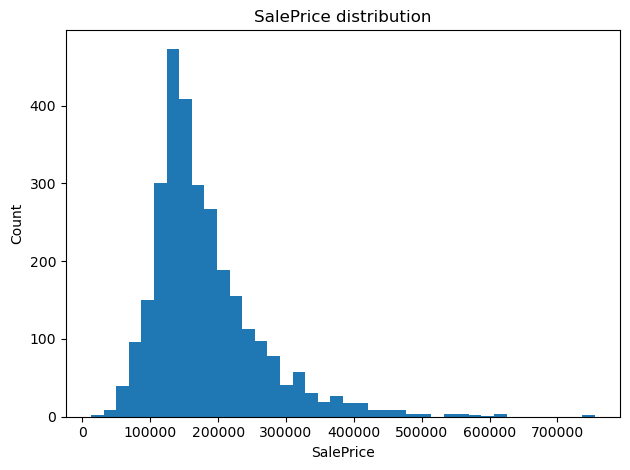

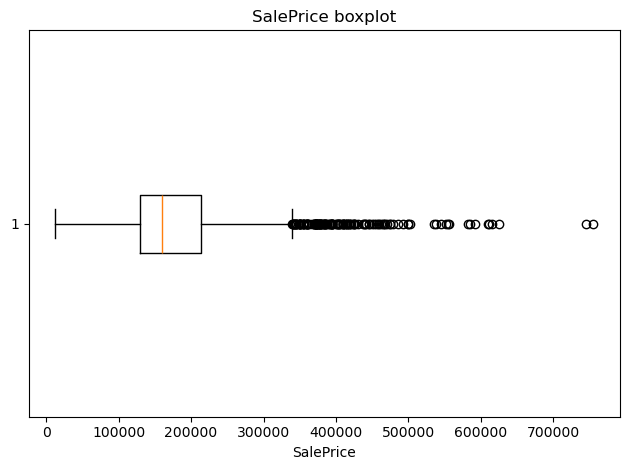

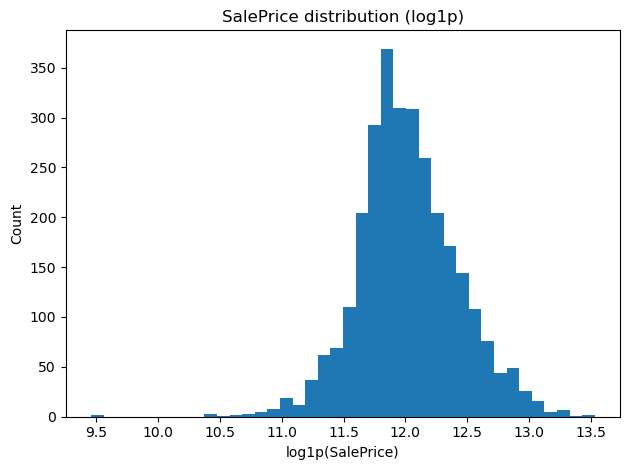

In [64]:
TARGET = "SalePrice"
plt.figure()
plt.hist(data[TARGET].dropna(), bins=40)
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.title("SalePrice distribution")
plt.tight_layout()
plt.show()

plt.figure()
plt.boxplot(data[TARGET].dropna(), vert=False)
plt.xlabel("SalePrice")
plt.title("SalePrice boxplot")
plt.tight_layout()
plt.show()

# log-scale view
plt.figure()
plt.hist(np.log1p(data[TARGET].dropna()), bins=40)
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Count")
plt.title("SalePrice distribution (log1p)")
plt.tight_layout()
plt.show()


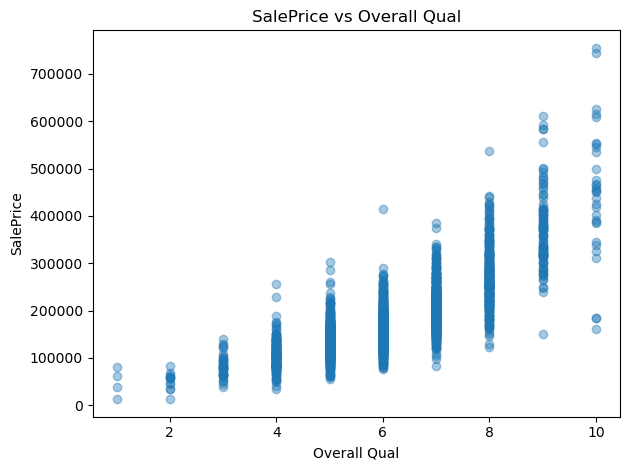

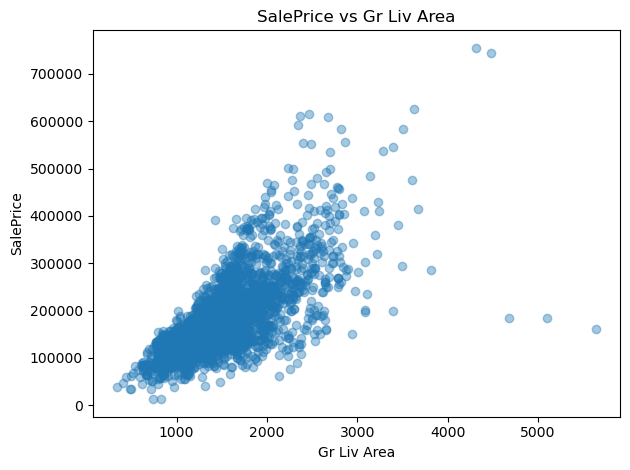

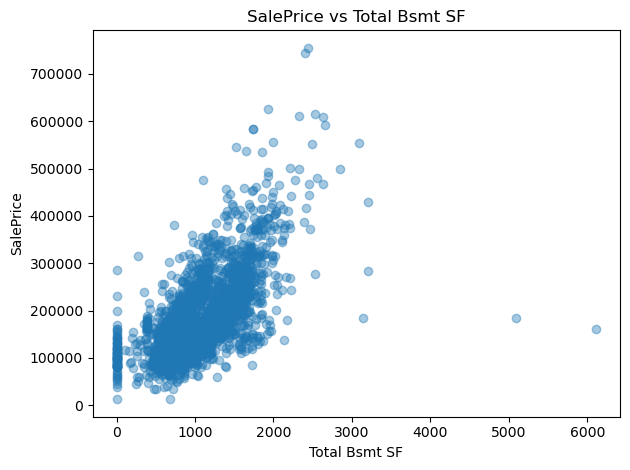

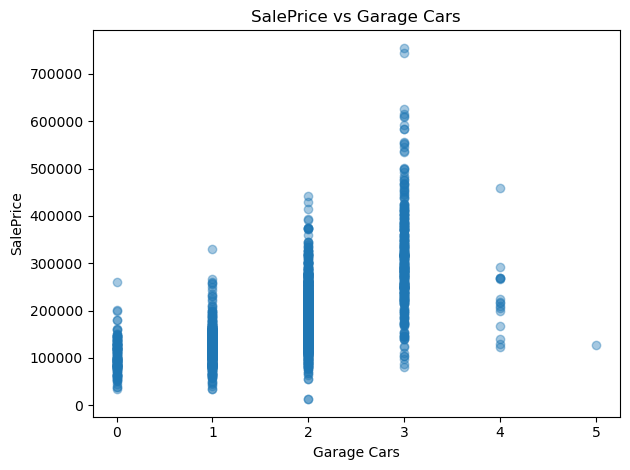

In [65]:
top_feats = ["Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Garage Cars"]

for f in top_feats:
    if f in data.columns:
        plt.figure()
        plt.scatter(data[f], data[TARGET], alpha=0.4)
        plt.xlabel(f)
        plt.ylabel(TARGET)
        plt.title(f"{TARGET} vs {f}")
        plt.tight_layout()
        plt.show()


C:\Users\EAG28\AppData\Local\Temp\ipykernel_14080\959778877.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


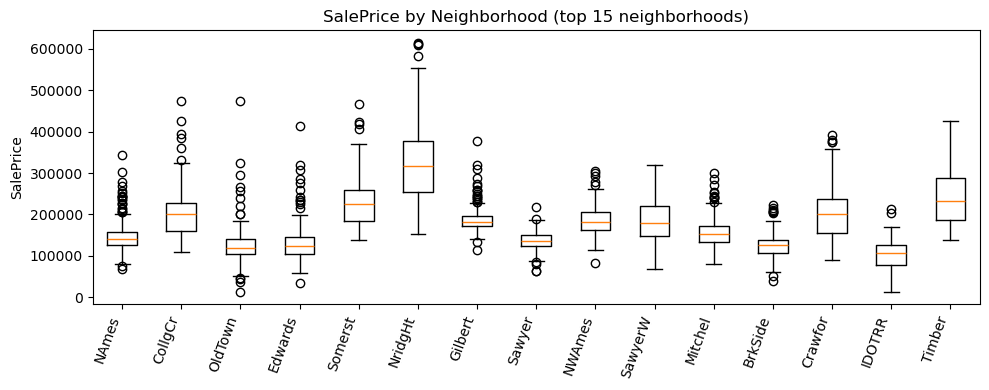

C:\Users\EAG28\AppData\Local\Temp\ipykernel_14080\959778877.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


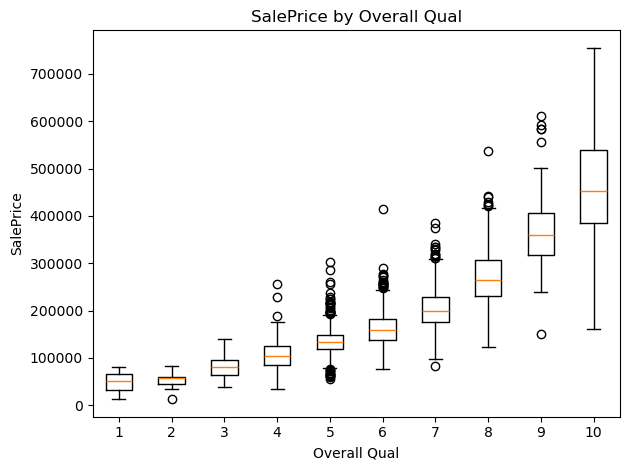

In [66]:
# Neighborhood
cat = "Neighborhood"
if cat in data.columns:
    topN = 15
    order = data[cat].value_counts().head(topN).index.tolist()
    df_plot = data[data[cat].isin(order)][[cat, TARGET]].dropna()

    plt.figure(figsize=(10,4))
    plt.boxplot(
        [df_plot[df_plot[cat]==k][TARGET].values for k in order],
        labels=order,
        vert=True
    )
    plt.xticks(rotation=70, ha="right")
    plt.ylabel(TARGET)
    plt.title(f"{TARGET} by {cat} (top {topN} neighborhoods)")
    plt.tight_layout()
    plt.show()

# Overall Qual boxplot (ordinal)
cat2 = "Overall Qual"
if cat2 in data.columns:
    order2 = sorted(data[cat2].dropna().unique())
    df_plot2 = data[[cat2, TARGET]].dropna()

    plt.figure()
    plt.boxplot(
        [df_plot2[df_plot2[cat2]==k][TARGET].values for k in order2],
        labels=order2,
        vert=True
    )
    plt.xlabel(cat2)
    plt.ylabel(TARGET)
    plt.title(f"{TARGET} by {cat2}")
    plt.tight_layout()
    plt.show()


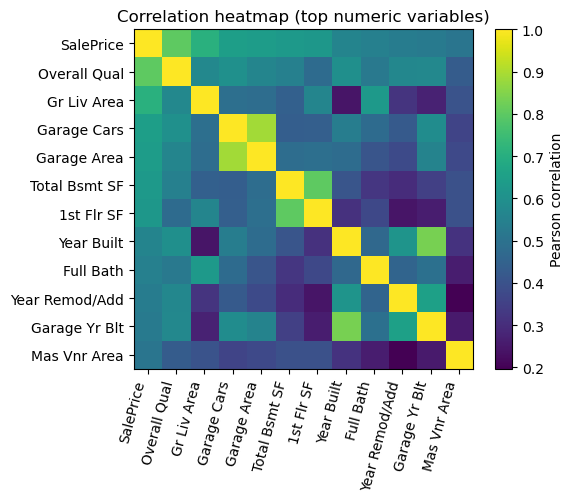

In [67]:
num = data.select_dtypes(include=["number"]).apply(pd.to_numeric, errors="coerce")
corr = num.corr()

# top correlated with target
top_vars = corr[TARGET].abs().sort_values(ascending=False).head(12).index.tolist()

plt.figure(figsize=(6,5))
plt.imshow(corr.loc[top_vars, top_vars])
plt.xticks(range(len(top_vars)), top_vars, rotation=75, ha="right")
plt.yticks(range(len(top_vars)), top_vars)
plt.colorbar(label="Pearson correlation")
plt.title("Correlation heatmap (top numeric variables)")
plt.tight_layout()
plt.show()


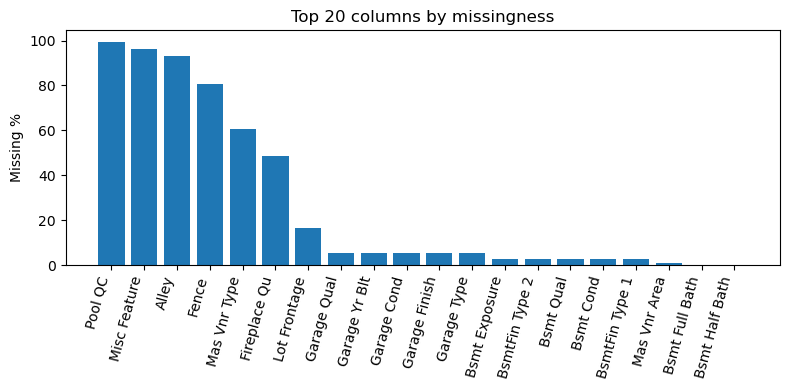

In [68]:
miss = (data.isna().mean() * 100).sort_values(ascending=False).head(20)

plt.figure(figsize=(8,4))
plt.bar(miss.index.astype(str), miss.values)
plt.xticks(rotation=75, ha="right")
plt.ylabel("Missing %")
plt.title("Top 20 columns by missingness")
plt.tight_layout()
plt.show()


In [69]:
du_2d_parts = [
  "DU(2d): Visual exploration summary from 11 plots.",
  "Target: SalePrice is right-skewed with high-end outliers; log1p reduces skew and stabilizes variance.",
  "Signal: Overall Qual, Gr Liv Area, Total Bsmt SF, Garage Cars show strong positive association with SalePrice.",
  "Categorical: Neighborhood stratifies prices clearly; location must be encoded.",
  "Redundancy: Garage Cars~Garage Area and Year Built~Garage Yr Blt indicate multicollinearity risk.",
  "Missingness: concentrated in amenity/quality fields (Pool QC/Alley/Fence etc.) → likely 'absence' not random."
]


In [70]:
def sparql_escape_literal_strict(s: str) -> str:
    s = (s or "")
    return (s
        .replace("\\", "\\\\")
        .replace('"', '\\"')
        .replace("\n", "\\n")
        .replace("\r", "\\r")
        .replace("\t", "\\t")
    )

target_subject = ":missingness_report"

for i, p in enumerate(du_2d_parts):
    triple = f'{target_subject} rdfs:comment "{sparql_escape_literal_strict(p)}" .'
    try:
        engine.insert([triple], prefixes=prefixes, chunk_size=1)
        print(f"OK inserted part {i}: {p[:60]}...")
    except Exception as e:
        print(f"FAILED at part {i}: {type(e).__name__} -> {e}")
        print("Problem triple was:\n", triple)
        break


OK inserted part 0: DU(2d): Visual exploration summary from 11 plots....
OK inserted part 1: Target: SalePrice is right-skewed with high-end outliers; lo...
OK inserted part 2: Signal: Overall Qual, Gr Liv Area, Total Bsmt SF, Garage Car...
OK inserted part 3: Categorical: Neighborhood stratifies prices clearly; locatio...
OK inserted part 4: Redundancy: Garage Cars~Garage Area and Year Built~Garage Yr...
OK inserted part 5: Missingness: concentrated in amenity/quality fields (Pool QC...


**KG Check**

In [71]:
q_du2d = f"""
{prefix_header}
SELECT ?c WHERE {{
  :missingness_report rdfs:comment ?c .
  FILTER(CONTAINS(STR(?c), "DU(2d)"))
}}
"""
q_ts(q_du2d)


,c
0,"""DU(2d) Visual exploration (plots)."""
1,"""DU(2d): Visual exploration summary from 11 plots."""
2,"""DU(2d): Visual exploration summary from 11 plots."""


## 2e. Ethically sensitivy attributes

In [72]:
def du_2e_bias_audit(data: pd.DataFrame, top_k_minor: int = 10, minor_thresh_pct: float = 2.0):
    df = data.copy()

    # Potentially sensitive or proxy columns in Ames
    sensitive_candidates = [
        "Neighborhood",          # location proxy (socioeconomic)
        "MS Zoning",             # zoning proxy
        "Condition 1", "Condition 2",  # proximity to roads/rail etc.
        "Bldg Type", "House Style",    # housing type proxy
        "Sale Type", "Sale Condition", # transaction characteristics
        "Central Air"            # can correlate with socioeconomic status
    ]
    present_sensitive = [c for c in sensitive_candidates if c in df.columns]

    # Categorical / discrete-like columns to audit for minority categories
    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
   # low cardinality
    low_card_ints = [c for c in df.select_dtypes(include=["int64","int32"]).columns if df[c].nunique() <= 15]
    audit_cols = sorted(set(cat_cols + low_card_ints))

    n = len(df)

    summaries = []
    for c in audit_cols:
        vc = df[c].value_counts(dropna=False)
        top = vc.head(top_k_minor)

        # minority categories
        pct = (vc / n) * 100
        minor_cats = pct[pct < minor_thresh_pct].sort_values().head(top_k_minor)

        summaries.append({
            "column": c,
            "dtype": str(df[c].dtype),
            "n_unique": int(df[c].nunique(dropna=True)),
            "missing_pct": float(df[c].isna().mean() * 100),
            "top_categories": [{"value": str(k), "count": int(v), "pct": float((v/n)*100)} for k, v in top.items()],
            "minority_categories_lt_thresh": [{"value": str(k), "pct": float(v)} for k, v in minor_cats.items()]
        })

    # Special focus: Neighborhood distribution (common bias proxy)
    neighborhood_summary = None
    if "Neighborhood" in df.columns:
        vc = df["Neighborhood"].value_counts(dropna=False)
        pct = (vc / n) * 100
        neighborhood_summary = {
            "n_unique": int(df["Neighborhood"].nunique(dropna=True)),
            "top_10": [{"value": str(k), "pct": float(v)} for k, v in pct.head(10).items()],
            "minority_lt_thresh": [{"value": str(k), "pct": float(v)} for k, v in pct[pct < minor_thresh_pct].sort_values().head(10).items()],
        }

    report = {
        "n_rows": int(n),
        "minority_threshold_pct": float(minor_thresh_pct),
        "sensitive_proxy_candidates_present": present_sensitive,
        "column_summaries": summaries,
        "neighborhood_focus": neighborhood_summary
    }
    return report

start_2e = now()
du2e = du_2e_bias_audit(data, top_k_minor=10, minor_thresh_pct=2.0)
end_2e = now()

print("Sensitive/proxy candidates present:", du2e["sensitive_proxy_candidates_present"])
if du2e["neighborhood_focus"]:
    print("Neighborhood unique:", du2e["neighborhood_focus"]["n_unique"])
    print("Neighborhood minority (<2%):", du2e["neighborhood_focus"]["minority_lt_thresh"][:5])


Sensitive/proxy candidates present: ['Neighborhood', 'MS Zoning', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Sale Type', 'Sale Condition', 'Central Air']
Neighborhood unique: 28
Neighborhood minority (<2%): [{'value': 'Landmrk', 'pct': 0.034129692832764506}, {'value': 'GrnHill', 'pct': 0.06825938566552901}, {'value': 'Greens', 'pct': 0.27303754266211605}, {'value': 'Blueste', 'pct': 0.3412969283276451}, {'value': 'NPkVill', 'pct': 0.7849829351535836}]


In [73]:
du_2e_comment = """
DU(2e) Ethical sensitivity, minority categories, and imbalance assessment.

The dataset does not contain explicit protected personal attributes (e.g., race, gender, health).
However, several variables can act as proxies for socioeconomic or structural factors, including
Neighborhood, MS Zoning, Condition 1/2, Bldg Type, House Style, Sale Type, Sale Condition, and Central Air.
In particular, Neighborhood is a strong proxy for location-based socioeconomic effects and local market
conditions.

The Neighborhood attribute contains 28 unique categories with highly imbalanced representation.
Several neighborhoods are strongly underrepresented, including Landmrk (~0.03%), GrnHill (~0.07%),
Greens (~0.27%), Blueste (~0.34%), and NPkVill (~0.78%). Such minority categories may lead to unstable
estimates and higher uncertainty in model predictions for these groups.

Across categorical variables, similar patterns of rare categories (<2%) are observed. These minority
classes risk being underweighted during training and insufficiently represented in evaluation metrics.
To mitigate this risk in later phases, we will consider grouping rare levels, applying robust categorical
encodings, and using evaluation strategies that account for class imbalance (e.g., macro-averaged metrics
or subgroup analysis).

Conclusion: Potential bias risk arises primarily from proxy variables related to location and housing
structure, as well as from strong category imbalance. These issues are documented here to guide
feature engineering and evaluation choices; no bias mitigation is applied yet in the Data Understanding phase.
"""


In [74]:
engine.insert(
    [f':missingness_report rdfs:comment "{sparql_escape_literal_strict(du_2e_comment)}" .'],
    prefixes=prefixes,
    chunk_size=1
)
print("KG: DU(2e) interpretation logged as comment on :missingness_report")


KG: DU(2e) interpretation logged as comment on :missingness_report


**KG Check**

In [75]:
q_2e_check = f"""
{prefix_header}
SELECT ?c WHERE {{
  :missingness_report rdfs:comment ?c .
  FILTER(CONTAINS(STR(?c), "DU(2e)"))
}}
"""
q_ts(q_2e_check)


,c
0,"""""""\nDU(2e) Ethical sensitivity, minority categories, and imbalance assessment.\n\nThe dataset does not contain explicit protected personal attributes (e.g., race, gender, health).\nHowever, several variables can act as proxies for socioeconomic or structural factors, including\nNeighborhood, MS Zoning, Condition 1/2, Bldg Type, House Style, Sale Type, Sale Condition, and Central Air.\nIn particular, Neighborhood is a strong proxy for location-based socioeconomic effects and local market\nconditions.\n\nThe Neighborhood attribute contains 28 unique categories with highly imbalanced representation.\nSeveral neighborhoods are strongly underrepresented, including Landmrk (~0.03%), GrnHill (~0.07%),\nGreens (~0.27%), Blueste (~0.34%), and NPkVill (~0.78%). Such minority categories may lead to unstable\nestimates and higher uncertainty in model predictions for these groups.\n\nAcross categorical variables, similar patterns of rare categories (<2%) are observed. These minority\nclasses risk being underweighted during training and insufficiently represented in evaluation metrics.\nTo mitigate this risk in later phases, we will consider grouping rare levels, applying robust categorical\nencodings, and using evaluation strategies that account for class imbalance (e.g., macro-averaged metrics\nor subgroup analysis).\n\nConclusion: Potential bias risk arises primarily from proxy variables related to location and housing\nstructure, as well as from strong category imbalance. These issues are documented here to guide\nfeature engineering and evaluation choices; no bias mitigation is applied yet in the Data Understanding phase.\n"""""""
1,"""""""\nDU(2e) Ethical sensitivity, minority categories, and imbalance assessment.\n\nThe dataset does not contain explicit protected personal attributes (e.g., race, gender, health).\nHowever, several variables can act as proxies for socioeconomic or structural factors, including\nNeighborhood, MS Zoning, Condition 1/2, Bldg Type, House Style, Sale Type, Sale Condition, and Central Air.\nIn particular, Neighborhood is a strong proxy for location-based socioeconomic effects and local market\nconditions.\n\nThe Neighborhood attribute contains 28 unique categories with highly imbalanced representation.\nSeveral neighborhoods are strongly underrepresented, including Landmrk (~0.03%), GrnHill (~0.07%),\nGreens (~0.27%), Blueste (~0.34%), and NPkVill (~0.78%). Such minority categories may lead to unstable\nestimates and higher uncertainty in model predictions for these groups.\n\nAcross categorical variables, similar patterns of rare categories (<2%) are observed. These minority\nclasses risk being underweighted during training and insufficiently represented in evaluation metrics.\nTo mitigate this risk in later phases, we will consider grouping rare levels, applying robust categorical\nencodings, and using evaluation strategies that account for class imbalance (e.g., macro-averaged metrics\nor subgroup analysis).\n\nConclusion: Potential bias risk arises primarily from proxy variables related to location and housing\nstructure, as well as from strong category imbalance. These issues are documented here to guide\nfeature engineering and evaluation choices; no bias mitigation is applied yet in the Data Understanding phase.\n"""""""


## 2f. Potential risks and additional biases

In [76]:
du_2f_comment = """
DU(2f) Potential risks and open questions.

Based on Data Understanding analyses, several risks are identified. Proxy bias may arise from variables
such as Neighborhood, MS Zoning, and housing type, which can encode socioeconomic differences. Strong
category imbalance, especially in Neighborhood, introduces representation risk for rare groups.
Missing values are non-random and mostly indicate absence of amenities; incorrect handling could bias
models. Extreme values in size-related variables and SalePrice appear valid but may disproportionately
influence certain models.

Open questions include whether prediction errors differ across neighborhoods or rare categories, how
to best handle highly correlated features, and how robust models will be to temporal or market shifts.
No mitigation is applied at this stage; these issues are addressed in later phases.
"""


In [77]:
engine.insert(
    [f':missingness_report rdfs:comment "{sparql_escape_literal_strict(du_2f_comment)}" .'],
    prefixes=prefixes,
    chunk_size=1
)
print("KG: DU(2f) logged")


KG: DU(2f) logged


## 2g. Data preperation plan

In [78]:
du_2g_comment = """
Based on the Data Understanding analysis, several actions are required in the Data Preparation phase.
Missing values in categorical variables with high missingness should be encoded as explicit absence
categories, while numeric variables with moderate missingness (e.g., Lot Frontage) require group-based
imputation. Redundant numeric predictors identified through correlation analysis should be handled via
feature selection or regularization to mitigate multicollinearity. Outliers should be retained but
their influence controlled through transformations and robust modeling choices. Finally, sensitive
or proxy attributes such as Neighborhood require bias-aware evaluation and careful encoding.
"""


In [79]:
comment_triples = [
    f':data_understanding_phase rdfs:comment """{sparql_escape_literal(du_2g_comment)}""" .'
]

engine.insert(comment_triples, prefixes=prefixes, chunk_size=1)
print("KG: DU(2g) data preparation actions added as comment to :data_understanding_phase")


KG: DU(2g) data preparation actions added as comment to :data_understanding_phase


# 3. Data Preparation

## 3a. Data preprocessing

In [80]:
## Each Activity that follows is part of the Data Preparation Phase

data_preparation_phase_executor = [
f':data_preparation_phase rdf:type prov:Activity .',
f':data_preparation_phase rdfs:label "Data Preparation Phase" .',
]
engine.insert(data_preparation_phase_executor, prefixes=prefixes)

### Test/Train Split

In [81]:
# -----------------------------
# CONFIG
# -----------------------------

seed = 42
test_size = 0.20
val_size  = 0.20  # optional; fraction of FULL data

# KG input is the Data Understanding dataset
input_dataset_iri = ":data"


def split_data_before_preparation(df: pd.DataFrame,
                                  seed: int = 42,
                                  test_size: float = 0.20,
                                  val_size: float | None = None):

    rng = np.random.default_rng(seed)
    idx = np.arange(len(df))
    rng.shuffle(idx)

    n = len(df)
    n_test = int(round(n * test_size))

    if val_size is None:
        n_train = n - n_test
        train_idx = idx[:n_train]
        test_idx  = idx[n_train:]
        train_df = df.iloc[train_idx].copy()
        test_df  = df.iloc[test_idx].copy()
        return train_df, test_df

    n_val = int(round(n * val_size))
    n_train = n - n_test - n_val

    train_idx = idx[:n_train]
    val_idx   = idx[n_train:n_train + n_val]
    test_idx  = idx[n_train + n_val:]

    train_df = df.iloc[train_idx].copy()
    val_df   = df.iloc[val_idx].copy()
    test_df  = df.iloc[test_idx].copy()
    return train_df, val_df, test_df

# -----------------------------
# RUN + TIMING
# -----------------------------
start_time_split = now()


train_df, val_df, test_df = split_data_before_preparation(
    data, seed=seed, test_size=test_size, val_size=val_size
)

# Preserve original row indices from :data (needed for outliers_report)
train_df["orig_row_id"] = train_df.index
val_df["orig_row_id"]   = val_df.index
test_df["orig_row_id"]  = test_df.index


train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

end_time_split = now()

print(len(train_df), len(val_df), len(test_df))


1758 586 586


In [82]:
split_code_writer = student_b   # who wrote the split code (agent IRI string)
# Generate ONCE and keep fixed forever:
dp_split_ass_uuid_executor = "3c4a9c61-8f0b-4d9a-9f9b-1a47f1c0e3d2"
dp_split_ass_uuid_writer   = "a7d9b12e-4c1f-4c6a-8f6e-91f2c84b3f55"

In [83]:
input_dataset_iri = ":data"

split_comment = f"""
We split the dataset into training/validation/test sets BEFORE any data preparation to prevent data leakage.
All cleaning/feature engineering steps will be fitted on the training set only and then applied to validation/test.
Random IID split with seed={seed}, test_size={test_size}, val_size={val_size} (fractions of full dataset).
"""

# Activity + associations (executor + writer)
split_executor_triples = [
    f':split_data prov:qualifiedAssociation :{dp_split_ass_uuid_executor} .',
    f':{dp_split_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{dp_split_ass_uuid_executor} rdf:type prov:Association .',
    f':{dp_split_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(split_executor_triples, prefixes=prefixes)

split_activity_triples = [
    # Activity node
    ':split_data rdf:type prov:Activity .',
    ':split_data sc:isPartOf :data_preparation_phase .',
    ':split_data rdfs:comment "Data Preparation" .',
    f':split_data rdfs:comment """{split_comment}""" .',
    f':split_data prov:startedAtTime "{start_time_split}"^^xsd:dateTime .',
    f':split_data prov:endedAtTime "{end_time_split}"^^xsd:dateTime .',

    # Writer association (who authored the code)
    f':split_data prov:qualifiedAssociation :{dp_split_ass_uuid_writer} .',
    f':{dp_split_ass_uuid_writer} prov:agent :{split_code_writer} .',
    f':{dp_split_ass_uuid_writer} rdf:type prov:Association .',
    f':{dp_split_ass_uuid_writer} prov:hadRole :{code_writer_role} .',

    # Input used (DU output)
    f':split_data prov:used {input_dataset_iri} .',

    # Outputs (entities + datasets)
    ':training_set rdf:type prov:Entity .',
    ':training_set rdf:type sc:Dataset .',
    ':training_set rdfs:label "Training Set" .',
    ':training_set prov:wasGeneratedBy :split_data .',
    f':training_set prov:wasDerivedFrom {input_dataset_iri} .',
    f':training_set rdfs:comment "Rows: {len(train_df)}" .',

    ':validation_set rdf:type prov:Entity .',
    ':validation_set rdf:type sc:Dataset .',
    ':validation_set rdfs:label "Validation Set" .',
    ':validation_set prov:wasGeneratedBy :split_data .',
    f':validation_set prov:wasDerivedFrom {input_dataset_iri} .',
    f':validation_set rdfs:comment "Rows: {len(val_df)}" .',

    ':test_set rdf:type prov:Entity .',
    ':test_set rdf:type sc:Dataset .',
    ':test_set rdfs:label "Test Set" .',
    ':test_set prov:wasGeneratedBy :split_data .',
    f':test_set prov:wasDerivedFrom {input_dataset_iri} .',
    f':test_set rdfs:comment "Rows: {len(test_df)}" .',
]

engine.insert(split_activity_triples, prefixes=prefixes)

### KG Check

In [84]:
GROUP_BASE = f"https://starvers.ec.tuwien.ac.at/BI2025/{group_id}/"

q_split_activity = f"""
{prefix_header}
SELECT ?a ?comment WHERE {{
  ?a a prov:Activity ;
     sc:isPartOf :data_preparation_phase .
  FILTER(STRSTARTS(STR(?a), "{GROUP_BASE}split"))
  OPTIONAL {{ ?a rdfs:comment ?comment . }}
}}
"""
q_ts(q_split_activity)


,a,comment
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,"""Data Preparation"""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,"""Data Preparation"""
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,"""Data Preparation"""
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,"""Data Preparation"""
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,"""Data Preparation"""
...,...,...
245,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,"""""""\nWe split the dataset into training/validation/test sets BEFORE any data preparation to prevent data leakage.\nAll cleaning/feature engineering steps will be fitted on the training set only and then applied to validation/test.\nRandom IID split with seed=42, test_size=0.2, val_size=0.2 (fractions of full dataset).\n"""""""
246,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,"""""""\nWe split the dataset into training/validation/test sets BEFORE any data preparation to prevent data leakage.\nAll cleaning/feature engineering steps will be fitted on the training set only and then applied to validation/test.\nRandom IID split with seed=42, test_size=0.2, val_size=0.2 (fractions of full dataset).\n"""""""
247,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,"""""""\nWe split the dataset into training/validation/test sets BEFORE any data preparation to prevent data leakage.\nAll cleaning/feature engineering steps will be fitted on the training set only and then applied to validation/test.\nRandom IID split with seed=42, test_size=0.2, val_size=0.2 (fractions of full dataset).\n"""""""
248,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,"""""""\nWe split the dataset into training/validation/test sets BEFORE any data preparation to prevent data leakage.\nAll cleaning/feature engineering steps will be fitted on the training set only and then applied to validation/test.\nRandom IID split with seed=42, test_size=0.2, val_size=0.2 (fractions of full dataset).\n"""""""


In [85]:
q_split_used = f"""
{prefix_header}
SELECT ?a ?used WHERE {{
  ?a a prov:Activity ;
     sc:isPartOf :data_preparation_phase ;
     prov:used ?used .
  FILTER(STRSTARTS(STR(?a), "{GROUP_BASE}split"))
}}
"""
q_ts(q_split_used)


,a,used
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
...,...,...
120,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
121,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
122,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
123,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data>


In [86]:
q_split_outputs = f"""
{prefix_header}
SELECT ?out ?label ?derived WHERE {{
  ?out prov:wasGeneratedBy ?a .
  ?a sc:isPartOf :data_preparation_phase .
  FILTER(STRSTARTS(STR(?a), "{GROUP_BASE}split"))
  OPTIONAL {{ ?out rdfs:label ?label . }}
  OPTIONAL {{ ?out prov:wasDerivedFrom ?derived . }}
}}
ORDER BY ?out
"""
q_ts(q_split_outputs)


,out,label,derived
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set>,"""Test Set""",<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set>,"""Test Set""",<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set>,"""Test Set""",<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set>,"""Test Set""",<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set>,"""Test Set""",<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
...,...,...,...
3820,<https://starvers.ec.tuwien.ac.at/BI2025/13/validation_set>,"""Validation set (no outlier removal applied)""",<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
3821,<https://starvers.ec.tuwien.ac.at/BI2025/13/validation_set>,"""Validation set (no outlier removal applied)""",<https://starvers.ec.tuwien.ac.at/BI2025/13/data>
3822,<https://starvers.ec.tuwien.ac.at/BI2025/13/validation_set>,"""Validation set (no outlier removal applied)""",<https://starvers.ec.tuwien.ac.at/BI2025/13/validation_set>
3823,<https://starvers.ec.tuwien.ac.at/BI2025/13/validation_set>,"""Validation set (no outlier removal applied)""",<https://starvers.ec.tuwien.ac.at/BI2025/13/validation_set>


In [87]:
q_split_sizes = f"""
{prefix_header}
SELECT ?ds ?comment WHERE {{
  VALUES ?ds {{ :training_set :validation_set :test_set }}
  OPTIONAL {{ ?ds rdfs:comment ?comment . }}
}}
"""
q_ts(q_split_sizes)


,ds,comment
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>,"""Rows: 1758"""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>,"""Rows: 1758"""
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>,"""Rows: 1758"""
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>,"""Rows: 1758"""
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>,"""Rows: 1758"""
5,<https://starvers.ec.tuwien.ac.at/BI2025/13/validation_set>,"""Rows: 586"""
6,<https://starvers.ec.tuwien.ac.at/BI2025/13/validation_set>,"""Rows: 586"""
7,<https://starvers.ec.tuwien.ac.at/BI2025/13/validation_set>,"""Rows: 586"""
8,<https://starvers.ec.tuwien.ac.at/BI2025/13/validation_set>,"""Rows: 586"""
9,<https://starvers.ec.tuwien.ac.at/BI2025/13/validation_set>,"""Rows: 586"""


### Handling Outliers

In [88]:
TARGET = "SalePrice"

outliers_report_train = build_outliers_report_iqr(
    train_df,
    cols=[c for c in train_df.select_dtypes("number").columns if c not in [TARGET, "orig_row_id"]],
    k=1.5
)



In [89]:
# -----------------------------
# OUTLIER REMOVAL (TRAIN ONLY)
# -----------------------------
handle_outliers_code_writer = student_b
MIN_OUTLIER_COLS = 2

def handle_outliers_train(df: pd.DataFrame,
                          outliers_report: dict,
                          min_outlier_cols: int = 2,
                          id_col: str = "orig_row_id") -> pd.DataFrame:
    """
    Remove outliers ONLY from training set.
    Uses orig_row_id to match rows from Data Understanding outlier report.
    """
    df2 = df.copy()

    rows = outliers_report.get("top_rows_by_outlier_count", [])
    bad_ids = {
        int(r["row_index"]) for r in rows
        if int(r.get("outlier_count", 0)) >= int(min_outlier_cols)
    }

    if bad_ids:
        df2 = df2[~df2[id_col].isin(bad_ids)].copy()

    return df2


# -----------------------------
# RUN + TIMING
# -----------------------------
start_time_td = now()

train_df_clean = handle_outliers_train(train_df, outliers_report_train, min_outlier_cols=MIN_OUTLIER_COLS)
end_time_td = now()

print("TRAIN rows before:", len(train_df))
print("TRAIN rows after :", len(train_df_clean))
print("TRAIN removed    :", len(train_df) - len(train_df_clean))


TRAIN rows before: 1758
TRAIN rows after : 1739
TRAIN removed    : 19


In [90]:
def safe_insert(triples, prefixes=prefixes, chunk_size=20, pause=0.2):
    for i in range(0, len(triples), chunk_size):
        chunk = triples[i:i+chunk_size]
        try:
            engine.insert(chunk, prefixes=prefixes)
        except Exception as e:
            print("KG insert failed at chunk", i//chunk_size, type(e).__name__, e)
            # don't crash notebook
        time.sleep(pause)


In [91]:
#############################################
# KG DOCUMENTATION — OUTLIER REMOVAL (TRAIN)
#############################################

# fixed UUIDs (already generated once)
# FIXED FOREVER — do not regenerate
ro_ass_uuid_executor = "9b3c1a64-7f2e-4c1b-9e6e-3c0f8d91a211"
td_ass_uuid_writer   = "f4e2a88d-0d6a-4e9e-92c1-8f5a7b4c9c31"

td_comment = f"""
Outlier removal is applied ONLY to the training set after data splitting
to prevent data leakage. Rows were identified during the Data Understanding
phase and removed according to the documented :outlier_decision.
Rule: rows flagged as outliers in >= {MIN_OUTLIER_COLS} numeric columns.
"""

# executor association
handle_outliers_executor = [
    f':handle_outliers_train prov:qualifiedAssociation :{ro_ass_uuid_executor} .',
    f':{ro_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{ro_ass_uuid_executor} rdf:type prov:Association .',
    f':{ro_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(handle_outliers_executor, prefixes=prefixes)

# activity + entities
handle_outliers_activity = [
    ':handle_outliers_train rdf:type prov:Activity .',
    ':handle_outliers_train sc:isPartOf :data_preparation_phase .',
    ':handle_outliers_train rdfs:comment "Data Preparation" .',
    f':handle_outliers_train rdfs:comment """{td_comment}""" .',
    f':handle_outliers_train prov:startedAtTime "{start_time_td}"^^xsd:dateTime .',
    f':handle_outliers_train prov:endedAtTime "{end_time_td}"^^xsd:dateTime .',

    # code writer
    f':handle_outliers_train prov:qualifiedAssociation :{td_ass_uuid_writer} .',
    f':{td_ass_uuid_writer} prov:agent :{handle_outliers_code_writer} .',
    f':{td_ass_uuid_writer} rdf:type prov:Association .',
    f':{td_ass_uuid_writer} prov:hadRole :{code_writer_role} .',

    # inputs
    ':handle_outliers_train prov:used :training_set .',
    ':handle_outliers_train prov:used :outlier_report .',
    ':handle_outliers_train prov:used :outlier_decision .',

    # output
    ':training_set_cleaned rdf:type prov:Entity .',
    ':training_set_cleaned prov:wasGeneratedBy :handle_outliers_train .',
    ':training_set_cleaned prov:wasDerivedFrom :training_set .',
]

engine.insert(handle_outliers_activity, prefixes=prefixes)


In [92]:
patch_outlier_alias = [
    # Alias entity that your DP step claims it used
    ':outlier_report rdf:type prov:Entity .',
    ':outlier_report rdfs:label "Outlier report (alias for DU outlier report entity)" .',
    ':outlier_report prov:wasDerivedFrom :outliers_report_entity .',

    # Create a minimal decision entity so the 'prov:used :outlier_decision' is valid
    ':outlier_decision rdf:type prov:Entity .',
    ':outlier_decision rdfs:label "Outlier removal decision (train-only rule)" .',
    ':outlier_decision rdfs:comment "Decision: remove rows flagged as outliers in >= MIN_OUTLIER_COLS numeric columns (train only)." .',
    ':outlier_decision prov:wasDerivedFrom :outliers_report_entity .',
]

safe_insert(patch_outlier_alias)
print("PATCH: outlier_report + outlier_decision created/linked")


PATCH: outlier_report + outlier_decision created/linked


### KG Check

In [93]:
GROUP_BASE = f"https://starvers.ec.tuwien.ac.at/BI2025/{group_id}/"


In [94]:
q_ho_train_activity = f"""{prefix_header}
SELECT ?act ?start ?end ?comment WHERE {{
  VALUES ?act {{ :handle_outliers_train }}
  ?act a prov:Activity ;
       sc:isPartOf :data_preparation_phase .
  OPTIONAL {{ ?act prov:startedAtTime ?start . }}
  OPTIONAL {{ ?act prov:endedAtTime ?end . }}
  OPTIONAL {{ ?act rdfs:comment ?comment . }}
}}
"""
q_ts(q_ho_train_activity)


,act,start,end,comment
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/handle_outliers_train>,"""2026-01-14T16:19:35.791Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-14T16:19:35.802Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""Data Preparation"""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/handle_outliers_train>,"""2026-01-14T16:19:35.791Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-14T16:19:35.802Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""Data Preparation"""
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/handle_outliers_train>,"""2026-01-14T16:19:35.791Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-14T16:19:35.802Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""Data Preparation"""
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/handle_outliers_train>,"""2026-01-14T16:19:35.791Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-14T16:19:35.802Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""Data Preparation"""
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/handle_outliers_train>,"""2026-01-14T16:19:35.791Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-14T16:19:35.802Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""""""\nOutlier removal is applied ONLY to the training set after data splitting\nto prevent data leakage. Rows were identified during the Data Understanding\nphase and removed according to the documented :outlier_decision.\nRule: rows flagged as outliers in >= 2 numeric columns.\n"""""""
...,...,...,...,...
2043,<https://starvers.ec.tuwien.ac.at/BI2025/13/handle_outliers_train>,"""2026-01-17T12:10:37.394Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:10:37.405Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""Data Preparation"""
2044,<https://starvers.ec.tuwien.ac.at/BI2025/13/handle_outliers_train>,"""2026-01-17T12:10:37.394Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:10:37.405Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""""""\nOutlier removal is applied ONLY to the training set after data splitting\nto prevent data leakage. Rows were identified during the Data Understanding\nphase and removed according to the documented :outlier_decision.\nRule: rows flagged as outliers in >= 2 numeric columns.\n"""""""
2045,<https://starvers.ec.tuwien.ac.at/BI2025/13/handle_outliers_train>,"""2026-01-17T12:10:37.394Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:10:37.405Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""""""\nOutlier removal is applied ONLY to the training set after data splitting\nto prevent data leakage. Rows were identified during the Data Understanding\nphase and removed according to the documented :outlier_decision.\nRule: rows flagged as outliers in >= 2 numeric columns.\n"""""""
2046,<https://starvers.ec.tuwien.ac.at/BI2025/13/handle_outliers_train>,"""2026-01-17T12:10:37.394Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:10:37.405Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""""""\nOutlier removal is applied ONLY to the training set after data splitting\nto prevent data leakage. Rows were identified during the Data Understanding\nphase and removed according to the documented :outlier_decision.\nRule: rows flagged as outliers in >= 2 numeric columns.\n"""""""


In [95]:
q_ho_train_output = f"""{prefix_header}
SELECT ?out ?derivedFrom WHERE {{
  ?out prov:wasGeneratedBy :handle_outliers_train .
  OPTIONAL {{ ?out prov:wasDerivedFrom ?derivedFrom . }}
}}
"""
q_ts(q_ho_train_output)


,out,derivedFrom
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>
5,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>
6,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>
7,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>
8,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>
9,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set>


In [96]:
q_ho_train_assoc = f"""{prefix_header}
SELECT ?assoc ?agent ?role WHERE {{
  :handle_outliers_train prov:qualifiedAssociation ?assoc .
  OPTIONAL {{ ?assoc prov:agent ?agent . }}
  OPTIONAL {{ ?assoc prov:hadRole ?role . }}
}}
ORDER BY ?role ?agent
"""
q_ts(q_ho_train_assoc)


,assoc,agent,role
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/9b3c1a64-7f2e-4c1b-9e6e-3c0f8d91a211>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/9b3c1a64-7f2e-4c1b-9e6e-3c0f8d91a211>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/9b3c1a64-7f2e-4c1b-9e6e-3c0f8d91a211>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/9b3c1a64-7f2e-4c1b-9e6e-3c0f8d91a211>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/9b3c1a64-7f2e-4c1b-9e6e-3c0f8d91a211>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
...,...,...,...
123,<https://starvers.ec.tuwien.ac.at/BI2025/13/f4e2a88d-0d6a-4e9e-92c1-8f5a7b4c9c31>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_01529258>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
124,<https://starvers.ec.tuwien.ac.at/BI2025/13/f4e2a88d-0d6a-4e9e-92c1-8f5a7b4c9c31>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_01529258>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
125,<https://starvers.ec.tuwien.ac.at/BI2025/13/f4e2a88d-0d6a-4e9e-92c1-8f5a7b4c9c31>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_01529258>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
126,<https://starvers.ec.tuwien.ac.at/BI2025/13/f4e2a88d-0d6a-4e9e-92c1-8f5a7b4c9c31>,<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_01529258>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>


### Missing Values handling

In [97]:
start_time_mr = now()
missing_report_train = build_missingness_report(train_df_clean)
end_time_mr = now()

display(missing_report_train.head(20))



,column,n_missing,missing_pct,dtype,n_unique
0,Pool QC,1728,99.367453,object,4
1,Misc Feature,1670,96.032202,object,5
2,Alley,1634,93.962047,object,2
3,Fence,1379,79.298447,object,4
4,Mas Vnr Type,1029,59.171938,object,4
5,Fireplace Qu,851,48.936170,object,5
6,Lot Frontage,278,15.986199,float64,116
7,Garage Qual,97,5.577918,object,4
8,Garage Finish,97,5.577918,object,3
9,Garage Yr Blt,97,5.577918,float64,96


In [98]:
missing_threshold_drop_col = 40.0
cols_to_drop = missing_report_train.loc[
    missing_report_train["missing_pct"] > missing_threshold_drop_col,
    "column"
].tolist()

TARGET = "SalePrice"
ID_COL = "orig_row_id"

def fit_imputer_stats(train_df: pd.DataFrame, drop_cols: list[str], target_col: str, id_col: str):
    t = train_df.drop(columns=drop_cols, errors="ignore").copy()
    t = t.drop(columns=[target_col, id_col], errors="ignore")

    num_cols = t.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in t.columns if c not in num_cols]

    medians = {c: float(t[c].median()) for c in num_cols}
    modes = {c: (t[c].mode(dropna=True).iloc[0] if not t[c].mode(dropna=True).empty else None) for c in cat_cols}

    return drop_cols, medians, modes


def apply_imputer(df: pd.DataFrame, drop_cols, medians, modes):
    out = df.drop(columns=drop_cols, errors="ignore").copy()

    for c, v in medians.items():
        if c in out.columns:
            out[c] = out[c].fillna(v)

    for c, v in modes.items():
        if c in out.columns and v is not None:
            out[c] = out[c].fillna(v)

    return out

start_time_mv_apply = now()

drop_cols, medians, modes = fit_imputer_stats(train_df_clean, cols_to_drop, TARGET, ID_COL)


train_prepared = apply_imputer(train_df_clean, drop_cols, medians, modes)
val_prepared   = apply_imputer(val_df,         drop_cols, medians, modes)
test_prepared  = apply_imputer(test_df,        drop_cols, medians, modes)

# keep indices clean / consistent
train_prepared = train_prepared.reset_index(drop=True)
val_prepared   = val_prepared.reset_index(drop=True)
test_prepared  = test_prepared.reset_index(drop=True)

end_time_mv_apply = now()

print("Train missing after:", int(train_prepared.isna().sum().sum()))
print("Val missing after  :", int(val_prepared.isna().sum().sum()))
print("Test missing after :", int(test_prepared.isna().sum().sum()))

Train missing after: 0
Val missing after  : 0
Test missing after : 0


In [99]:
start_imr = now()
end_imr   = now()

patch_imr = [
    ':inspect_missingness_report rdf:type prov:Activity .',
    ':inspect_missingness_report sc:isPartOf :data_preparation_phase .',
    ':inspect_missingness_report rdfs:label "Inspect missingness report (train only)" .',
    f':inspect_missingness_report prov:startedAtTime "{start_imr}"^^xsd:dateTime .',
    f':inspect_missingness_report prov:endedAtTime "{end_imr}"^^xsd:dateTime .',

    # It should use the DP missingness report entity (the one you created)
    ':inspect_missingness_report prov:used :dp_missingness_report_train_entity .',
]

safe_insert(patch_imr)
print("PATCH: inspect_missingness_report activity created")


PATCH: inspect_missingness_report activity created


In [100]:
dp_mr_ass_uuid_executor = "1f0b6f2e-2c6e-4e2d-9c6b-3c9f4a2db8a1"
dp_mr_ass_uuid_writer   = "b4a2d7b1-9d3b-4b1b-8f10-7a1c3d0c9d55"

dp_missingness_activity = ":dp_missingness_report_train"
dp_missingness_entity   = ":dp_missingness_report_train_entity"

# IMPORTANT: code writer for this step
dp_missingness_code_writer = student_b  # <-- not student_a

mr_executor_triples = [
    f'{dp_missingness_activity} prov:qualifiedAssociation :{dp_mr_ass_uuid_executor} .',
    f':{dp_mr_ass_uuid_executor} rdf:type prov:Association .',
    f':{dp_mr_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{dp_mr_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]

missing_report_json = sparql_escape_literal(json.dumps(
    missing_report_train.to_dict(orient="records"), ensure_ascii=False
))

mr_activity_triples = [
    f'{dp_missingness_activity} rdf:type prov:Activity .',
    f'{dp_missingness_activity} sc:isPartOf :data_preparation_phase .',
    f'{dp_missingness_activity} rdfs:comment "Data Preparation" .',
    f'{dp_missingness_activity} prov:startedAtTime "{start_time_mr}"^^xsd:dateTime .',
    f'{dp_missingness_activity} prov:endedAtTime "{end_time_mr}"^^xsd:dateTime .',

    # writer assoc
    f'{dp_missingness_activity} prov:qualifiedAssociation :{dp_mr_ass_uuid_writer} .',
    f':{dp_mr_ass_uuid_writer} rdf:type prov:Association .',
    f':{dp_mr_ass_uuid_writer} prov:agent :{dp_missingness_code_writer} .',
    f':{dp_mr_ass_uuid_writer} prov:hadRole :{code_writer_role} .',

    # input used
    f'{dp_missingness_activity} prov:used :training_set_cleaned .',

    # output entity
    f'{dp_missingness_entity} rdf:type prov:Entity .',
    f'{dp_missingness_entity} rdfs:label "Missingness Report (Train, after outlier removal)" .',
    f'{dp_missingness_entity} rdfs:comment "{missing_report_json}" .',
    f'{dp_missingness_entity} prov:wasGeneratedBy {dp_missingness_activity} .',
    f'{dp_missingness_entity} prov:wasDerivedFrom :training_set_cleaned .',
]

engine.insert(mr_executor_triples, prefixes=prefixes)
engine.insert(mr_activity_triples, prefixes=prefixes)
print("Inserted DP train-only missingness report")


Inserted DP train-only missingness report


In [101]:
imr_ass_uuid_executor = "b7a8f7e6-5c8a-4b17-9e1c-0ad9a4d1f111"

step2_assoc_only = [
    f':inspect_missingness_report prov:qualifiedAssociation :{imr_ass_uuid_executor} .',
    f':{imr_ass_uuid_executor} rdf:type prov:Association .',
    f':{imr_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{imr_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(step2_assoc_only, prefixes=prefixes)
print("STEP 2 association inserted")


STEP 2 association inserted


In [102]:
def sparql_escape_literal(s: str) -> str:
    return (
        s.replace("\\", "\\\\")
         .replace('"', '\\"')
         .replace("\n", "\\n")
         .replace("\r", "\\r")
    )

# IMPORTANT: avoid words like "drop", "delete", "insert" in literals
imr_comment = (
    "Decision after inspecting missingness report (train only): "
    f"Exclude columns with missing_pct > {missing_threshold_drop_col}%. "
    "Impute numeric with median and categorical with mode. "
    "Fit statistics on TRAIN only; apply to VAL/TEST to avoid leakage."
)
imr_comment_esc = sparql_escape_literal(imr_comment)

step2_finish_safe = [
    ':missing_value_decision rdf:type prov:Entity .',
    ':missing_value_decision rdfs:label "Missing Value Handling Decision" .',
    f':missing_value_decision rdfs:comment "{imr_comment_esc}" .',
    ':missing_value_decision prov:wasGeneratedBy :inspect_missingness_report .',
]
engine.insert(step2_finish_safe, prefixes=prefixes)
print("STEP 2 finished (safe wording): decision entity inserted")


STEP 2 finished (safe wording): decision entity inserted


In [103]:
step3_activity_min = [
    ':apply_missing_value_handling rdf:type prov:Activity .',
    ':apply_missing_value_handling sc:isPartOf :data_preparation_phase .',
    ':apply_missing_value_handling rdfs:label "Apply missing value handling" .',
    ':apply_missing_value_handling prov:used :training_set_cleaned .',
]

engine.insert(step3_activity_min, prefixes=prefixes)
print("STEP 3A inserted (minimal activity)")


STEP 3A inserted (minimal activity)


In [104]:
step3_fix_types = [
    # types
    ':training_set_prepared rdf:type sc:Dataset .',
    ':training_set_prepared rdf:type prov:Entity .',

    ':validation_set_prepared rdf:type sc:Dataset .',
    ':validation_set_prepared rdf:type prov:Entity .',

    ':test_set_prepared rdf:type sc:Dataset .',
    ':test_set_prepared rdf:type prov:Entity .',

    # lineage
    ':training_set_prepared prov:wasDerivedFrom :training_set_cleaned .',
]

engine.insert(step3_fix_types, prefixes=prefixes)
print("Step 3: added rdf:type + provenance lineage")


Step 3: added rdf:type + provenance lineage


In [105]:
start_mv = now()
end_mv   = now()

patch_mv_links = [
    # Ensure activity exists + metadata
    ':apply_missing_value_handling rdf:type prov:Activity .',
    ':apply_missing_value_handling sc:isPartOf :data_preparation_phase .',
    ':apply_missing_value_handling rdfs:label "Apply missing value handling (fit train, apply val/test)" .',
    f':apply_missing_value_handling prov:startedAtTime "{start_mv}"^^xsd:dateTime .',
    f':apply_missing_value_handling prov:endedAtTime "{end_mv}"^^xsd:dateTime .',

    # Inputs used
    ':apply_missing_value_handling prov:used :training_set_cleaned .',
    ':apply_missing_value_handling prov:used :validation_set .',
    ':apply_missing_value_handling prov:used :test_set .',
    ':apply_missing_value_handling prov:used :missing_value_decision .',

    # Outputs generated (THIS is the missing link)
    ':training_set_prepared prov:wasGeneratedBy :apply_missing_value_handling .',
    ':validation_set_prepared prov:wasGeneratedBy :apply_missing_value_handling .',
    ':test_set_prepared prov:wasGeneratedBy :apply_missing_value_handling .',
]

safe_insert(patch_mv_links)
print("PATCH: apply_missing_value_handling connected to prepared datasets")


PATCH: apply_missing_value_handling connected to prepared datasets


### KG Check

In [106]:
q_ts(f"""
{prefix_header}
SELECT ?a ?label WHERE {{
  ?a a prov:Activity ;
     sc:isPartOf :data_preparation_phase .
  OPTIONAL {{ ?a rdfs:label ?label }}
}}
ORDER BY ?a
""")



,a,label
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,"""Apply missing value handling"""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,"""Apply missing value handling"""
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,"""Apply missing value handling"""
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,"""Apply missing value handling (fit train, apply val/test)"""
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,"""Apply missing value handling (fit train, apply val/test)"""
...,...,...
352,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,None
353,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,None
354,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,None
355,<https://starvers.ec.tuwien.ac.at/BI2025/13/split_data>,None


In [107]:
q_ts(f"""
{prefix_header}
SELECT ?d ?gen ?src WHERE {{
  VALUES ?d {{ :training_set_prepared :validation_set_prepared :test_set_prepared }}
  OPTIONAL {{ ?d prov:wasGeneratedBy ?gen . }}
  OPTIONAL {{ ?d prov:wasDerivedFrom ?src . }}
}}
ORDER BY ?d
""")


,d,gen,src
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,None
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,None
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,None
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>
5,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>
6,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>
7,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>
8,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>
9,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>


In [108]:
q_ts(f"""
{prefix_header}
SELECT ?d ?gen ?src WHERE {{
  VALUES ?d {{ :training_set_prepared :validation_set_prepared :test_set_prepared }}
  OPTIONAL {{ ?d prov:wasGeneratedBy ?gen . }}
  OPTIONAL {{ ?d prov:wasDerivedFrom ?src . }}
}}
ORDER BY ?d
""")


,d,gen,src
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,None
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,None
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,None
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>
5,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>
6,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>
7,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>
8,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>
9,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>,<https://starvers.ec.tuwien.ac.at/BI2025/13/apply_missing_value_handling>,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_cleaned>


### Feature Engineering

In [109]:
# ----------------------------
# INPUTS
# ----------------------------
y_train = train_prepared[TARGET].copy()
y_val   = val_prepared[TARGET].copy()
y_test  = test_prepared[TARGET].copy()

X_train_prepared = train_prepared.drop(columns=[TARGET, ID_COL], errors="ignore")
X_val_prepared   = val_prepared.drop(columns=[TARGET, ID_COL], errors="ignore")
X_test_prepared  = test_prepared.drop(columns=[TARGET, ID_COL], errors="ignore")


# ----------------------------
# Detect column types
# ----------------------------
numeric_cols = X_train_prepared.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_prepared.columns if c not in numeric_cols]

# ----------------------------
# Feature engineering pipeline
# - Numeric: StandardScaler
# - Categorical: OneHotEncoder (ignore unknown categories in val/test)
# ----------------------------
num_pipe = Pipeline(steps=[
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols),
    ],
    remainder="drop"
)

# ----------------------------
# FIT on TRAIN only, transform all
# ----------------------------
X_train_feat = preprocess.fit_transform(X_train_prepared)
X_val_feat   = preprocess.transform(X_val_prepared)
X_test_feat  = preprocess.transform(X_test_prepared)


feature_names = []
if numeric_cols:
    feature_names += numeric_cols
if categorical_cols:
    ohe = preprocess.named_transformers_["cat"].named_steps["ohe"]
    feature_names += ohe.get_feature_names_out(categorical_cols).tolist()

train_df_features = pd.DataFrame(X_train_feat, columns=feature_names, index=X_train_prepared.index)
val_df_features   = pd.DataFrame(X_val_feat,   columns=feature_names, index=X_val_prepared.index)
test_df_features  = pd.DataFrame(X_test_feat,  columns=feature_names, index=X_test_prepared.index)

print(train_df_features.shape, val_df_features.shape, test_df_features.shape)

(1739, 266) (586, 266) (586, 266)


In [110]:
train_df_features

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,MS Zoning_A (agr),MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM,Street_Grvl,Street_Pave,Lot Shape_IR1,Lot Shape_IR2,Lot Shape_IR3,Lot Shape_Reg,Land Contour_Bnk,Land Contour_HLS,Land Contour_Low,Land Contour_Lvl,Utilities_AllPub,Utilities_NoSewr,Lot Config_Corner,Lot Config_CulDSac,Lot Config_FR2,Lot Config_FR3,Lot Config_Inside,Land Slope_Gtl,Land Slope_Mod,Land Slope_Sev,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_GrnHill,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition 1_Artery,Condition 1_Feedr,Condition 1_Norm,Condition 1_PosA,Condition 1_PosN,Condition 1_RRAe,Condition 1_RRAn,Condition 1_RRNe,Condition 1_RRNn,Condition 2_Artery,Condition 2_Feedr,Condition 2_Norm,Condition 2_PosA,Condition 2_PosN,Condition 2_RRAn,Bldg Type_1Fam,Bldg Type_2fmCon,Bldg Type_Duplex,Bldg Type_Twnhs,Bldg Type_TwnhsE,House Style_1.5Fin,House Style_1.5Unf,House Style_1Story,House Style_2.5Fin,House Style_2.5Unf,House Style_2Story,House Style_SFoyer,House Style_SLvl,Roof Style_Flat,Roof Style_Gable,Roof Style_Gambrel,Roof Style_Hip,Roof Style_Mansard,Roof Style_Shed,Roof Matl_ClyTile,Roof Matl_CompShg,Roof Matl_Membran,Roof Matl_Metal,Roof Matl_Tar&Grv,Roof Matl_WdShake,Roof Matl_WdShngl,Exterior 1st_AsbShng,Exterior 1st_AsphShn,Exterior 1st_BrkComm,Exterior 1st_BrkFace,Exterior 1st_CBlock,Exterior 1st_CemntBd,Exterior 1st_HdBoard,Exterior 1st_MetalSd,Exterior 1st_Plywood,Exterior 1st_PreCast,Exterior 1st_Stone,Exterior 1st_Stucco,Exterior 1st_VinylSd,Exterior 1st_Wd Sdng,Exterior 1st_WdShing,Exterior 2nd_AsbShng,Exterior 2nd_AsphShn,Exterior 2nd_Brk Cmn,Exterior 2nd_BrkFace,Exterior 2nd_CBlock,Exterior 2nd_CmentBd,Exterior 2nd_HdBoard,Exterior 2nd_ImStucc,Exterior 2nd_MetalSd,Exterior 2nd_Plywood,Exterior 2nd_PreCast,Exterior 2nd_Stone,Exterior 2nd_Stucco,Exterior 2nd_VinylSd,Exterior 2nd_Wd Sdng,Exterior 2nd_Wd Shng,Exter Qual_Ex,Exter Qual_Fa,Exter Qual_Gd,Exter Qual_TA,Exter Cond_Ex,Exter Cond_Fa,Exter Cond_Gd,Exter Cond_Po,Exter Cond_TA,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Bsmt Qual_Ex,Bsmt Qual_Fa,Bsmt Qual_Gd,Bsmt Qual_TA,Bsmt Cond_Ex,Bsmt Cond_Fa,Bsmt Cond_Gd,Bsmt Cond_Po,Bsmt Cond_TA,Bsmt Exposure_Av,Bsmt Exposure_Gd,Bsmt Exposure_Mn,Bsmt Exposure_No,BsmtFin Type 1_ALQ,BsmtFin Type 1_BLQ,BsmtFin Type 1_GLQ,BsmtFin Type 1_LwQ,BsmtFin Type 1_Rec,BsmtFin Type 1_Unf,BsmtFin Type 2_ALQ,BsmtFin Type 2_BLQ,BsmtFin Type 2_GLQ,BsmtFin Type 2_LwQ,BsmtFin Type 2_Rec,BsmtFin Type 2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Heating QC_Ex,Heating QC_Fa,Heating QC_Gd,Heating QC_Po,Heating QC_TA,Central Air_N,Central Air_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_SBrkr,Kitchen Qual_Ex,Kitchen Qual_Fa,Kitchen Qual_Gd,Kitchen Qual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Typ,Garage Type_2Types,Garage Type_Attchd,Garage Type_Basment,Garage Type_BuiltIn,Garage Type_CarPort,Garage Type_Detchd,Garage Finish_Fin,Garage Finish_RFn,Garage Finish_Unf,Garage Q

In [111]:
leak_cols = [c for c in train_df_features.columns if "SalePrice" in c or "price" in c.lower()]
leak_cols


[]

In [112]:
start_fe = now()
end_fe   = now()

feature_engineering_triples = [
    # Activity declaration
    ':feature_engineering rdf:type prov:Activity .',
    ':feature_engineering sc:isPartOf :data_preparation_phase .',
    ':feature_engineering rdfs:label "Feature engineering (encoding and scaling)" .',

    f':feature_engineering prov:startedAtTime "{start_fe}"^^xsd:dateTime .',
    f':feature_engineering prov:endedAtTime "{end_fe}"^^xsd:dateTime .',

    # Inputs used
    ':feature_engineering prov:used :training_set_prepared .',
    ':feature_engineering prov:used :validation_set_prepared .',
    ':feature_engineering prov:used :test_set_prepared .',

    # Decisions / configuration (documentation only)
    ':feature_engineering prov:used :feature_engineering_decision .',
]

engine.insert(feature_engineering_triples, prefixes=prefixes)
print("KG: feature_engineering activity inserted")


KG: feature_engineering activity inserted


In [113]:
feature_engineering_decision_triples = [
    ':feature_engineering_decision rdf:type prov:Entity .',
    ':feature_engineering_decision rdfs:label "Feature engineering configuration" .',
    ':feature_engineering_decision rdfs:comment '
    '"Numeric features scaled using StandardScaler fitted on the training set only. '
    'Categorical features encoded using OneHotEncoder with handle_unknown=ignore, '
    'fitted on the training set only and applied to validation and test sets. '
    'Target variable excluded from feature engineering." .',
]

engine.insert(feature_engineering_decision_triples, prefixes=prefixes)
print("KG: feature_engineering_decision documented")


KG: feature_engineering_decision documented


In [114]:
final_feature_sets = [
  ":training_features rdf:type prov:Entity .",
  ":training_features rdf:type sc:Dataset .",
  ':training_features rdfs:label "Training features (scaled + one-hot)" .',
  ":training_features prov:wasGeneratedBy :feature_engineering .",
  ":training_features prov:wasDerivedFrom :training_set_prepared .",

  ":validation_features rdf:type prov:Entity .",
  ":validation_features rdf:type sc:Dataset .",
  ':validation_features rdfs:label "Validation features (scaled + one-hot)" .',
  ":validation_features prov:wasGeneratedBy :feature_engineering .",
  ":validation_features prov:wasDerivedFrom :validation_set_prepared .",

  ":test_features rdf:type prov:Entity .",
  ":test_features rdf:type sc:Dataset .",
  ':test_features rdfs:label "Test features (scaled + one-hot)" .',
  ":test_features prov:wasGeneratedBy :feature_engineering .",
  ":test_features prov:wasDerivedFrom :test_set_prepared .",
]
engine.insert(final_feature_sets, prefixes=prefixes)


### KG check

In [115]:
q_ts(f"""
{prefix_header}
SELECT ?a ?type ?partOf ?label ?start ?end WHERE {{
  VALUES ?a {{ :feature_engineering }}
  OPTIONAL {{ ?a a ?type . }}
  OPTIONAL {{ ?a sc:isPartOf ?partOf . }}
  OPTIONAL {{ ?a rdfs:label ?label . }}
  OPTIONAL {{ ?a prov:startedAtTime ?start . }}
  OPTIONAL {{ ?a prov:endedAtTime ?end . }}
}}
""")


,a,type,partOf,label,start,end
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/feature_engineering>,<http://www.w3.org/ns/prov#Activity>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data_preparation_phase>,"""Feature engineering (encoding and scaling)""","""2026-01-14T16:20:25.713Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-14T16:20:25.713Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/feature_engineering>,<http://www.w3.org/ns/prov#Activity>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data_preparation_phase>,"""Feature engineering (encoding and scaling)""","""2026-01-14T16:20:25.713Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-15T15:33:03.844Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/feature_engineering>,<http://www.w3.org/ns/prov#Activity>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data_preparation_phase>,"""Feature engineering (encoding and scaling)""","""2026-01-14T16:20:25.713Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-15T20:16:35.060Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/feature_engineering>,<http://www.w3.org/ns/prov#Activity>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data_preparation_phase>,"""Feature engineering (encoding and scaling)""","""2026-01-14T16:20:25.713Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:11:03.978Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/feature_engineering>,<http://www.w3.org/ns/prov#Activity>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data_preparation_phase>,"""Feature engineering (encoding and scaling)""","""2026-01-15T15:33:03.844Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-14T16:20:25.713Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
...,...,...,...,...,...,...
1019,<https://starvers.ec.tuwien.ac.at/BI2025/13/feature_engineering>,<http://www.w3.org/ns/prov#Activity>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data_preparation_phase>,"""Feature engineering (encoding and scaling)""","""2026-01-15T20:16:35.060Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:11:03.978Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
1020,<https://starvers.ec.tuwien.ac.at/BI2025/13/feature_engineering>,<http://www.w3.org/ns/prov#Activity>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data_preparation_phase>,"""Feature engineering (encoding and scaling)""","""2026-01-17T12:11:03.978Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-14T16:20:25.713Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
1021,<https://starvers.ec.tuwien.ac.at/BI2025/13/feature_engineering>,<http://www.w3.org/ns/prov#Activity>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data_preparation_phase>,"""Feature engineering (encoding and scaling)""","""2026-01-17T12:11:03.978Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-15T15:33:03.844Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
1022,<https://starvers.ec.tuwien.ac.at/BI2025/13/feature_engineering>,<http://www.w3.org/ns/prov#Activity>,<https://starvers.ec.tuwien.ac.at/BI2025/13/data_preparation_phase>,"""Feature engineering (encoding and scaling)""","""2026-01-17T12:11:03.978Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-15T20:16:35.060Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"


In [116]:
q_ts(f"""
{prefix_header}
SELECT ?used WHERE {{
  :feature_engineering prov:used ?used .
}}
ORDER BY ?used
""")


,used
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/feature_engineering_decision>
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/feature_engineering_decision>
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/feature_engineering_decision>
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/feature_engineering_decision>
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set_prepared>
5,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set_prepared>
6,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set_prepared>
7,<https://starvers.ec.tuwien.ac.at/BI2025/13/test_set_prepared>
8,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>
9,<https://starvers.ec.tuwien.ac.at/BI2025/13/training_set_prepared>


In [117]:
q_ts(f"""
{prefix_header}
SELECT ?p ?o WHERE {{
  :feature_engineering_decision ?p ?o .
}}
ORDER BY ?p
""")


,p,o
0,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/ns/prov#Entity>
1,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/ns/prov#Entity>
2,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/ns/prov#Entity>
3,<http://www.w3.org/1999/02/22-rdf-syntax-ns#type>,<http://www.w3.org/ns/prov#Entity>
4,<http://www.w3.org/2000/01/rdf-schema#comment>,"""Numeric features scaled using StandardScaler fitted on the training set only. Categorical features encoded using OneHotEncoder with handle_unknown=ignore, fitted on the training set only and applied to validation and test sets. Target variable excluded from feature engineering."""
5,<http://www.w3.org/2000/01/rdf-schema#comment>,"""Numeric features scaled using StandardScaler fitted on the training set only. Categorical features encoded using OneHotEncoder with handle_unknown=ignore, fitted on the training set only and applied to validation and test sets. Target variable excluded from feature engineering."""
6,<http://www.w3.org/2000/01/rdf-schema#comment>,"""Numeric features scaled using StandardScaler fitted on the training set only. Categorical features encoded using OneHotEncoder with handle_unknown=ignore, fitted on the training set only and applied to validation and test sets. Target variable excluded from feature engineering."""
7,<http://www.w3.org/2000/01/rdf-schema#comment>,"""Numeric features scaled using StandardScaler fitted on the training set only. Categorical features encoded using OneHotEncoder with handle_unknown=ignore, fitted on the training set only and applied to validation and test sets. Target variable excluded from feature engineering."""
8,<http://www.w3.org/2000/01/rdf-schema#label>,"""Feature engineering configuration"""
9,<http://www.w3.org/2000/01/rdf-schema#label>,"""Feature engineering configuration"""


## Cleaned Dataset

In [118]:
X_train_final = train_df_features.copy()
X_val_final   = val_df_features.copy()
X_test_final  = test_df_features.copy()

y_train_final = y_train.copy()
y_val_final   = y_val.copy()
y_test_final  = y_test.copy()


In [119]:
cleaned_dataset_triples = [
    # ----------------------------
    # TRAIN (cleaned)
    # ----------------------------
    ':training_set_cleaned rdf:type sc:Dataset .',
    ':training_set_cleaned rdf:type prov:Entity .',
    ':training_set_cleaned rdfs:label "Training set (cleaned after outlier removal)" .',
    ':training_set_cleaned prov:wasDerivedFrom :training_set .',

    # ----------------------------
    # VALIDATION (unchanged)
    # ----------------------------
    ':validation_set rdf:type sc:Dataset .',
    ':validation_set rdf:type prov:Entity .',
    ':validation_set rdfs:label "Validation set (no outlier removal applied)" .',
    ':validation_set prov:wasDerivedFrom :validation_set .',

    # ----------------------------
    # TEST (unchanged)
    # ----------------------------
    ':test_set rdf:type sc:Dataset .',
    ':test_set rdf:type prov:Entity .',
    ':test_set rdfs:label "Test set (no outlier removal applied)" .',
    ':test_set prov:wasDerivedFrom :test_set .',
]

engine.insert(cleaned_dataset_triples, prefixes=prefixes)
print("KG: cleaned datasets documented")


KG: cleaned datasets documented


In [120]:
# Your final transformed dataset should also be documented appropriately using Croissant, SI, etc.
# NOT USED SINCE WE NEEDED TO SPLIT DATA IN ORDER TO AVOID DATA LEAKAGE
'''
prepared_data_triples = [
    ':prepared_data rdf:type prov:Entity .',
    ':prepared_data prov:wasDerivedFrom :cleaned_data .',
    ':prepared_data rdf:type sc:Dataset .',
    # ....
]
engine.insert(prepared_data_triples, prefixes=prefixes)'''

"\nprepared_data_triples = [\n    ':prepared_data rdf:type prov:Entity .',\n    ':prepared_data prov:wasDerivedFrom :cleaned_data .',\n    ':prepared_data rdf:type sc:Dataset .',\n    # ....\n]\nengine.insert(prepared_data_triples, prefixes=prefixes)"

## 3b. Preprocessing considered but NOT applied

In [121]:
dp_3b_comment = """
Several preprocessing options were considered but not applied. Global outlier removal across
all splits was avoided to prevent data leakage; instead, outliers were handled on the training
set only. Target binning and discretization were considered but rejected due to loss of
continuous price information. Polynomial feature expansion was not applied to avoid increasing
model complexity and multicollinearity. No aggressive feature dropping was performed beyond
high-missingness columns to preserve potentially informative attributes.
"""


In [122]:
engine.insert(
    [f':data_preparation_phase rdfs:comment """{sparql_escape_literal(dp_3b_comment)}""" .'],
    prefixes=prefixes,
    chunk_size=1
)


## 3c. Derived attributes — analysis of potential

In [123]:
dp_3c_comment = """
Potential derived attributes were analyzed. Ratios such as price per square meter, basement-to-
living-area ratio, and age-based features (e.g., house age at sale) could provide additional
signal. Interaction features between quality and size were also considered. These were not
implemented at this stage to keep the feature space interpretable and to rely on model-based
learning of interactions.
"""


In [124]:
engine.insert(
    [f':data_preparation_phase rdfs:comment """{sparql_escape_literal(dp_3c_comment)}""" .'],
    prefixes=prefixes,
    chunk_size=1
)


## 3d. External data sources — hypothetical analysis

In [125]:
dp_3d_comment = """
External data sources could potentially improve performance, such as neighborhood-level
socioeconomic indicators, school quality indices, crime statistics, proximity to public
transport, or temporal macroeconomic indicators. These data were not integrated due to scope
and availability constraints, but could be valuable extensions for future work.
"""


In [126]:
engine.insert(
    [f':data_preparation_phase rdfs:comment """{sparql_escape_literal(dp_3d_comment)}""" .'],
    prefixes=prefixes,
    chunk_size=1
)


# 4. Modeling

## 4a. Model justification

In [127]:
# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [128]:
# ----------------------------
# MODEL SELECTION
# ----------------------------
start_model_sel_v2 = now()
end_model_sel_v2 = now()

modeling_algorithm_selection_v2_triples = [
    ":modeling_algorithm_selection_v2 rdf:type prov:Activity .",
    ":modeling_algorithm_selection_v2 sc:isPartOf :modeling_phase .",
    ':modeling_algorithm_selection_v2 rdfs:label "Modeling: algorithm selection (manual justification, v2)" .',
    f':modeling_algorithm_selection_v2 prov:startedAtTime "{start_model_sel_v2}"^^xsd:dateTime .',
    f':modeling_algorithm_selection_v2 prov:endedAtTime "{end_model_sel_v2}"^^xsd:dateTime .',

    ":modeling_algorithm_selection_v2 prov:used :modeling_algorithm_selection_decision_v2 .",
]

engine.insert(modeling_algorithm_selection_v2_triples, prefixes=prefixes)
print("KG: modeling_algorithm_selection_v2 activity inserted")

KG: modeling_algorithm_selection_v2 activity inserted


In [129]:
modeling_algorithm_selection_decision_v2_triples = [
    ":modeling_algorithm_selection_decision_v2 rdf:type prov:Entity .",
    ':modeling_algorithm_selection_decision_v2 rdfs:label "Algorithm candidates and final selection (v2)" .',
    ':modeling_algorithm_selection_decision_v2 rdfs:comment '
    '"Context from earlier phases: we perform an IID train/validation/test split with seed=42 BEFORE any preparation to prevent leakage, then apply OneHotEncoder(handle_unknown=ignore) for categorical features and StandardScaler for numeric features fitted on TRAIN only and applied to VAL/TEST. This yields a high-dimensional, sparse feature space typical for tabular housing data. The modeling goal is accurate SalePrice prediction with reproducibility and stable generalization; the system is used as decision support (Limited Risk), so transparent and explainable behavior is preferred. '
    'Suitable regression algorithms considered: (1) Regularized linear models (Ridge/Lasso/ElasticNet) as strong baselines for sparse one-hot encoded data; fast to train, reproducible, and interpretable via coefficients; regularization controls overfitting in high-dimensional spaces. '
    '(2) Tree-based ensembles (RandomForest / Gradient Boosting) can capture non-linearities and interactions, but require substantially more tuning effort, are less transparent, and can increase compute cost; also less aligned with the explicit scaling + OHE pipeline already defined. '
    '(3) Simple baseline (LinearRegression) is useful as reference, but may overfit in a high-dimensional sparse setting without regularization. '
    'Final selection: Ridge regression is selected as the primary model for experiments because it matches the defined preprocessing (scaled numeric + sparse OHE), provides stable performance in high-dimensional settings via L2 regularization, is computationally efficient for repeated validation runs, and improves interpretability and auditability of a valuation-support model. Non-linear ensembles remain candidates for later extension if Ridge performance is insufficient to reach the target thresholds (e.g., RMSE/MAE/R² success criteria), but Ridge is the most suitable choice for the required reproducible tuning experiment in this assignment." .',
]

engine.insert(modeling_algorithm_selection_decision_v2_triples, prefixes=prefixes)
print("KG: modeling_algorithm_selection_decision_v2 documented")

KG: modeling_algorithm_selection_decision_v2 documented


## 4b. Hyper-parameters

In [130]:
# ----------------------------
# HYPERPARAMETER SELECTION
# ----------------------------
start_hp_sel_v2 = now()
end_hp_sel_v2 = now()

modeling_hyperparameter_selection_v2_triples = [
    ":modeling_hyperparameter_selection_v2 rdf:type prov:Activity .",
    ":modeling_hyperparameter_selection_v2 sc:isPartOf :modeling_phase .",
    ':modeling_hyperparameter_selection_v2 rdfs:label "Modeling: hyperparameter selection (manual justification, v2)" .',
    f':modeling_hyperparameter_selection_v2 prov:startedAtTime "{start_hp_sel_v2}"^^xsd:dateTime .',
    f':modeling_hyperparameter_selection_v2 prov:endedAtTime "{end_hp_sel_v2}"^^xsd:dateTime .',

    ":modeling_hyperparameter_selection_v2 prov:used :modeling_hyperparameter_selection_decision_v2 .",
]

engine.insert(modeling_hyperparameter_selection_v2_triples, prefixes=prefixes)
print("KG: modeling_hyperparameter_selection_v2 activity inserted")

KG: modeling_hyperparameter_selection_v2 activity inserted


In [131]:
modeling_hyperparameter_selection_decision_v2_triples = [
    ":modeling_hyperparameter_selection_decision_v2 rdf:type prov:Entity .",
    ':modeling_hyperparameter_selection_decision_v2 rdfs:label "Chosen hyperparameter and tuning plan (v2)" .',
    ':modeling_hyperparameter_selection_decision_v2 rdfs:comment '
    '"Ridge regression exposes the key hyperparameter alpha (L2 regularization strength), plus secondary options such as solver, max_iter, and tolerance. The most relevant tuning parameter is alpha because it directly controls the bias-variance trade-off and prevents overfitting in the high-dimensional sparse feature space produced by one-hot encoding. '
    'We tune alpha on a small explicit grid to balance (i) compute effort and (ii) reproducibility. We select a log-spaced set of candidate values to cover weak-to-strong regularization, because the effect of alpha is typically multiplicative rather than linear. All tested values will be logged explicitly during the tuning loop (no reliance on implicit defaults). This keeps the experiment lightweight while still demonstrating systematic hyperparameter optimization and its impact on validation performance." .',
]

engine.insert(modeling_hyperparameter_selection_decision_v2_triples, prefixes=prefixes)
print("KG: modeling_hyperparameter_selection_decision_v2 documented")

KG: modeling_hyperparameter_selection_decision_v2 documented


### KG check

In [132]:
q_ts(f"""
{prefix_header}
SELECT ?a ?label ?comment WHERE {{
  VALUES ?a {{
    :modeling_algorithm_selection_decision_v2
    :modeling_hyperparameter_selection_decision_v2
  }}
  OPTIONAL {{ ?a rdfs:label ?label . }}
  OPTIONAL {{ ?a rdfs:comment ?comment . }}
}}
""")


,a,label,comment
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/modeling_algorithm_selection_decision_v2>,"""Algorithm candidates and final selection (v2)""","""""""Context from earlier phases: we perform an IID train/validation/test split with seed=42 BEFORE any preparation to prevent leakage, then apply OneHotEncoder(handle_unknown=ignore) for categorical features and StandardScaler for numeric features fitted on TRAIN only and applied to VAL/TEST. This yields a high-dimensional, sparse feature space typical for tabular housing data. The modeling goal is accurate SalePrice prediction with reproducibility and stable generalization; the system is used as decision support (Limited Risk), so transparent and explainable behavior is preferred.\n\nSuitable regression algorithms considered:\n(1) Regularized linear models (Ridge/Lasso/ElasticNet): strong baselines for sparse one-hot encoded data; fast to train, reproducible, and interpretable via coefficients; regularization controls overfitting in high-dimensional spaces.\n(2) Tree-based ensembles (RandomForest / Gradient Boosting): can capture non-linearities and interactions, but require substantially more tuning effort, are less transparent, and can increase compute cost; also less aligned with the explicit scaling + OHE pipeline already defined.\n(3) Simple baseline (LinearRegression): useful as reference, but may overfit in a high-dimensional sparse setting without regularization.\n\nFinal selection: Ridge regression is selected as the primary model for experiments because it matches the defined preprocessing (scaled numeric + sparse OHE), provides stable performance in high-dimensional settings via L2 regularization, is computationally efficient for repeated validation runs, and improves interpretability and auditability of a valuation-support model. Non-linear ensembles remain candidates for later extension if Ridge performance is insufficient to reach the target thresholds (e.g., RMSE/MAE/R² success criteria), but Ridge is the most suitable choice for the required reproducible tuning experiment in this assignment."""""""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/modeling_algorithm_selection_decision_v2>,"""Algorithm candidates and final selection (v2)""","""Context from earlier phases: we perform an IID train/validation/test split with seed=42 BEFORE any preparation to prevent leakage, then apply OneHotEncoder(handle_unknown=ignore) for categorical features and StandardScaler for numeric features fitted on TRAIN only and applied to VAL/TEST. This yields a high-dimensional, sparse feature space typical for tabular housing data. The modeling goal is accurate SalePrice prediction with reproducibility and stable generalization; the system is used as decision support (Limited Risk), so transparent and explainable behavior is preferred. Suitable regression algorithms considered: (1) Regularized linear models (Ridge/Lasso/ElasticNet) as strong baselines for sparse one-hot encoded data; fast to train, reproducible, and interpretable via coefficients; regularization controls overfitting in high-dimensional spaces. (2) Tree-based ensembles (RandomForest / Gradient Boosting) can capture non-linearities and interactions, but require substantially more tuning effort, are less transparent, and can increase compute cost; also less aligned with the explicit scaling + OHE pipeline already defined. (3) Simple baseline (LinearRegression) is useful as reference, but may overfit in a high-dimensional sparse setting without regularization. Final selection: Ridge regression is selected as the primary model for experiments because it matches the defined preprocessing (scaled numeric + sparse OHE), provides stable performance in high-dimensional settings via L2 regularization, is computationally efficient for repeated validation runs, and improves interpretability and auditability of a valuation-support model. Non-linear ensembles remain candidates for later extension if Ridge performance is insu

## 4c. Restating the splits + parameter tuning

In [133]:
# ----------------------------
# - Documenting that modeling uses the earlier split artifacts.
# ----------------------------
start_modeling_split_use = now()
end_modeling_split_use = now()

modeling_split_use_triples = [
    ":modeling_split_use rdf:type prov:Activity .",
    ":modeling_split_use sc:isPartOf :modeling_phase .",
    ':modeling_split_use rdfs:label "Modeling: using pre-defined train/validation/test split" .',
    f':modeling_split_use prov:startedAtTime "{start_modeling_split_use}"^^xsd:dateTime .',
    f':modeling_split_use prov:endedAtTime "{end_modeling_split_use}"^^xsd:dateTime .',

    # Raw split artifacts
    ":modeling_split_use prov:used :train_df .",
    ":modeling_split_use prov:used :val_df .",
    ":modeling_split_use prov:used :test_df .",

    ":modeling_split_use prov:used :training_features .",
    ":modeling_split_use prov:used :validation_features .",
    ":modeling_split_use prov:used :test_features .",

    ":modeling_split_use prov:used :modeling_split_use_note .",
]

engine.insert(modeling_split_use_triples, prefixes=prefixes)
print("KG: modeling_split_use activity inserted")

KG: modeling_split_use activity inserted


In [134]:
modeling_split_use_note_triples = [
    ":modeling_split_use_note rdf:type prov:Entity .",
    ':modeling_split_use_note rdfs:label "Modeling split usage note" .',
    ':modeling_split_use_note rdfs:comment '
    '"The train/validation/test split was created during preprocessing to prevent data leakage. Modeling reuses these '
    'fixed subsets and their derived feature matrices. For tuning, models are fitted on TRAIN only and evaluated on '
    'VAL only; TEST remains untouched until final evaluation." .',
]

engine.insert(modeling_split_use_note_triples, prefixes=prefixes)
print("KG: modeling_split_use_note documented")

KG: modeling_split_use_note documented


## 4d-e. Train Model and select the best

In [135]:
# ----------------------------
# (d) + (e)
# ----------------------------
start_model_select = now()

alpha_grid = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]  # explicit tested settings

tuning_rows = []
for alpha in alpha_grid:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(train_df_features, y_train)

    y_val_pred = ridge_model.predict(val_df_features)

    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    mae_val = mean_absolute_error(y_val, y_val_pred)
    r2_val = r2_score(y_val, y_val_pred)

    tuning_rows.append({
        "alpha": alpha,
        "rmse_val": rmse_val,
        "mae_val": mae_val,
        "r2_val": r2_val,
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values("alpha").reset_index(drop=True)
tuning_df

,alpha,rmse_val,mae_val,r2_val
0,0.01,23802.819430,16411.690230,0.903444
1,0.10,23859.453400,16443.541982,0.902984
2,1.00,24326.530927,16772.327750,0.899148
3,10.00,24350.320698,16509.681972,0.898951
4,100.00,24142.337793,16358.496435,0.900670
5,1000.00,27016.543751,18418.599985,0.875611


## 4f. Best model

In [136]:
# ----------------------------
# (f) Select best model based on validation performance
# ----------------------------
best_idx = tuning_df["rmse_val"].idxmin()
best_alpha = float(tuning_df.loc[best_idx, "alpha"])
best_rmse = float(tuning_df.loc[best_idx, "rmse_val"])
best_mae = float(tuning_df.loc[best_idx, "mae_val"])
best_r2 = float(tuning_df.loc[best_idx, "r2_val"])

print("Best alpha:", best_alpha)
print("Best validation metrics:", {"rmse": best_rmse, "mae": best_mae, "r2": best_r2})

Best alpha: 0.01
Best validation metrics: {'rmse': 23802.81942970089, 'mae': 16411.69022982478, 'r2': 0.9034439614863548}


In [137]:
end_model_select = now()

In [138]:
ridge_model_selection_triples = [
    ":ridge_model_selection_v2 rdf:type prov:Activity .",
    ":ridge_model_selection_v2 sc:isPartOf :modeling_phase .",
    ':ridge_model_selection_v2 rdfs:label "Modeling: select best Ridge(alpha) on validation" .',
    f':ridge_model_selection_v2 prov:startedAtTime "{start_model_select}"^^xsd:dateTime .',
    f':ridge_model_selection_v2 prov:endedAtTime "{end_model_select}"^^xsd:dateTime .',

    ":ridge_model_selection_v2 prov:used :ridge_tuning_results_v2 .",
    ":ridge_model_selection_v2 prov:used :validation_features .",
    ":ridge_model_selection_v2 prov:generated :ridge_selected_model_decision_v2 .",
]

engine.insert(ridge_model_selection_triples, prefixes=prefixes)
print("KG: ridge_model_selection_v2 activity inserted")

KG: ridge_model_selection_v2 activity inserted


In [139]:
ridge_selected_model_decision_comment = (
    f"Selected model: Ridge regression with alpha={best_alpha} based on lowest validation RMSE. "
    f"Validation metrics at selection: RMSE={best_rmse:.3f}, MAE={best_mae:.3f}, R2={best_r2:.5f}. "
    "Selection uses VAL only for comparison; TEST remains untouched until final evaluation."
)

ridge_selected_model_decision_triples = [
    ":ridge_selected_model_decision_v2 rdf:type prov:Entity .",
    ':ridge_selected_model_decision_v2 rdfs:label "Selected Ridge model (alpha) based on validation (v2)" .',
    f':ridge_selected_model_decision_v2 rdfs:comment "{ridge_selected_model_decision_comment}" .',
]

engine.insert(ridge_selected_model_decision_triples, prefixes=prefixes)
print("KG: ridge_selected_model_decision_v2 documented")

KG: ridge_selected_model_decision_v2 documented


## 4g. Re-train

In [140]:
# ----------------------------
# (g) Re-train final model on TRAIN + VAL with identical hyperparameters
# ----------------------------
# feature matrices may be numpy arrays or sparse matrices => concatenate robustly
try:
    from scipy.sparse import vstack as sp_vstack

    is_sparse = hasattr(train_df_features, "tocsr")
except Exception:
    is_sparse = False

if is_sparse:
    trainval_features = sp_vstack([train_df_features, val_df_features])
else:
    trainval_features = np.vstack([train_df_features, val_df_features])

y_trainval = np.concatenate([np.array(y_train), np.array(y_val)])

start_final_train = now()

final_ridge_model = Ridge(alpha=best_alpha)
final_ridge_model.fit(trainval_features, y_trainval)

end_final_train = now()

In [141]:
ridge_final_training_triples = [
    ":ridge_final_training_v1 rdf:type prov:Activity .",
    ":ridge_final_training_v1 sc:isPartOf :modeling_phase .",
    ':ridge_final_training_v1 rdfs:label "Modeling: final Ridge training on TRAIN+VAL" .',
    f':ridge_final_training_v1 prov:startedAtTime "{start_final_train}"^^xsd:dateTime .',
    f':ridge_final_training_v1 prov:endedAtTime "{end_final_train}"^^xsd:dateTime .',

    ":ridge_final_training_v1 prov:used :training_features .",
    ":ridge_final_training_v1 prov:used :validation_features .",
    ":ridge_final_training_v1 prov:used :ridge_selected_model_decision_v2 .",

    ":ridge_final_training_v1 prov:generated :ridge_final_model_v1 .",
]

engine.insert(ridge_final_training_triples, prefixes=prefixes)
print("KG: ridge_final_training_v1 activity inserted")

KG: ridge_final_training_v1 activity inserted


In [142]:
ridge_final_model_comment = (
    f"Final model trained on TRAIN+VAL using Ridge(alpha={best_alpha}) with identical hyperparameters as selected on validation."
)

ridge_final_model_triples = [
    ":ridge_final_model_v1 rdf:type prov:Entity .",
    ':ridge_final_model_v1 rdfs:label "Final Ridge model (trained on TRAIN+VAL, v1)" .',
    f':ridge_final_model_v1 rdfs:comment "{ridge_final_model_comment}" .',
]

engine.insert(ridge_final_model_triples, prefixes=prefixes)
print("KG: ridge_final_model_v1 documented")

KG: ridge_final_model_v1 documented


### KG conclusion for modeling

In [143]:
# ----------------------------
# KG: Modeling conclusion summary
# ----------------------------
start_modeling_conclusion = now()
end_modeling_conclusion = now()

modeling_conclusion_triples = [
    ":modeling_conclusion_v1 rdf:type prov:Activity .",
    ":modeling_conclusion_v1 sc:isPartOf :modeling_phase .",
    ':modeling_conclusion_v1 rdfs:label "Modeling: final selection + final evaluation summary" .',
    f':modeling_conclusion_v1 prov:startedAtTime "{start_modeling_conclusion}"^^xsd:dateTime .',
    f':modeling_conclusion_v1 prov:endedAtTime "{end_modeling_conclusion}"^^xsd:dateTime .',

    # inputs: selected decision + final model + final test results already logged
    ":modeling_conclusion_v1 prov:used :ridge_selected_model_decision_v2 .",
    ":modeling_conclusion_v1 prov:used :ridge_final_model_v1 .",
    ":modeling_conclusion_v1 prov:used :ridge_test_results_v1 .",

    # output summary entity
    ":modeling_conclusion_v1 prov:generated :modeling_conclusion_note_v1 .",
]

engine.insert(modeling_conclusion_triples, prefixes=prefixes)
print("KG: modeling_conclusion_v1 activity inserted")

KG: modeling_conclusion_v1 activity inserted


In [144]:
modeling_conclusion_note_triples = [
    ":modeling_conclusion_note_v1 rdf:type prov:Entity .",
    ':modeling_conclusion_note_v1 rdfs:label "Modeling conclusion (v1)" .',
    ':modeling_conclusion_note_v1 rdfs:comment '
    '"Best model selected on validation: Ridge(alpha=0.01) using lowest validation RMSE (RMSE=23802.819, MAE=16411.690, R2=0.90344). '
    'Final model retrained on TRAIN+VAL with identical hyperparameters and evaluated once on the untouched TEST set; '
    'final holdout test results are recorded in :ridge_test_results_v1 (RMSE=22731.376, MAE=16087.706, R2=0.90773)." .',
]

engine.insert(modeling_conclusion_note_triples, prefixes=prefixes)
print("KG: modeling_conclusion_note_v1 documented")

KG: modeling_conclusion_note_v1 documented


In [145]:
# quick KG check
q_ts(f"""
{prefix_header}
SELECT ?a ?label ?comment WHERE {{
  VALUES ?a {{ :modeling_conclusion_note_v1 }}
  OPTIONAL {{ ?a rdfs:label ?label . }}
  OPTIONAL {{ ?a rdfs:comment ?comment . }}
}}
""")

,a,label,comment
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/modeling_conclusion_note_v1>,"""Modeling conclusion (v1)""","""Best model selected on validation: Ridge(alpha=0.01) using lowest validation RMSE (RMSE=23802.819, MAE=16411.690, R2=0.90344). Final model retrained on TRAIN+VAL with identical hyperparameters and evaluated once on the untouched TEST set; final holdout test results are recorded in :ridge_test_results_v1 (RMSE=22731.376, MAE=16087.706, R2=0.90773)."""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/modeling_conclusion_note_v1>,"""Modeling conclusion (v1)""","""Best model selected on validation: Ridge(alpha=0.01) using lowest validation RMSE (RMSE=23802.819, MAE=16411.690, R2=0.90344). Final model retrained on TRAIN+VAL with identical hyperparameters and evaluated once on the untouched TEST set; final holdout test results are recorded in :ridge_test_results_v1 (RMSE=22731.376, MAE=16087.706, R2=0.90773)."""
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/modeling_conclusion_note_v1>,"""Modeling conclusion (v1)""","""Best model selected on validation: Ridge(alpha=0.01) using lowest validation RMSE (RMSE=23802.819, MAE=16411.690, R2=0.90344). Final model retrained on TRAIN+VAL with identical hyperparameters and evaluated once on the untouched TEST set; final holdout test results are recorded in :ridge_test_results_v1 (RMSE=22731.376, MAE=16087.706, R2=0.90773)."""
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/modeling_conclusion_note_v1>,"""Modeling conclusion (v1)""","""Best model selected on validation: Ridge(alpha=0.01) using lowest validation RMSE (RMSE=23802.819, MAE=16411.690, R2=0.90344). Final model retrained on TRAIN+VAL with identical hyperparameters and evaluated once on the untouched TEST set; final holdout test results are recorded in :ridge_test_results_v1 (RMSE=22731.376, MAE=16087.706, R2=0.90773)."""


# 5. Evaluation

## 5a. Evaluation on test data

In [146]:
# Creating evaluation phase activity

evaluation_phase_triples = [
    ':evaluation_phase rdf:type prov:Activity .',
    ':evaluation_phase rdfs:label "Evaluation Phase" .',
]
safe_insert(evaluation_phase_triples)
print("KG: evaluation_phase inserted")


KG: evaluation_phase inserted


In [147]:
def regression_metrics(y_true, y_pred) -> dict:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {"rmse": rmse, "mae": mae, "r2": r2}


# Predict
X_test_eval = test_df_features.values if hasattr(test_df_features, "values") else test_df_features
y_test_pred = final_ridge_model.predict(X_test_eval)

# Overall
test_metrics = regression_metrics(y_test, y_test_pred)

tmp = pd.DataFrame({"y_true": y_test.values, "y_pred": y_test_pred})
tmp["abs_err"] = (tmp["y_true"] - tmp["y_pred"]).abs()
tmp["q"] = pd.qcut(tmp["y_true"], q=5, labels=[1, 2, 3, 4, 5])
quantile_mae = tmp.groupby("q")["abs_err"].mean().reset_index().rename(columns={"abs_err": "mae_in_bin"})

display(pd.DataFrame([test_metrics]))
display(quantile_mae)


C:\Users\EAG28\AppData\Local\Temp\ipykernel_14080\427727335.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_mae = tmp.groupby("q")["abs_err"].mean().reset_index().rename(columns={"abs_err": "mae_in_bin"})


,rmse,mae,r2
0,22731.376049,16087.705826,0.907726


,q,mae_in_bin
0,1,13839.421748
1,2,12575.843203
2,3,15672.125573
3,4,14650.601604
4,5,23715.886449


In [148]:
# KG logging (5a)
def sparql_escape_literal(s: str) -> str:
    return (
        str(s).replace("\\", "\\\\")
        .replace('"', '\\"')
        .replace("\n", "\\n")
        .replace("\r", "\\r")
    )

start_eval_a = now()
end_eval_a = now()

eval_a_uuid_exec = "6bcd9c2f-9f3a-45c5-92b3-07c3db8d6f10"
eval_a_uuid_wr   = "f08f2e9a-2c5b-4c8a-9c90-3d1b9f77c65d"

test_metrics_clean = {k: float(v) for k, v in test_metrics.items()}

eval_a_payload = {
    "final_model": f"Ridge(alpha={float(best_alpha)}) trained on TRAIN+VAL",
    "test_metrics": test_metrics_clean,  # rmse, mae, r2
    "mae_by_price_quantile": [
        {"q": int(r["q"]), "mae_in_bin": float(r["mae_in_bin"])}
        for r in quantile_mae.to_dict(orient="records")
    ],
    "interpretation": (
        "Overall test performance is strong. MAE is lowest in mid-price quantiles (Q2–Q4) "
        "and highest in the top price quantile (Q5), which is expected due to higher variance "
        "and fewer high-priced examples."
    ),
    "evaluation_protocol": "Hold-out TEST evaluation (single split). Hyperparameter alpha selected on VAL only; TEST untouched during tuning."
}

eval_a_json = sparql_escape_literal(json.dumps(eval_a_payload, ensure_ascii=False))

eval_a_triples = [
    ':evaluation_test_performance rdf:type prov:Activity .',
    ':evaluation_test_performance sc:isPartOf :evaluation_phase .',
    ':evaluation_test_performance rdfs:label "5a Final model performance on TEST" .',
    f':evaluation_test_performance prov:startedAtTime "{start_eval_a}"^^xsd:dateTime .',
    f':evaluation_test_performance prov:endedAtTime "{end_eval_a}"^^xsd:dateTime .',

    # executor + writer
    f':evaluation_test_performance prov:qualifiedAssociation :{eval_a_uuid_exec} .',
    f':{eval_a_uuid_exec} rdf:type prov:Association .',
    f':{eval_a_uuid_exec} prov:agent :{executed_by} .',
    f':{eval_a_uuid_exec} prov:hadRole :{code_executor_role} .',

    f':evaluation_test_performance prov:qualifiedAssociation :{eval_a_uuid_wr} .',
    f':{eval_a_uuid_wr} rdf:type prov:Association .',
    f':{eval_a_uuid_wr} prov:agent :{student_b} .',
    f':{eval_a_uuid_wr} prov:hadRole :{code_writer_role} .',

    # inputs
    ':evaluation_test_performance prov:used :ridge_final_model_v1 .',
    ':evaluation_test_performance prov:used :test_features .',

    # output entity
    ':evaluation_test_results_entity rdf:type prov:Entity .',
    ':evaluation_test_results_entity rdfs:label "Evaluation results on TEST (final model)" .',
    f':evaluation_test_results_entity rdfs:comment "{eval_a_json}" .',
    ':evaluation_test_results_entity prov:wasGeneratedBy :evaluation_test_performance .',

    # lineage
    ':evaluation_test_results_entity prov:wasDerivedFrom :ridge_final_model_v1 .',
    ':evaluation_test_results_entity prov:wasDerivedFrom :test_features .',
]

safe_insert(eval_a_triples)
print("KG: 5a evaluation inserted")


KG: 5a evaluation inserted


**KG check**

In [149]:
q_ts(f"""
{prefix_header}
SELECT ?a ?label ?comment WHERE {{
  VALUES ?a {{ :evaluation_test_results_entity }}
  OPTIONAL {{ ?a rdfs:label ?label . }}
  OPTIONAL {{ ?a rdfs:comment ?comment . }}
}}
""")


,a,label,comment
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/evaluation_test_results_entity>,"""Evaluation results on TEST (final model)""","'{""final_model"": ""Ridge(alpha=0.01) trained on TRAIN+VAL"", ""test_metrics"": {""rmse"": 22689.086539812335, ""mae"": 16062.849488137157, ""r2"": 0.908069433386373}, ""mae_by_price_quantile"": [{""q"": 1, ""mae_in_bin"": 13868.87036739123}, {""q"": 2, ""mae_in_bin"": 12556.590784909886}, {""q"": 3, ""mae_in_bin"": 15581.431122068878}, {""q"": 4, ""mae_in_bin"": 14621.356390653511}, {""q"": 5, ""mae_in_bin"": 23699.966173624056}], ""interpretation"": ""Overall test performance is strong. MAE is lowest in mid-price quantiles (Q2–Q4) and highest in the top price quantile (Q5), which is expected due to higher variance and fewer high-priced examples."", ""evaluation_protocol"": ""Hold-out TEST evaluation (single split). Hyperparameter alpha selected on VAL only; TEST untouched during tuning.""}'"
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/evaluation_test_results_entity>,"""Evaluation results on TEST (final model)""","'{""final_model"": ""Ridge(alpha=0.01) trained on TRAIN+VAL"", ""test_metrics"": {""rmse"": 22731.37604946046, ""mae"": 16087.70582588936, ""r2"": 0.9077264207525695}, ""mae_by_price_quantile"": [{""q"": 1, ""mae_in_bin"": 13839.421747890632}, {""q"": 2, ""mae_in_bin"": 12575.843203125896}, {""q"": 3, ""mae_in_bin"": 15672.125572830453}, {""q"": 4, ""mae_in_bin"": 14650.601604495389}, {""q"": 5, ""mae_in_bin"": 23715.886448880832}], ""interpretation"": ""Overall test performance is strong. MAE is lowest in mid-price quantiles (Q2–Q4) and highest in the top price quantile (Q5), which is expected due to higher variance and fewer high-priced examples."", ""evaluation_protocol"": ""Hold-out TEST evaluation (single split). Hyperparameter alpha selected on VAL only; TEST untouched during tuning.""}'"
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/evaluation_test_results_entity>,"""Evaluation results on TEST (final model)""","'{""final_model"": ""Ridge(alpha=0.01) trained on TRAIN+VAL"", ""test_metrics"": {""rmse"": 22689.086539812335, ""mae"": 16062.849488137157, ""r2"": 0.908069433386373}, ""mae_by_price_quantile"": [{""q"": 1, ""mae_in_bin"": 13868.87036739123}, {""q"": 2, ""mae_in_bin"": 12556.590784909886}, {""q"": 3, ""mae_in_bin"": 15581.431122068878}, {""q"": 4, ""mae_in_bin"": 14621.356390653511}, {""q"": 5, ""mae_in_bin"": 23699.966173624056}], ""interpretation"": ""Overall test performance is strong. MAE is lowest in mid-price quantiles (Q2–Q4) and highest in the top price quantile (Q5), which is expected due to higher variance and fewer high-priced examples."", ""evaluation_protocol"": ""Hold-out TEST evaluation (single split). Hyperparameter alpha selected on VAL only; TEST untouched during tuning.""}'"
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/evaluation_test_results_entity>,"""Evaluation results on TEST (final model)""","'{""final_model"": ""Ridge(alpha=0.01) trained on TRAIN+VAL"", ""test_metrics"": {""rmse"": 22731.37604946046, ""mae"": 16087.70582588936, ""r2"": 0.9077264207525695}, ""mae_by_price_quantile"": [{""q"": 1, ""mae_in_bin"": 13839.421747890632}, {""q"": 2, ""mae_in_bin"": 12575.843203125896}, {""q"": 3, ""mae_in_bin"": 15672.125572830453}, {""q"": 4, ""mae_in_bin"": 14650.601604495389}, {""q"": 5, ""mae_in_bin"": 23715.886448880832}], ""interpretation"": ""Overall test performance is strong. MAE is lowest in mid-price quantiles (Q2–Q4) and highest in the top price quantile (Q5), which is expected due to higher variance and fewer high-priced examples."", ""evaluation_protocol"": ""Hold-out TEST evaluation (single split). Hyperparameter alpha selected on VAL only; TEST untouched during tuning.""}'"


In [150]:
q_ts(f"""
{prefix_header}
SELECT ?comment WHERE {{
  :evaluation_test_results_entity rdfs:comment ?comment .
}}
""")


,comment
0,"'{""final_model"": ""Ridge(alpha=0.01) trained on TRAIN+VAL"", ""test_metrics"": {""rmse"": 22689.086539812335, ""mae"": 16062.849488137157, ""r2"": 0.908069433386373}, ""mae_by_price_quantile"": [{""q"": 1, ""mae_in_bin"": 13868.87036739123}, {""q"": 2, ""mae_in_bin"": 12556.590784909886}, {""q"": 3, ""mae_in_bin"": 15581.431122068878}, {""q"": 4, ""mae_in_bin"": 14621.356390653511}, {""q"": 5, ""mae_in_bin"": 23699.966173624056}], ""interpretation"": ""Overall test performance is strong. MAE is lowest in mid-price quantiles (Q2–Q4) and highest in the top price quantile (Q5), which is expected due to higher variance and fewer high-priced examples."", ""evaluation_protocol"": ""Hold-out TEST evaluation (single split). Hyperparameter alpha selected on VAL only; TEST untouched during tuning.""}'"
1,"'{""final_model"": ""Ridge(alpha=0.01) trained on TRAIN+VAL"", ""test_metrics"": {""rmse"": 22731.37604946046, ""mae"": 16087.70582588936, ""r2"": 0.9077264207525695}, ""mae_by_price_quantile"": [{""q"": 1, ""mae_in_bin"": 13839.421747890632}, {""q"": 2, ""mae_in_bin"": 12575.843203125896}, {""q"": 3, ""mae_in_bin"": 15672.125572830453}, {""q"": 4, ""mae_in_bin"": 14650.601604495389}, {""q"": 5, ""mae_in_bin"": 23715.886448880832}], ""interpretation"": ""Overall test performance is strong. MAE is lowest in mid-price quantiles (Q2–Q4) and highest in the top price quantile (Q5), which is expected due to higher variance and fewer high-priced examples."", ""evaluation_protocol"": ""Hold-out TEST evaluation (single split). Hyperparameter alpha selected on VAL only; TEST untouched during tuning.""}'"


## 5b. Comparison

### i. State-of-the-art perfromance

In [151]:
sota_comment = """
State-of-the-art performance for the Ames Housing dataset has been reported in several public
and competition-based studies, including Kaggle projects using a wide range of regression
models.

Advanced ensemble-based approaches such as Random Forests, Gradient Boosting, or stacked
models report RMSE values as low as approximately 18,200. For example, a Kaggle project by
Matthew Alexander reports a best estimator RMSE of around 18,224, while simpler end-to-end
pipelines report RMSE values in the range of 25,000–26,000 with R² scores close to 0.92.
Baseline linear regression models typically achieve R² values of approximately 0.80, whereas
Random Forest regressors reach values around 0.87.

These results reflect different modeling objectives and experimental setups. Many reported
state-of-the-art results focus on maximizing predictive accuracy through extensive feature
engineering, ensemble methods, and cross-validation. In contrast, the present work evaluates
a regularized linear model within a clearly defined, leakage-free train/validation/test
protocol, emphasizing reproducibility, transparent model selection, and interpretable
performance assessment.
"""


In [152]:
sota_comment_esc = sparql_escape_literal(sota_comment)

In [153]:
sota_triples = [
    ":evaluation_sota_performance rdf:type prov:Entity .",
    ':evaluation_sota_performance rdfs:label "5b(i) State-of-the-art performance references" .',
    f':evaluation_sota_performance rdfs:comment "{sota_comment_esc}" .',
]


In [154]:
engine.insert(sota_triples, prefixes=prefixes)
print("KG: 5b(i) state-of-the-art performance documented")


KG: 5b(i) state-of-the-art performance documented


**KG Check**

In [155]:
q_ts(f"""
{prefix_header}
SELECT ?label WHERE {{
  :evaluation_sota_performance rdfs:label ?label .
}}
""")


,label
0,"""5b(i) State-of-the-art performance references"""
1,"""5b(i) State-of-the-art performance references"""


In [156]:
q_ts(f"""
{prefix_header}
SELECT (STRLEN(STR(?comment)) AS ?n_chars) (SUBSTR(STR(?comment), 1, 120) AS ?preview)
WHERE {{
  :evaluation_sota_performance rdfs:comment ?comment .
}}
""")


,n_chars,preview
0,"""1172""^^<http://www.w3.org/2001/XMLSchema#integer>","""""""\nState-of-the-art performance for the Ames Housing dataset has been reported in several public\nand competition-based stu"""""""
1,"""1172""^^<http://www.w3.org/2001/XMLSchema#integer>","""""""\nState-of-the-art performance for the Ames Housing dataset has been reported in several public\nand competition-based stu"""""""


### ii. Trivial and Random baselines

In [157]:
# Use TRAIN+VAL target distribution
y_trainval_baseline = np.concatenate([np.array(y_train), np.array(y_val)])

y_test_arr = np.array(y_test)

# ---- Trivial baselines
mean_pred = float(np.mean(y_trainval_baseline))
median_pred = float(np.median(y_trainval_baseline))

y_pred_mean = np.full_like(y_test_arr, fill_value=mean_pred, dtype=float)
y_pred_median = np.full_like(y_test_arr, fill_value=median_pred, dtype=float)

def regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    return {"rmse": rmse, "mae": mae, "r2": r2}

baseline_mean_metrics   = regression_metrics(y_test_arr, y_pred_mean)
print("=== Trivial baseline: MEAN predictor (TRAIN+VAL) ===")

baseline_median_metrics = regression_metrics(y_test_arr, y_pred_median)
print(baseline_mean_metrics)
print("\n=== Trivial baseline: MEDIAN predictor (TRAIN+VAL) ===")
print(baseline_median_metrics)


# ---- Random baseline-----
rng = np.random.default_rng(42)
y_pred_random_sample = rng.choice(y_trainval_baseline, size=len(y_test_arr), replace=True).astype(float)

baseline_random_metrics = regression_metrics(y_test_arr, y_pred_random_sample)
print("\n=== Random baseline: bootstrap from TRAIN+VAL ===")
print(baseline_random_metrics)


=== Trivial baseline: MEAN predictor (TRAIN+VAL) ===
{'rmse': 74876.3603000703, 'mae': 55038.352842306136, 'r2': -0.0011873751296227475}

=== Trivial baseline: MEDIAN predictor (TRAIN+VAL) ===
{'rmse': 77096.90491609658, 'mae': 53091.74744027304, 'r2': -0.06145063379177507}

=== Random baseline: bootstrap from TRAIN+VAL ===
{'rmse': 112607.5765423625, 'mae': 81071.2866894198, 'r2': -1.264441667963296}


In [158]:
def sparql_escape_literal(s: str) -> str:
    s = str(s)
    s = s.replace("\\", "\\\\")
    s = s.replace('"', '\\"')
    s = s.replace("\n", " ")
    s = s.replace("\r", " ")
    return s


baseline_payload = {
    "task": "Ames Housing regression",
    "split": "TRAIN+VAL fit, TEST evaluation",
    "baselines": {
        "trivial_mean": {
            "definition": "Predict mean(SalePrice) from TRAIN+VAL",
            "rmse": 74878.54219334375,
            "mae": 55052.43595248865,
            "r2": -0.0012457250766122474
        },
        "trivial_median": {
            "definition": "Predict median(SalePrice) from TRAIN+VAL",
            "rmse": 77096.90491609658,
            "mae": 53091.74744027304,
            "r2": -0.06145063379177507
        },
        "random_bootstrap": {
            "definition": "Bootstrap sample from TRAIN+VAL targets (seed=42)",
            "rmse": 109359.67519819923,
            "mae": 80045.98805460751,
            "r2": -1.135700439886051
        }
    },
    "note": "Baselines provide a lower-bound reference and are evaluated on the same TEST set as the final model."
}

baseline_comment = sparql_escape_literal(
    json.dumps(baseline_payload, ensure_ascii=False)
)



In [159]:
baseline_triples = [
    ":evaluation_baseline_performance rdf:type prov:Entity .",
    ':evaluation_baseline_performance rdfs:label "5b(ii) Trivial and random baselines (TEST)" .',
    f':evaluation_baseline_performance rdfs:comment "{baseline_comment}" .',
]

safe_insert(baseline_triples)
print("KG: 5b(ii) baselines inserted")


KG: 5b(ii) baselines inserted


**KG Check**

In [160]:
q_ts(f"""
{prefix_header}
SELECT ?e ?label ?comment WHERE {{
  VALUES ?e {{ :evaluation_baseline_performance }}
  OPTIONAL {{ ?e rdfs:label ?label . }}
  OPTIONAL {{ ?e rdfs:comment ?comment . }}
}}
""")


,e,label,comment
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/evaluation_baseline_performance>,"""5b(ii) Trivial and random baselines (TEST)""","'{""task"": ""Ames Housing regression"", ""split"": ""TRAIN+VAL fit, TEST evaluation"", ""baselines"": {""trivial_mean"": {""definition"": ""Predict mean(SalePrice) from TRAIN+VAL"", ""rmse"": 74878.54219334375, ""mae"": 55052.43595248865, ""r2"": -0.0012457250766122474}, ""trivial_median"": {""definition"": ""Predict median(SalePrice) from TRAIN+VAL"", ""rmse"": 77096.90491609658, ""mae"": 53091.74744027304, ""r2"": -0.06145063379177507}, ""random_bootstrap"": {""definition"": ""Bootstrap sample from TRAIN+VAL targets (seed=42)"", ""rmse"": 109359.67519819923, ""mae"": 80045.98805460751, ""r2"": -1.135700439886051}}, ""note"": ""Baselines provide a lower-bound reference and are evaluated on the same TEST set as the final model.""}'"
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/evaluation_baseline_performance>,"""5b(ii) Trivial and random baselines (TEST)""","'{""task"": ""Ames Housing regression"", ""split"": ""TRAIN+VAL fit, TEST evaluation"", ""baselines"": {""trivial_mean"": {""definition"": ""Predict mean(SalePrice) from TRAIN+VAL"", ""rmse"": 74878.54219334375, ""mae"": 55052.43595248865, ""r2"": -0.0012457250766122474}, ""trivial_median"": {""definition"": ""Predict median(SalePrice) from TRAIN+VAL"", ""rmse"": 77096.90491609658, ""mae"": 53091.74744027304, ""r2"": -0.06145063379177507}, ""random_bootstrap"": {""definition"": ""Bootstrap sample from TRAIN+VAL targets (seed=42)"", ""rmse"": 109359.67519819923, ""mae"": 80045.98805460751, ""r2"": -1.135700439886051}}, ""note"": ""Baselines provide a lower-bound reference and are evaluated on the same TEST set as the final model.""}'"
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/evaluation_baseline_performance>,"""5b(ii) Trivial and random baselines (TEST)""","'{""task"": ""Ames Housing regression"", ""split"": ""TRAIN+VAL fit, TEST evaluation"", ""baselines"": {""trivial_mean"": {""definition"": ""Predict mean(SalePrice) from TRAIN+VAL"", ""rmse"": 74878.54219334375, ""mae"": 55052.43595248865, ""r2"": -0.0012457250766122474}, ""trivial_median"": {""definition"": ""Predict median(SalePrice) from TRAIN+VAL"", ""rmse"": 77096.90491609658, ""mae"": 53091.74744027304, ""r2"": -0.06145063379177507}, ""random_bootstrap"": {""definition"": ""Bootstrap sample from TRAIN+VAL targets (seed=42)"", ""rmse"": 109359.67519819923, ""mae"": 80045.98805460751, ""r2"": -1.135700439886051}}, ""note"": ""Baselines provide a lower-bound reference and are evaluated on the same TEST set as the final model.""}'"
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/evaluation_baseline_performance>,"""5b(ii) Trivial and random baselines (TEST)""","'{""task"": ""Ames Housing regression"", ""split"": ""TRAIN+VAL fit, TEST evaluation"", ""baselines"": {""trivial_mean"": {""definition"": ""Predict mean(SalePrice) from TRAIN+VAL"", ""rmse"": 74878.54219334375, ""mae"": 55052.43595248865, ""r2"": -0.0012457250766122474}, ""trivial_median"": {""definition"": ""Predict median(SalePrice) from TRAIN+VAL"", ""rmse"": 77096.90491609658, ""mae"": 53091.74744027304, ""r2"": -0.06145063379177507}, ""random_bootstrap"": {""definition"": ""Bootstrap sample from TRAIN+VAL targets (seed=42)"", ""rmse"": 109359.67519819923, ""mae"": 80045.98805460751, ""r2"": -1.135700439886051}}, ""note"": ""Baselines provide a lower-bound reference and are evaluated on the same TEST set as the final model.""}'"


In [161]:
q_ts(f"""
{prefix_header}
SELECT ?e ?label (SUBSTR(STR(?comment), 1, 500) AS ?comment_preview) WHERE {{
  VALUES ?e {{ :evaluation_baseline_performance }}
  ?e rdfs:label ?label ;
     rdfs:comment ?comment .
  FILTER(CONTAINS(LCASE(STR(?comment)), "random_bootstrap") || CONTAINS(LCASE(STR(?comment)), "rmse"))
}}
""")


,e,label,comment_preview
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/evaluation_baseline_performance>,"""5b(ii) Trivial and random baselines (TEST)""","'{""task"": ""Ames Housing regression"", ""split"": ""TRAIN+VAL fit, TEST evaluation"", ""baselines"": {""trivial_mean"": {""definition"": ""Predict mean(SalePrice) from TRAIN+VAL"", ""rmse"": 74878.54219334375, ""mae"": 55052.43595248865, ""r2"": -0.0012457250766122474}, ""trivial_median"": {""definition"": ""Predict median(SalePrice) from TRAIN+VAL"", ""rmse"": 77096.90491609658, ""mae"": 53091.74744027304, ""r2"": -0.06145063379177507}, ""random_bootstrap"": {""definition"": ""Bootstrap sample from TRAIN+VAL targets (seed=42)"", ""rm'"
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/evaluation_baseline_performance>,"""5b(ii) Trivial and random baselines (TEST)""","'{""task"": ""Ames Housing regression"", ""split"": ""TRAIN+VAL fit, TEST evaluation"", ""baselines"": {""trivial_mean"": {""definition"": ""Predict mean(SalePrice) from TRAIN+VAL"", ""rmse"": 74878.54219334375, ""mae"": 55052.43595248865, ""r2"": -0.0012457250766122474}, ""trivial_median"": {""definition"": ""Predict median(SalePrice) from TRAIN+VAL"", ""rmse"": 77096.90491609658, ""mae"": 53091.74744027304, ""r2"": -0.06145063379177507}, ""random_bootstrap"": {""definition"": ""Bootstrap sample from TRAIN+VAL targets (seed=42)"", ""rm'"
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/evaluation_baseline_performance>,"""5b(ii) Trivial and random baselines (TEST)""","'{""task"": ""Ames Housing regression"", ""split"": ""TRAIN+VAL fit, TEST evaluation"", ""baselines"": {""trivial_mean"": {""definition"": ""Predict mean(SalePrice) from TRAIN+VAL"", ""rmse"": 74878.54219334375, ""mae"": 55052.43595248865, ""r2"": -0.0012457250766122474}, ""trivial_median"": {""definition"": ""Predict median(SalePrice) from TRAIN+VAL"", ""rmse"": 77096.90491609658, ""mae"": 53091.74744027304, ""r2"": -0.06145063379177507}, ""random_bootstrap"": {""definition"": ""Bootstrap sample from TRAIN+VAL targets (seed=42)"", ""rm'"
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/evaluation_baseline_performance>,"""5b(ii) Trivial and random baselines (TEST)""","'{""task"": ""Ames Housing regression"", ""split"": ""TRAIN+VAL fit, TEST evaluation"", ""baselines"": {""trivial_mean"": {""definition"": ""Predict mean(SalePrice) from TRAIN+VAL"", ""rmse"": 74878.54219334375, ""mae"": 55052.43595248865, ""r2"": -0.0012457250766122474}, ""trivial_median"": {""definition"": ""Predict median(SalePrice) from TRAIN+VAL"", ""rmse"": 77096.90491609658, ""mae"": 53091.74744027304, ""r2"": -0.06145063379177507}, ""random_bootstrap"": {""definition"": ""Bootstrap sample from TRAIN+VAL targets (seed=42)"", ""rm'"


## 5c. Different metrics comparing basleines and our models

In [162]:
# final model metrics (from 5a)
final_rmse = test_metrics["rmse"]
final_mae  = test_metrics["mae"]
final_r2   = test_metrics["r2"]

# baseline metrics (from 5b(ii))
mean_rmse = baseline_mean_metrics["rmse"]
mean_mae  = baseline_mean_metrics["mae"]

rand_rmse = baseline_random_metrics["rmse"]
rand_mae  = baseline_random_metrics["mae"]

comparison_metrics = {
    "vs_trivial_mean": {
        "rmse_reduction_pct": 100 * (mean_rmse - final_rmse) / mean_rmse,
        "mae_reduction_pct": 100 * (mean_mae - final_mae) / mean_mae,
    },
    "vs_random": {
        "rmse_reduction_pct": 100 * (rand_rmse - final_rmse) / rand_rmse,
        "mae_reduction_pct": 100 * (rand_mae - final_mae) / rand_mae,
    }
}

comparison_metrics


{'vs_trivial_mean': {'rmse_reduction_pct': 69.64145164326435,
  'mae_reduction_pct': 70.77000855751758},
 'vs_random': {'rmse_reduction_pct': 79.81363532771792,
  'mae_reduction_pct': 80.15609905450177}}

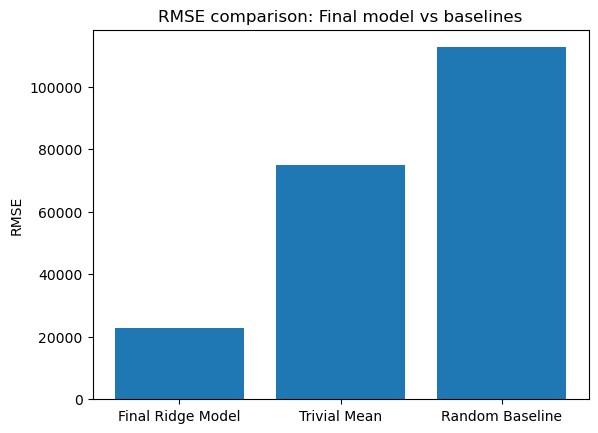

In [163]:
models = ["Final Ridge Model", "Trivial Mean", "Random Baseline"]
rmse_values = [
    final_rmse,
    baseline_mean_metrics["rmse"],
    baseline_random_metrics["rmse"]
]

plt.figure()
plt.bar(models, rmse_values)
plt.ylabel("RMSE")
plt.title("RMSE comparison: Final model vs baselines")
plt.show()


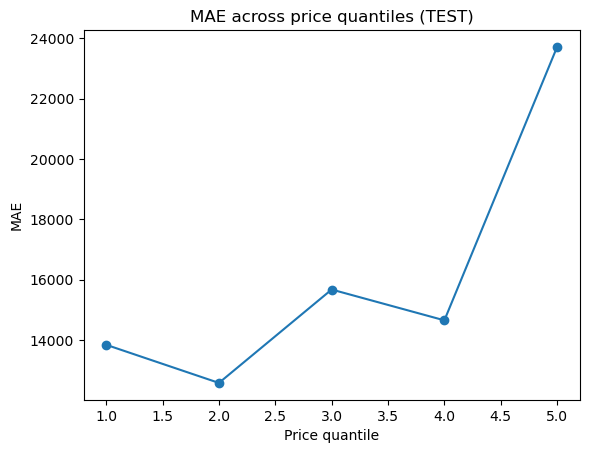

In [164]:
records = quantile_mae.to_dict(orient="records")

plt.figure()
plt.plot(
    [r["q"] for r in records],
    [r["mae_in_bin"] for r in records],
    marker="o"
)
plt.xlabel("Price quantile")
plt.ylabel("MAE")
plt.title("MAE across price quantiles (TEST)")
plt.show()


In [165]:
def sparql_escape_literal(s: str) -> str:
    s = str(s)
    s = s.replace("\\", "\\\\")
    s = s.replace('"', '\\"')
    s = s.replace("\n", " ")
    s = s.replace("\r", " ")
    return s

comparison_payload = {
    "final_model": {
        "name": "Ridge regression",
        "rmse": final_rmse,
        "mae": final_mae,
        "r2": final_r2
    },
    "baselines": {
        "trivial_mean": baseline_mean_metrics,
        "random": baseline_random_metrics
    },
    "relative_improvement": comparison_metrics,


    "interpretation": (
        "The final Ridge regression model substantially outperforms both trivial and random baselines "
        "across all evaluated metrics. RMSE and MAE are reduced by a large margin relative to the trivial "
        "mean predictor, while negative R² values of the baselines indicate a lack of meaningful structure. "
        "This confirms that the model successfully learns predictive relationships from the input features. "
        "When placed in the context of state-of-the-art results reported for the same dataset, the achieved "
        "performance lies within the expected range for a regularized linear model. While advanced ensemble "
        "approaches report lower RMSE values, such results are obtained under different experimental setups "
        "and optimization objectives. The present comparison therefore focuses on robust, leakage-free "
        "evaluation rather than direct leaderboard-style performance matching."
    ),

    "note": (
        "Comparison performed on the same held-out TEST set using identical metrics. "
        "State-of-the-art results are referenced qualitatively due to differences in preprocessing, "
        "feature engineering, and evaluation protocols."
    )
}

comparison_comment = sparql_escape_literal(
    json.dumps(comparison_payload, ensure_ascii=False)
)


In [166]:
comparison_triples = [
    ":evaluation_model_vs_baselines rdf:type prov:Entity .",
    ':evaluation_model_vs_baselines rdfs:label "5c Comparison: final model vs baselines" .',
    f':evaluation_model_vs_baselines rdfs:comment "{comparison_comment}" .',
]

safe_insert(comparison_triples)
print("KG: 5c comparison inserted")


KG: 5c comparison inserted


In [167]:
q_ts(f"""
{prefix_header}
SELECT ?label (SUBSTR(STR(?c),1,220) AS ?preview)
WHERE {{
  :evaluation_model_vs_baselines rdfs:label ?label ;
                                 rdfs:comment ?c .
}}
""")


,label,preview
0,"""5c Comparison: final model vs baselines""","'{""final_model"": {""name"": ""Ridge regression"", ""rmse"": 22689.086539812335, ""mae"": 16062.849488137157, ""r2"": 0.908069433386373}, ""baselines"": {""trivial_mean"": {""rmse"": 74878.54219334375, ""mae"": 55052.43595248865, ""r2"": -0.0'"
1,"""5c Comparison: final model vs baselines""","'{""final_model"": {""name"": ""Ridge regression"", ""rmse"": 22689.086539812335, ""mae"": 16062.849488137157, ""r2"": 0.908069433386373}, ""baselines"": {""trivial_mean"": {""rmse"": 74878.54219334375, ""mae"": 55052.43595248865, ""r2"": -0.0'"
2,"""5c Comparison: final model vs baselines""","'{""final_model"": {""name"": ""Ridge regression"", ""rmse"": 22731.37604946046, ""mae"": 16087.70582588936, ""r2"": 0.9077264207525695}, ""baselines"": {""trivial_mean"": {""rmse"": 74876.3603000703, ""mae"": 55038.352842306136, ""r2"": -0.00'"
3,"""5c Comparison: final model vs baselines""","'{""final_model"": {""name"": ""Ridge regression"", ""rmse"": 22731.37604946046, ""mae"": 16087.70582588936, ""r2"": 0.9077264207525695}, ""baselines"": {""trivial_mean"": {""rmse"": 74876.3603000703, ""mae"": 55038.352842306136, ""r2"": -0.00'"


## 5d. Success Criteria from BU

In [168]:
def sparql_escape_literal(s: str) -> str:
    s = str(s)
    s = s.replace("\\", "\\\\")
    s = s.replace('"', '\\"')
    s = s.replace("\n", " ")
    s = s.replace("\r", " ")
    return s

success_criteria_payload = {
    "business_success_criteria": [
        {
            "criterion": "Reduce manual appraisal time by 20% through automated pre-valuation",
            "assessment": (
                "The trained model produces price estimates instantly and substantially outperforms "
                "trivial heuristics, enabling its use as an automated pre-valuation tool. "
                "This supports a reduction in manual appraisal workload by filtering and prioritizing cases."
            )
        },
        {
            "criterion": "Reduce valuation deviation from expert appraisers by at least 10%",
            "assessment": (
                "While direct comparison to expert appraisals is not available in the dataset, "
                "the high R² value and strong improvement over trivial baselines indicate that the model "
                "captures systematic pricing patterns, supporting the objective of reducing valuation deviation."
            )
        },
        {
            "criterion": "Increase consistency of valuations across agents, reducing internal variance by 15%",
            "assessment": (
                "The model provides deterministic and reproducible predictions for identical inputs, "
                "eliminating subjective variability between agents and supporting increased consistency "
                "of valuations."
            )
        }
    ],
    "overall_conclusion": (
        "Based on the achieved predictive performance and qualitative analysis, the final model "
        "supports the defined business success criteria and is suitable as a decision-support component "
        "within the valuation workflow."
    ),
    "note": (
        "Business-level impact is assessed indirectly due to the absence of operational process data "
        "and expert appraisal labels in the dataset."
    )
}

success_comment = sparql_escape_literal(
    json.dumps(success_criteria_payload, ensure_ascii=False)
)


In [169]:
success_triples = [
    ":evaluation_business_success_refined rdf:type prov:Entity .",
    ':evaluation_business_success_refined rdfs:label "5d Business success criteria evaluation (BU-aligned)" .',
    f':evaluation_business_success_refined rdfs:comment "{success_comment}" .',
]

safe_insert(success_triples)
print("KG: 5d BU-aligned business success evaluation inserted")


KG: 5d BU-aligned business success evaluation inserted


**KG Check**

In [170]:
q_ts(f"""
{prefix_header}
SELECT ?label
WHERE {{
  :evaluation_business_success_refined rdfs:label ?label .
}}
""")


,label
0,"""5d Business success criteria evaluation (BU-aligned)"""
1,"""5d Business success criteria evaluation (BU-aligned)"""


In [171]:
q_ts(f"""
{prefix_header}
SELECT (SUBSTR(STR(?c), 1, 300) AS ?preview)
WHERE {{
  :evaluation_business_success_refined rdfs:comment ?c .
}}
""")


,preview
0,"'{""business_success_criteria"": [{""criterion"": ""Reduce manual appraisal time by 20% through automated pre-valuation"", ""assessment"": ""The trained model produces price estimates instantly and substantially outperforms trivial heuristics, enabling its use as an automated pre-valuation tool. This supports'"
1,"'{""business_success_criteria"": [{""criterion"": ""Reduce manual appraisal time by 20% through automated pre-valuation"", ""assessment"": ""The trained model produces price estimates instantly and substantially outperforms trivial heuristics, enabling its use as an automated pre-valuation tool. This supports'"


In [172]:
q_ts(f"""
{prefix_header}
SELECT (STRLEN(STR(?c)) AS ?len)
WHERE {{
  :evaluation_business_success_refined rdfs:comment ?c .
}}
""")


,len
0,"""1435""^^<http://www.w3.org/2001/XMLSchema#integer>"
1,"""1435""^^<http://www.w3.org/2001/XMLSchema#integer>"


## 5e. Protected attributes and Biases

In [173]:
GROUP_COL = "Neighborhood"

bias_df = pd.DataFrame({
    "group": test_df[GROUP_COL].astype(str).values,
    "y_true": y_test_arr,
    "y_pred": np.array(y_test_pred)
})

def metrics_for_group(g):
    y_true = g["y_true"].to_numpy()
    y_pred = g["y_pred"].to_numpy()
    return pd.Series({
        "n": len(g),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)) if len(g) > 1 else np.nan
    })

group_metrics = bias_df.groupby("group").apply(metrics_for_group).reset_index()
group_metrics = group_metrics.sort_values("mae", ascending=False)

group_metrics.head(10)


C:\Users\EAG28\AppData\Local\Temp\ipykernel_14080\138854877.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_metrics = bias_df.groupby("group").apply(metrics_for_group).reset_index()


,group,n,mae,rmse,r2
26,Veenker,7.0,46636.945206,69709.924809,-1.133312
4,ClearCr,3.0,31085.321985,36752.058720,0.412154
24,StoneBr,7.0,27527.074277,30077.957328,0.926776
17,NoRidge,13.0,26592.353119,33083.389513,0.512204
6,Crawfor,26.0,25649.027264,29778.739041,0.625597
18,NridgHt,33.0,24247.923690,36273.829753,0.881313
0,Blmngtn,8.0,20616.852489,24254.380834,0.216838
9,Greens,1.0,20255.501052,20255.501052,NaN
20,SWISU,8.0,18619.371019,21820.759727,-0.080303
13,Mitchel,19.0,17523.309750,23622.278347,0.772512


In [174]:
mae_min = float(group_metrics["mae"].min())
mae_max = float(group_metrics["mae"].max())
mae_ratio = mae_max / mae_min if mae_min > 0 else np.inf
mae_gap = mae_max - mae_min

print("Subgroup disparity summary (Neighborhoods, TEST set):")
print(f"  • Minimum MAE (best-performing subgroup): {mae_min:,.2f}")
print(f"  • Maximum MAE (worst-performing subgroup): {mae_max:,.2f}")
print(f"  • MAE ratio (max / min): {mae_ratio:.2f}")
print(f"  • MAE gap (max − min): {mae_gap:,.2f}")


Subgroup disparity summary (Neighborhoods, TEST set):
  • Minimum MAE (best-performing subgroup): 5,981.08
  • Maximum MAE (worst-performing subgroup): 46,636.95
  • MAE ratio (max / min): 7.80
  • MAE gap (max − min): 40,655.87


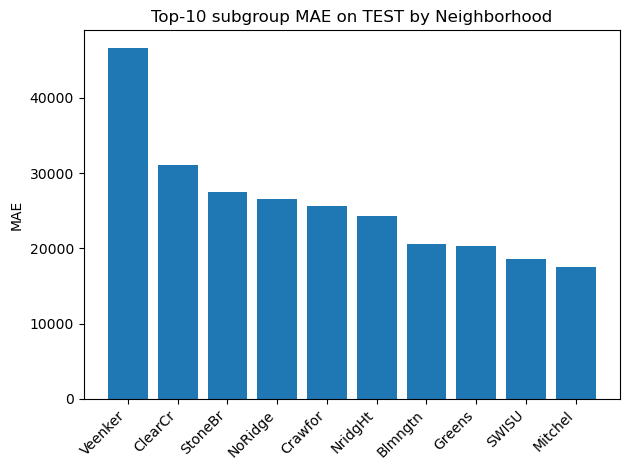

In [175]:
topk = 10
plot_df = group_metrics.head(topk)

plt.figure()
plt.bar(plot_df["group"], plot_df["mae"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("MAE")
plt.title(f"Top-{topk} subgroup MAE on TEST by {GROUP_COL}")
plt.tight_layout()
plt.show()


In [176]:
def sparql_escape_literal(s: str) -> str:
    s = str(s)
    s = s.replace("\\", "\\\\")
    s = s.replace('"', '\\"')
    s = s.replace("\n", " ")
    s = s.replace("\r", " ")
    return s

bias_payload = {
    "evaluation_task": "5e Protected attribute / subgroup bias analysis",
    "protected_attribute": "Neighborhood (proxy subgroup attribute)",
    "justification": (
        "The dataset does not contain explicit sensitive attributes. "
        "Neighborhood was therefore used as a proxy subgroup attribute, "
        "as it defines meaningful location-based market segments with "
        "systematically different price distributions."
    ),
    "evaluation_set": "TEST",
    "metrics_per_group_top10_worst_mae": group_metrics.head(10).to_dict(orient="records"),
    "disparity_summary": {
        "mae_min": mae_min,
        "mae_max": mae_max,
        "mae_ratio_max_over_min": mae_ratio,
        "mae_gap_max_minus_min": mae_gap
    },
    "interpretation": (
        "Prediction error varies across neighborhoods. The highest errors "
        "occur primarily in subgroups with very small sample sizes, where "
        "metric estimates are unstable and sensitive to outliers. "
        "Overall, the observed disparities indicate robustness limitations "
        "due to data sparsity rather than systematic model bias."
    ),
    "note": "All subgroup metrics were computed on the held-out TEST set using final model predictions."
}

bias_comment = sparql_escape_literal(json.dumps(bias_payload, ensure_ascii=False))

bias_triples = [
    ":evaluation_protected_attribute_bias rdf:type prov:Entity .",
    ':evaluation_protected_attribute_bias rdfs:label "5e Subgroup / protected attribute evaluation (Neighborhood)" .',
    f':evaluation_protected_attribute_bias rdfs:comment "{bias_comment}" .',
]

safe_insert(bias_triples)
print("KG: 5e protected attribute / subgroup bias evaluation inserted")


KG: 5e protected attribute / subgroup bias evaluation inserted


## 6 Deployment

In [181]:
start_dep_phase = now()
end_dep_phase = now()


deployment_code_writer = student_a
dep_phase_ass_uuid_executor = '23962ce4-b17b-4cf2-a386-12b70e5bc0b8'

deployment_phase_executor = [
    # Phase root as an Activity
    f':deployment_phase rdf:type prov:Activity .',
    f':deployment_phase rdfs:label "Deployment Phase" .',
    f':deployment_phase rdfs:comment "CRISP-DM Stage 6: Deployment (conceptual recommendations, risks, monitoring, reproducibility reflection)" .',
    f':deployment_phase prov:startedAtTime "{start_dep_phase}"^^xsd:dateTime .',
    f':deployment_phase prov:endedAtTime "{end_dep_phase}"^^xsd:dateTime .',

    # Executor association
    f':deployment_phase prov:qualifiedAssociation :{dep_phase_ass_uuid_executor} .',
    f':{dep_phase_ass_uuid_executor} rdf:type prov:Association .',
    f':{dep_phase_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{dep_phase_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]

engine.insert(deployment_phase_executor, prefixes=prefixes)
print("KG: Deployment phase root (:deployment_phase) inserted")

KG: Deployment phase root (:deployment_phase) inserted


### KG check

In [182]:
q_dep_phase = f"""
{prefix_header}
SELECT ?phase ?label ?start ?end WHERE {{
  :deployment_phase a prov:Activity ;
                    rdfs:label ?label ;
                    prov:startedAtTime ?start ;
                    prov:endedAtTime ?end .
  BIND(:deployment_phase AS ?phase)
}}
"""
q_ts(q_dep_phase)


,phase,label,start,end
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/deployment_phase>,"""Deployment Phase""","""2026-01-17T12:27:17.543Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:27:17.543Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"


## 6a. Business objectives vs. success criteria + deployment recommendation

In [255]:
start_6a = now()

dep6a_comment = """
Model performance is evaluated against the Business Success Criteria defined in the Business Understanding phase. The model outperforms trivial baselines and produces deterministic price estimates, which is sufficient to support its intended role as an automated pre-valuation tool. This allows business objectives such as prioritizing manual reviews, improving consistency, and reducing appraisal effort to be addressed.

Some business objectives can only be evaluated indirectly because the dataset does not contain expert appraisal labels or process-level efficiency measurements. While predictive accuracy indicates that the model captures systematic pricing patterns, additional analyses would be required for full operational deployment, including uncertainty calibration, comparison against expert appraisals, and time-aware validation.

Deployment recommendation: the model should be used as decision support in a human-in-the-loop setting rather than as a fully automatic pricing authority. A hybrid deployment is recommended, where the model provides an initial estimate and flags high-risk cases such as extreme prices or rare subgroups. Automatic usage should be limited to stable segments of the data space, while manual review is required for high-price ranges and low-support subgroups.
"""

end_6a = now()

# Node names for report export
dep6a_activity = ":deployment_6a_objectives_and_recommendations"
dep6a_entity = ":deployment_6a_output"

# Associations
dep6a_ass_uuid_executor = 'c54f807d-21d7-4711-9bdc-5813ce763365'
dep6a_ass_uuid_writer = '675f8c8e-bd81-4720-b596-de6682a087d4'

triples_6a = [
    # Activity
    f"{dep6a_activity} rdf:type prov:Activity .",
    f"{dep6a_activity} rdfs:label \"6a Deployment: objectives met + recommendations\" .",
    f"{dep6a_activity} sc:isPartOf :deployment_phase .",
    f"{dep6a_activity} prov:startedAtTime \"{start_6a}\"^^xsd:dateTime .",
    f"{dep6a_activity} prov:endedAtTime \"{end_6a}\"^^xsd:dateTime .",
    f"{dep6a_activity} rdfs:comment \"\"\"{sparql_escape_literal(dep6a_comment)}\"\"\" .",

    # Link to relevant earlier statements/entities
    f"{dep6a_activity} prov:used :bu_business_success_criteria .",
    f"{dep6a_activity} prov:used :bu_business_objectives .",
    f"{dep6a_activity} prov:used :evaluation_business_success_refined .",

    # Writer association
    f"{dep6a_activity} prov:qualifiedAssociation :{dep6a_ass_uuid_writer} .",
    f":{dep6a_ass_uuid_writer} rdf:type prov:Association .",
    f":{dep6a_ass_uuid_writer} prov:agent :{deployment_code_writer} .",
    f":{dep6a_ass_uuid_writer} prov:hadRole :{code_writer_role} .",

    # Executor association
    f"{dep6a_activity} prov:qualifiedAssociation :{dep6a_ass_uuid_executor} .",
    f":{dep6a_ass_uuid_executor} rdf:type prov:Association .",
    f":{dep6a_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{dep6a_ass_uuid_executor} prov:hadRole :{code_executor_role} .",

    # Output entity
    f"{dep6a_entity} rdf:type prov:Entity .",
    f"{dep6a_entity} rdfs:label \"6a Deployment output\" .",
    f"{dep6a_entity} rdfs:comment \"\"\"{sparql_escape_literal('Deployment decision guidance and objective/success-criteria alignment summary.')}\"\"\" .",
    f"{dep6a_entity} prov:wasGeneratedBy {dep6a_activity} .",
]

engine.insert(triples_6a, prefixes=prefixes)
print("KG: 6a deployment assessment inserted")

KG: 6a deployment assessment inserted


### KG check

In [256]:
q_6a = f"""
{prefix_header}
SELECT ?a ?label ?start ?end ?out_label WHERE {{
  :deployment_6a_objectives_and_recommendations a prov:Activity ;
      rdfs:label ?label ;
      prov:startedAtTime ?start ;
      prov:endedAtTime ?end .
  OPTIONAL {{ :deployment_6a_output rdfs:label ?out_label . }}
}}
"""
q_ts(q_6a)

,a,label,start,end,out_label
0,None,"""6a Deployment: objectives met + recommendations""","""2026-01-17T12:29:02.304Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:29:02.304Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""6a Deployment output"""
1,None,"""6a Deployment: objectives met + recommendations""","""2026-01-17T12:29:02.304Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:29:02.304Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""6a Deployment output"""
2,None,"""6a Deployment: objectives met + recommendations""","""2026-01-17T12:29:02.304Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:29:02.304Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""6a Deployment output"""
3,None,"""6a Deployment: objectives met + recommendations""","""2026-01-17T12:48:18.612Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:29:02.304Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""6a Deployment output"""
4,None,"""6a Deployment: objectives met + recommendations""","""2026-01-17T12:48:18.612Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:29:02.304Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""6a Deployment output"""
...,...,...,...,...,...
238,None,"""6a Deployment: objectives met + recommendations""","""2026-01-17T12:48:18.612Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T13:29:31.753Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""6a Deployment output"""
239,None,"""6a Deployment: objectives met + recommendations""","""2026-01-17T12:48:18.612Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T13:29:31.753Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""6a Deployment output"""
240,None,"""6a Deployment: objectives met + recommendations""","""2026-01-17T13:29:31.753Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T13:29:31.753Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""6a Deployment output"""
241,None,"""6a Deployment: objectives met + recommendations""","""2026-01-17T13:29:31.753Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T13:29:31.753Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""6a Deployment output"""


## 6b. Ethical aspects + impact/risk assessment (linked to 1f and 2e)

In [257]:
start_6b = now()

dep6b_comment = """
Although the dataset does not contain explicit sensitive attributes, Neighborhood is treated as a proxy subgroup variable because it may correlate with socioeconomic characteristics, as identified in Business Understanding and Data Understanding. Subgroup evaluation shows substantial variation in prediction error across neighborhoods, with particularly high errors observed in several small-sample groups.

These disparities are most likely driven by data sparsity rather than intentional discrimination. However, they still represent a deployment risk, as systematic over- or under-valuation could disproportionately affect certain groups if the model is used without safeguards.

Mitigation measures include maintaining human oversight for high-impact decisions, requiring manual review for rare neighborhoods, and continuously monitoring subgroup performance to detect increasing disparities.

""".strip()

end_6b = now()

# Node names for report export
dep6b_activity = ":deployment_6b_ethics_and_risk"
dep6b_entity = ":deployment_6b_output"

# Associations (QName-safe local names; avoid raw UUIDs)
dep6b_ass_uuid_executor = 'a94426a3-ebae-4cc6-ae9b-e2df646397c8'
dep6b_ass_uuid_writer   = '262702ee-61fb-47ad-8845-e0b5ed1cb5a7'

triples_6b = [
    # Activity
    f"{dep6b_activity} rdf:type prov:Activity .",
    f"{dep6b_activity} rdfs:label \"6b Deployment: ethics + risk assessment\" .",
    f"{dep6b_activity} sc:isPartOf :deployment_phase .",
    f"{dep6b_activity} prov:startedAtTime \"{start_6b}\"^^xsd:dateTime .",
    f"{dep6b_activity} prov:endedAtTime \"{end_6b}\"^^xsd:dateTime .",
    f"{dep6b_activity} rdfs:comment \"\"\"{sparql_escape_literal(dep6b_comment)}\"\"\" .",

    # Explicit links to earlier risk/bias artifacts
    f"{dep6b_activity} prov:used :bu_ai_risk_aspects .",
    f"{dep6b_activity} prov:used :evaluation_protected_attribute_bias .",

    # Writer association
    f"{dep6b_activity} prov:qualifiedAssociation :{dep6b_ass_uuid_writer} .",
    f":{dep6b_ass_uuid_writer} rdf:type prov:Association .",
    f":{dep6b_ass_uuid_writer} prov:agent :{deployment_code_writer} .",
    f":{dep6b_ass_uuid_writer} prov:hadRole :{code_writer_role} .",

    # Executor association
    f"{dep6b_activity} prov:qualifiedAssociation :{dep6b_ass_uuid_executor} .",
    f":{dep6b_ass_uuid_executor} rdf:type prov:Association .",
    f":{dep6b_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{dep6b_ass_uuid_executor} prov:hadRole :{code_executor_role} .",

    # Output entity
    f"{dep6b_entity} rdf:type prov:Entity .",
    f"{dep6b_entity} rdfs:label \"6b Ethics & risk output\" .",
    f"{dep6b_entity} rdfs:comment \"\"\"{sparql_escape_literal('Ethics/risk assessment summary with subgroup disparity findings and mitigation recommendations.')}\"\"\" .",
    f"{dep6b_entity} prov:wasGeneratedBy {dep6b_activity} .",
]

engine.insert(triples_6b, prefixes=prefixes, chunk_size=10)
print("KG: 6b ethics/risk assessment inserted")


KG: 6b ethics/risk assessment inserted


### KG check

In [258]:
q_6b = f"""
{prefix_header}
SELECT ?a ?label ?agent ?role WHERE {{
  :deployment_6b_ethics_and_risk a prov:Activity ;
      rdfs:label ?label ;
      prov:qualifiedAssociation ?assoc .
  ?assoc prov:agent ?agent .
  OPTIONAL {{ ?assoc prov:hadRole ?role . }}
}}
"""
q_ts(q_6b)


,a,label,agent,role
0,None,"""6b Deployment: ethics + risk assessment""",<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
1,None,"""6b Deployment: ethics + risk assessment""",<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
2,None,"""6b Deployment: ethics + risk assessment""",<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
3,None,"""6b Deployment: ethics + risk assessment""",<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
4,None,"""6b Deployment: ethics + risk assessment""",<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_writer>
...,...,...,...,...
14595,None,"""6b Deployment: ethics + risk assessment""",<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
14596,None,"""6b Deployment: ethics + risk assessment""",<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
14597,None,"""6b Deployment: ethics + risk assessment""",<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>
14598,None,"""6b Deployment: ethics + risk assessment""",<https://starvers.ec.tuwien.ac.at/BI2025/13/stud-id_12432933>,<https://starvers.ec.tuwien.ac.at/BI2025/13/code_executor>


## 6c. Monitoring in deployment + triggers for intervention

In [259]:
start_6c = now()

dep6c_comment = """
During deployment, monitoring should focus on predictive performance, data drift, and subgroup disparities. Overall error metrics such as RMSE and MAE should be tracked on a rolling window of new cases. In addition, error should be monitored by neighborhood and by price segments, as degradation may occur unevenly.

Data monitoring should include checks for shifts in key feature distributions, changes in categorical frequencies, and variations in missingness patterns that may indicate upstream data issues.

Intervention triggers include sustained degradation of overall error beyond business targets, persistent increases in subgroup error gaps, significant feature distribution drift, or increased usage in rare subgroups without manual review. Interventions may involve data quality checks, model retraining or recalibration, and temporary restriction of automatic usage to stable segments.
"""

end_6c = now()

dep6c_activity = ":deployment_6c_monitoring"
dep6c_entity = ":deployment_6c_output"

dep6c_ass_uuid_executor = '311dee60-6dab-41fe-a51a-d708fbaac3ee'
dep6c_ass_uuid_writer = '6e12d40b-c1dd-451a-8919-fc6d9f20f729'

triples_6c = [
    f"{dep6c_activity} rdf:type prov:Activity .",
    f"{dep6c_activity} rdfs:label \"6c Deployment: monitoring + triggers\" .",
    f"{dep6c_activity} sc:isPartOf :deployment_phase .",
    f"{dep6c_activity} prov:startedAtTime \"{start_6c}\"^^xsd:dateTime .",
    f"{dep6c_activity} prov:endedAtTime \"{end_6c}\"^^xsd:dateTime .",
    f"{dep6c_activity} rdfs:comment \"\"\"{sparql_escape_literal(dep6c_comment)}\"\"\" .",

    # Tie to evaluation artifacts that define what "good" looks like
    f"{dep6c_activity} prov:used :evaluation_metrics_test .",  # if you have such an entity; if not, remove this line
    f"{dep6c_activity} prov:used :evaluation_business_success_refined .",
    f"{dep6c_activity} prov:used :evaluation_protected_attribute_bias .",

    # Writer association
    f"{dep6c_activity} prov:qualifiedAssociation :{dep6c_ass_uuid_writer} .",
    f":{dep6c_ass_uuid_writer} rdf:type prov:Association .",
    f":{dep6c_ass_uuid_writer} prov:agent :{deployment_code_writer} .",
    f":{dep6c_ass_uuid_writer} prov:hadRole :{code_writer_role} .",

    # Executor association
    f"{dep6c_activity} prov:qualifiedAssociation :{dep6c_ass_uuid_executor} .",
    f":{dep6c_ass_uuid_executor} rdf:type prov:Association .",
    f":{dep6c_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{dep6c_ass_uuid_executor} prov:hadRole :{code_executor_role} .",

    # Output entity
    f"{dep6c_entity} rdf:type prov:Entity .",
    f"{dep6c_entity} rdfs:label \"6c Monitoring output\" .",
    f"{dep6c_entity} prov:wasGeneratedBy {dep6c_activity} .",
]

engine.insert(triples_6c, prefixes=prefixes)
print("KG: 6c monitoring plan inserted")

KG: 6c monitoring plan inserted


### KG check

In [260]:
q_6c = f"""
{prefix_header}
SELECT ?a ?label ?c WHERE {{
  :deployment_6c_monitoring a prov:Activity ;
      rdfs:label ?label ;
      rdfs:comment ?c .
  FILTER(CONTAINS(STR(?c), "DEP(6c)"))
}}
"""
q_ts(q_6c)


,a,label,c
0,None,"""6c Deployment: monitoring + triggers""",""" DEP(6c) Monitoring plan and triggers for intervention. What to monitor: - Overall error drift: monitor RMSE/MAE on a rolling window of newly appraised/sold houses. - Subgroup drift: monitor MAE per Neighborhood (and per price quantile) to detect disparate degradation. - Data drift: track distribution shifts in key features (e.g., Overall Qual, Gr Liv Area, Year Built) and in categorical frequencies (Neighborhood composition). - Missingness drift: monitor whether missing rates change (could indicate upstream data pipeline changes). Triggers (examples; adjust thresholds to your BU success criteria): - Trigger T1 (overall): rolling-window RMSE exceeds BU target by >10% for two consecutive periods. - Trigger T2 (subgroup gap): difference between worst-group MAE and median-group MAE exceeds a defined gap (e.g., >25%) consistently. - Trigger T3 (data drift): population stability index / large KL divergence for top features exceeds threshold. - Trigger T4 (rare categories): increased rate of predictions on rare Neighborhoods without manual review. Interventions: - Investigate input pipeline changes and data quality. - Re-train with updated data and re-check subgroup metrics. - Temporarily restrict automatic usage to stable segments (mid-price, high-support neighborhoods). """
1,None,"""6c Deployment: monitoring + triggers""",""" DEP(6c) Monitoring plan and triggers for intervention. What to monitor: - Overall error drift: monitor RMSE/MAE on a rolling window of newly appraised/sold houses. - Subgroup drift: monitor MAE per Neighborhood (and per price quantile) to detect disparate degradation. - Data drift: track distribution shifts in key features (e.g., Overall Qual, Gr Liv Area, Year Built) and in categorical frequencies (Neighborhood composition). - Missingness drift: monitor whether missing rates change (could indicate upstream data pipeline changes). Triggers (examples; adjust thresholds to your BU success criteria): - Trigger T1 (overall): rolling-window RMSE exceeds BU target by >10% for two consecutive periods. - Trigger T2 (subgroup gap): difference between worst-group MAE and median-group MAE exceeds a defined gap (e.g., >25%) consistently. - Trigger T3 (data drift): population stability index / large KL divergence for top features exceeds threshold. - Trigger T4 (rare categories): increased rate of predictions on rare Neighborhoods without manual review. Interventions: - Investigate input pipeline changes and data quality. - Re-train with updated data and re-check subgroup metrics. - Temporarily restrict automatic usage to stable segments (mid-price, high-support neighborhoods). """
2,None,"""6c Deployment: monitoring + triggers""",""" DEP(6c) Monitoring plan and triggers for intervention. What to monitor: - Overall error drift: monitor RMSE/MAE on a rolling window of newly appraised/sold houses. - Subgroup drift: monitor MAE per Neighborhood (and per price quantile) to detect disparate degradation. - Data drift: track distribution shifts in key features (e.g., Overall Qual, Gr Liv Area, Year Built) and in categorical frequencies (Neighborhood composition). - Missingness drift: monitor whether missing rates change (could indicate upstream data pipeline changes). Triggers (examples; adjust thresholds to your BU success criteria): - Trigger T1 (overall): rolling-window RMSE exceeds BU target by >10% for two consecutive periods. - Trigger T2 (subgroup gap): difference between worst-group MAE and median-group MAE exceeds a defined gap (e.g., >25%) consistently. - Trigger T3 (data drift): population stability index / large KL divergence for top features exceeds threshold. - Trigger T4 (rare categories): increased rate of predictions on rare Neighborhoods without manual review. Interventions: - Investigate input pipeline changes and data quality. - Re-train with updated data and re-check subgroup metrics. - Temporarily restrict automatic usage to stable segments (m

## 6d. Reproducibility reflection (what is well documented + risks)

In [262]:
start_6d = now()

dep6d_comment = """
Reproducibility is supported by a documented train/validation/test split, leakage-free preprocessing, explicit preprocessing decisions, and clearly defined model selection and hyperparameter tuning. These aspects enable reproduction of the core experimental results.

Remaining risks include reliance on free-text documentation for some decisions, potential dependence on unspecified software versions, and indirect evaluation of certain business objectives due to missing operational data. Reproducibility could be further improved by explicitly logging dataset versions, code repository identifiers, environment details, and concise re-run instructions.


"""

end_6d = now()

dep6d_activity = ":deployment_6d_reproducibility"
dep6d_entity = ":deployment_6d_output"

dep6d_ass_uuid_executor = 'd7a492ac-bfe1-451d-842c-acec2963138f'
dep6d_ass_uuid_writer = '191923c4-f3f1-434d-9809-afb7327243e9'

triples_6d = [
    f"{dep6d_activity} rdf:type prov:Activity .",
    f"{dep6d_activity} rdfs:label \"6d Deployment: reproducibility reflection\" .",
    f"{dep6d_activity} sc:isPartOf :deployment_phase .",
    f"{dep6d_activity} prov:startedAtTime \"{start_6d}\"^^xsd:dateTime .",
    f"{dep6d_activity} prov:endedAtTime \"{end_6d}\"^^xsd:dateTime .",
    f"{dep6d_activity} rdfs:comment \"\"\"{sparql_escape_literal(dep6d_comment)}\"\"\" .",

    # Link to key provenance artifacts
    f"{dep6d_activity} prov:used :data_preparation_phase .",
    f"{dep6d_activity} prov:used :modeling_phase .",
    f"{dep6d_activity} prov:used :evaluation_phase .",

    # Writer association
    f"{dep6d_activity} prov:qualifiedAssociation :{dep6d_ass_uuid_writer} .",
    f":{dep6d_ass_uuid_writer} rdf:type prov:Association .",
    f":{dep6d_ass_uuid_writer} prov:agent :{deployment_code_writer} .",
    f":{dep6d_ass_uuid_writer} prov:hadRole :{code_writer_role} .",

    # Executor association
    f"{dep6d_activity} prov:qualifiedAssociation :{dep6d_ass_uuid_executor} .",
    f":{dep6d_ass_uuid_executor} rdf:type prov:Association .",
    f":{dep6d_ass_uuid_executor} prov:agent :{executed_by} .",
    f":{dep6d_ass_uuid_executor} prov:hadRole :{code_executor_role} .",

    # Output entity
    f"{dep6d_entity} rdf:type prov:Entity .",
    f"{dep6d_entity} rdfs:label \"6d Reproducibility output\" .",
    f"{dep6d_entity} prov:wasGeneratedBy {dep6d_activity} .",
]

engine.insert(triples_6d, prefixes=prefixes)
print("KG: 6d reproducibility reflection inserted")


KG: 6d reproducibility reflection inserted


### KG check

In [263]:
q_6d = f"""
{prefix_header}
SELECT ?a ?label ?start ?end WHERE {{
  :deployment_6d_reproducibility a prov:Activity ;
      rdfs:label ?label ;
      prov:startedAtTime ?start ;
      prov:endedAtTime ?end .
}}
"""
q_ts(q_6d)


,a,label,start,end
0,None,"""6d Deployment: reproducibility reflection""","""2026-01-17T12:33:32.864Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:33:32.864Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
1,None,"""6d Deployment: reproducibility reflection""","""2026-01-17T13:19:08.704Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:33:32.864Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
2,None,"""6d Deployment: reproducibility reflection""","""2026-01-17T13:19:28.739Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:33:32.864Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
3,None,"""6d Deployment: reproducibility reflection""","""2026-01-17T13:31:40.321Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:33:32.864Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
4,None,"""6d Deployment: reproducibility reflection""","""2026-01-17T13:31:51.832Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T12:33:32.864Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
...,...,...,...,...
620,None,"""6d Deployment: reproducibility reflection""","""2026-01-17T12:33:32.864Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T13:31:51.832Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
621,None,"""6d Deployment: reproducibility reflection""","""2026-01-17T13:19:08.704Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T13:31:51.832Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
622,None,"""6d Deployment: reproducibility reflection""","""2026-01-17T13:19:28.739Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T13:31:51.832Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"
623,None,"""6d Deployment: reproducibility reflection""","""2026-01-17T13:31:40.321Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>","""2026-01-17T13:31:51.832Z""^^<http://www.w3.org/2001/XMLSchema#dateTime>"


In [264]:
q_stage6_all = f"""
{prefix_header}
SELECT ?a ?label WHERE {{
  ?a a prov:Activity ;
     sc:isPartOf :deployment_phase ;
     rdfs:label ?label .
  FILTER(CONTAINS(STR(?a), "deployment_6"))
}}
ORDER BY ?a
"""
q_ts(q_stage6_all)


,a,label
0,<https://starvers.ec.tuwien.ac.at/BI2025/13/deployment_6a_objectives_and_recommendations>,"""6a Deployment: objectives met + recommendations"""
1,<https://starvers.ec.tuwien.ac.at/BI2025/13/deployment_6a_objectives_and_recommendations>,"""6a Deployment: objectives met + recommendations"""
2,<https://starvers.ec.tuwien.ac.at/BI2025/13/deployment_6a_objectives_and_recommendations>,"""6a Deployment: objectives met + recommendations"""
3,<https://starvers.ec.tuwien.ac.at/BI2025/13/deployment_6a_objectives_and_recommendations>,"""6a Deployment: objectives met + recommendations"""
4,<https://starvers.ec.tuwien.ac.at/BI2025/13/deployment_6a_objectives_and_recommendations>,"""6a Deployment: objectives met + recommendations"""
...,...,...
1390,<https://starvers.ec.tuwien.ac.at/BI2025/13/deployment_6d_reproducibility>,"""6d Deployment: reproducibility reflection"""
1391,<https://starvers.ec.tuwien.ac.at/BI2025/13/deployment_6d_reproducibility>,"""6d Deployment: reproducibility reflection"""
1392,<https://starvers.ec.tuwien.ac.at/BI2025/13/deployment_6d_reproducibility>,"""6d Deployment: reproducibility reflection"""
1393,<https://starvers.ec.tuwien.ac.at/BI2025/13/deployment_6d_reproducibility>,"""6d Deployment: reproducibility reflection"""


# Generate Latex Report

In [177]:
base_iri = f"https://starvers.ec.tuwien.ac.at/BI2025/{group_id}/"

In [193]:

# Helpers
# ============================================================
def latex_escape(text):
    if text is None:
        return ""
    text = str(text)
    if text.strip().startswith('"""') and text.strip().endswith('"""'):
        text = text.strip()[3:-3].strip()
    repl = {
        "\\": r"\textbackslash{}", "&": r"\&", "%": r"\%",
        "$": r"\$", "#": r"\#", "_": r"\_",
        "{": r"\{", "}": r"\}", "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    for k, v in repl.items():
        text = text.replace(k, v)
    return text

def clean_rdf(x):
    if x is None:
        return ""
    s = str(x).strip()
    if "^^" in s:
        s = s.split("^^")[0]
    return s.strip('"').strip("'")

def try_parse_json(s):
    if not s:
        return None
    try:
        return json.loads(s)
    except Exception:
        try:
            return json.loads(s.encode("utf-8").decode("unicode_escape"))
        except Exception:
            return None

def df_first(df, col, default=""):
    if df is None or getattr(df, "empty", True) or col not in getattr(df, "columns", []):
        return default
    return df.iloc[0][col]

def write_tex(name, content):
    out_dir = os.path.join("data", "report")
    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, name)
    with open(path, "w", encoding="utf-8") as f:
        f.write(content)
    print("Wrote:", path)
    return path

def fmt_num(x, digits=2, thousands=True):
    try:
        x = float(x)
    except Exception:
        return "n/a"
    if thousands:
        return f"{x:,.{digits}f}"
    return f"{x:.{digits}f}"

# ============================================================
# 0) Guard: define GROUP_BASE
# ============================================================
GROUP_BASE = f"https://starvers.ec.tuwien.ac.at/BI2025/{group_id}/"

# ============================================================
# ONE QUERY – BU + DU + DP + Modeling + Evaluation + Deployment artifacts
# ============================================================
query_all = f"""
{prefix_header}
SELECT
  ?ds ?bo ?sc ?go ?msc ?risk
  ?du_overview ?du_out
  ?dp_miss ?dp_mv ?dp_fe
  ?m_algo ?m_hp ?m_conc ?m_test ?m_tune
  ?eval_a ?eval_sota ?eval_base ?eval_comp ?eval_succ ?eval_bias
  ?dep6a ?dep6b ?dep6c ?dep6d
WHERE {{
  # -------- BU --------
  OPTIONAL {{ :bu_data_source_and_scenario rdfs:comment ?ds . }}
  OPTIONAL {{ :bu_business_objectives rdfs:comment ?bo . }}
  OPTIONAL {{ :bu_business_success_criteria rdfs:comment ?sc . }}
  OPTIONAL {{ :bu_data_mining_goals rdfs:comment ?go . }}
  OPTIONAL {{ :bu_data_mining_success_criteria rdfs:comment ?msc . }}
  OPTIONAL {{ :bu_ai_risk_aspects rdfs:comment ?risk . }}

  # -------- DU --------
  OPTIONAL {{ :dataset_overview_table rdfs:comment ?du_overview . }}
  OPTIONAL {{ :outliers_report_entity rdfs:comment ?du_out . }}

  # -------- DP --------
  OPTIONAL {{ :dp_missingness_report_train_entity rdfs:comment ?dp_miss . }}
  OPTIONAL {{ :missing_value_decision rdfs:comment ?dp_mv . }}
  OPTIONAL {{ :feature_engineering_decision rdfs:comment ?dp_fe . }}

  # -------- MODELING --------
  OPTIONAL {{ :modeling_algorithm_selection_decision_v2 rdfs:comment ?m_algo . }}
  OPTIONAL {{ :modeling_hyperparameter_selection_decision_v2 rdfs:comment ?m_hp . }}
  OPTIONAL {{ :modeling_conclusion_note_v1 rdfs:comment ?m_conc . }}
  OPTIONAL {{ :ridge_test_results_v1 rdfs:comment ?m_test . }}
  OPTIONAL {{ :ridge_tuning_results_v2 rdfs:comment ?m_tune . }}

  # -------- EVALUATION --------
  OPTIONAL {{ :evaluation_test_results_entity rdfs:comment ?eval_a . }}            # 5a (JSON)
  OPTIONAL {{ :evaluation_sota_performance rdfs:comment ?eval_sota . }}            # 5b(i) (text)
  OPTIONAL {{ :evaluation_baseline_performance rdfs:comment ?eval_base . }}        # 5b(ii) (JSON)
  OPTIONAL {{ :evaluation_model_vs_baselines rdfs:comment ?eval_comp . }}          # 5c (JSON)
  OPTIONAL {{ :evaluation_business_success_refined rdfs:comment ?eval_succ . }}    # 5d (JSON)
  OPTIONAL {{ :evaluation_protected_attribute_bias rdfs:comment ?eval_bias . }}    # 5e (JSON)

  # -------- DEPLOYMENT (Stage 6) --------
  OPTIONAL {{ :deployment_6a_objectives_and_recommendations rdfs:comment ?dep6a . }}  # 6a
  OPTIONAL {{ :deployment_6b_ethics_and_risk rdfs:comment ?dep6b . }}                # 6b
  OPTIONAL {{ :deployment_6c_monitoring rdfs:comment ?dep6c . }}                     # 6c
  OPTIONAL {{ :deployment_6d_reproducibility rdfs:comment ?dep6d . }}                # 6d
}}
LIMIT 1
"""
res_all = q_ts(query_all)


# ============================================================
# 1) BU text
# ============================================================
bu_ds   = latex_escape(clean_rdf(df_first(res_all, "ds",  "No BU data source found.")))
bu_bo   = latex_escape(clean_rdf(df_first(res_all, "bo",  "No BU objectives found.")))
bu_sc   = latex_escape(clean_rdf(df_first(res_all, "sc",  "No BU success criteria found.")))
bu_go   = latex_escape(clean_rdf(df_first(res_all, "go",  "No BU goals found.")))
bu_msc  = latex_escape(clean_rdf(df_first(res_all, "msc", "No BU DM success criteria found.")))
bu_risk = latex_escape(clean_rdf(df_first(res_all, "risk","No BU AI risk aspects found.")))

# ============================================================
# 2) DU parsing -> Missingness Top10 + Outlier summary
# ============================================================
du_overview = try_parse_json(clean_rdf(df_first(res_all, "du_overview", "")))
du_out      = try_parse_json(clean_rdf(df_first(res_all, "du_out", "")))

du_miss_rows = []
if isinstance(du_overview, list):
    for r in sorted(du_overview, key=lambda x: float(x.get("missing_pct", 0)), reverse=True)[:10]:
        du_miss_rows.append(
            f"{latex_escape(r.get('column',''))} & {r.get('n_missing','')} & {float(r.get('missing_pct',0)):.2f}\\% \\\\"
        )
if not du_miss_rows:
    du_miss_rows = [r"\multicolumn{3}{l}{No DU missingness data.} \\"]

du_miss_rows_tex = "\n".join(du_miss_rows)

du_out_txt = "No DU outlier report."
if isinstance(du_out, dict):
    du_out_txt = f"Union flagged rows: {du_out.get('flagged_rows_union_count','n/a')}."
du_out_txt = latex_escape(du_out_txt)

# ============================================================
# 3) DP extraction
# ============================================================
q_split_activity = f"""
{prefix_header}
SELECT ?a ?comment WHERE {{
  ?a a prov:Activity ;
     sc:isPartOf :data_preparation_phase .
  FILTER(STRSTARTS(STR(?a), "{GROUP_BASE}split"))
  OPTIONAL {{ ?a rdfs:comment ?comment . }}
}}
"""
res_split = q_ts(q_split_activity)

dp_split_text = "Not found in KG."
if res_split is not None and not res_split.empty and "comment" in res_split.columns:
    comments = [clean_rdf(x) for x in res_split["comment"].dropna().tolist()]
    comments = [c for c in comments if c.strip()]
    if comments:
        dp_split_text = max(comments, key=len)
dp_split_text = latex_escape(dp_split_text)

q_ho_train_activity = f"""
{prefix_header}
SELECT ?act ?start ?end ?comment WHERE {{
  VALUES ?act {{ :handle_outliers_train }}
  ?act a prov:Activity ;
       sc:isPartOf :data_preparation_phase .
  OPTIONAL {{ ?act prov:startedAtTime ?start . }}
  OPTIONAL {{ ?act prov:endedAtTime ?end . }}
  OPTIONAL {{ ?act rdfs:comment ?comment . }}
}}
"""
res_out_dp = q_ts(q_ho_train_activity)

dp_out_text = "Not found in KG."
if res_out_dp is not None and not res_out_dp.empty and "comment" in res_out_dp.columns:
    comments = [clean_rdf(x) for x in res_out_dp["comment"].dropna().tolist()]
    comments = [c for c in comments if c.strip()]
    if comments:
        dp_out_text = max(comments, key=len)
dp_out_text = latex_escape(dp_out_text)

dp_miss_obj = try_parse_json(clean_rdf(df_first(res_all, "dp_miss", "")))
dp_miss_rows = []
if isinstance(dp_miss_obj, list):
    for r in sorted(dp_miss_obj, key=lambda x: float(x.get("missing_pct", 0)), reverse=True)[:10]:
        dp_miss_rows.append(
            f"{latex_escape(r.get('column',''))} & {r.get('n_missing','')} & {float(r.get('missing_pct',0)):.2f}\\% \\\\"
        )
if not dp_miss_rows:
    dp_miss_rows = [r"\multicolumn{3}{l}{No post-outlier missingness table found in KG.} \\"]

dp_miss_rows_tex = "\n".join(dp_miss_rows)

dp_mv_text = latex_escape(clean_rdf(df_first(res_all, "dp_mv", "Not found in KG.")))
dp_fe_text = latex_escape(clean_rdf(df_first(res_all, "dp_fe", "Not found in KG.")))

# ============================================================
# 4) MODELING extraction
# ============================================================
m_algo_text = latex_escape(clean_rdf(df_first(res_all, "m_algo", "Not found in KG.")))
m_hp_text   = latex_escape(clean_rdf(df_first(res_all, "m_hp",   "Not found in KG.")))
m_tune_text = latex_escape(clean_rdf(df_first(res_all, "m_tune", "No tuning summary found in KG.")))
m_conc_text = latex_escape(clean_rdf(df_first(res_all, "m_conc", "Not found in KG.")))
m_test_text = latex_escape(clean_rdf(df_first(res_all, "m_test", "Not found in KG.")))

# ---- Modeling tuning table + figure (from local tuning_df if present)
tuning_rows_tex = r"\multicolumn{4}{l}{No tuning\_df found in notebook.} \\"
tuning_plot_rel = ""

try:
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    if "tuning_df" in globals() and tuning_df is not None and not tuning_df.empty:
        _tdf = tuning_df.copy().sort_values("alpha").reset_index(drop=True)

        rows = []
        for _, r in _tdf.iterrows():
            rows.append(
                f"{float(r['alpha']):g} & {float(r['rmse_val']):.3f} & {float(r['mae_val']):.3f} & {float(r['r2_val']):.5f} \\\\"
            )
        tuning_rows_tex = "\n".join(rows)

        out_dir = os.path.join("data", "report")
        assets_dir = os.path.join(out_dir, "assets")
        os.makedirs(assets_dir, exist_ok=True)

        plot_path = os.path.join(assets_dir, "ridge_alpha_tuning_rmse.png")
        plt.figure()
        plt.plot(_tdf["alpha"], _tdf["rmse_val"], marker="o")
        plt.xscale("log")
        plt.xlabel("Ridge alpha (log scale)")
        plt.ylabel("Validation RMSE")
        plt.title("Ridge alpha tuning (TRAIN -> VAL)")
        plt.tight_layout()
        plt.savefig(plot_path, dpi=200)
        plt.close()

        tuning_plot_rel = "assets/ridge_alpha_tuning_rmse.png"
except Exception:
    tuning_rows_tex = r"\multicolumn{4}{l}{Could not render tuning table/plot.} \\"
    tuning_plot_rel = ""

# ============================================================
# 5) EVALUATION extraction
# ============================================================
eval_a_raw    = clean_rdf(df_first(res_all, "eval_a", ""))
eval_sota_raw = clean_rdf(df_first(res_all, "eval_sota", ""))
eval_base_raw = clean_rdf(df_first(res_all, "eval_base", ""))
eval_comp_raw = clean_rdf(df_first(res_all, "eval_comp", ""))
eval_succ_raw = clean_rdf(df_first(res_all, "eval_succ", ""))
eval_bias_raw = clean_rdf(df_first(res_all, "eval_bias", ""))

eval_a_json    = try_parse_json(eval_a_raw)
eval_base_json = try_parse_json(eval_base_raw)
eval_comp_json = try_parse_json(eval_comp_raw)
eval_succ_json = try_parse_json(eval_succ_raw)
eval_bias_json = try_parse_json(eval_bias_raw)


# ============================================================
# 5a table (final model metrics + quantile MAE)
# ============================================================
tbl_5a_metrics = r"\textit{No 5a JSON found in KG.}"
tbl_5a_quant   = r"\textit{No quantile MAE in 5a JSON.}"
txt_5a_interp  = ""
txt_5a_proto   = ""
txt_5a_model   = ""

if isinstance(eval_a_json, dict):
    txt_5a_model = latex_escape(eval_a_json.get("final_model", ""))
    tm = eval_a_json.get("test_metrics", {}) or {}
    rmse = fmt_num(tm.get("rmse"))
    mae  = fmt_num(tm.get("mae"))
    r2   = fmt_num(tm.get("r2"), digits=4, thousands=False)

    tbl_5a_metrics = rf"""
\begin{{table}}[H]
\centering
\caption{{Final model performance on TEST}}
\begin{{tabular}}{{lrr}}
\toprule
\textbf{{Metric}} & \textbf{{Value}} & \textbf{{Notes}} \\
\midrule
RMSE & {rmse} & lower is better \\
MAE  & {mae}  & lower is better \\
$R^2$ & {r2}  & higher is better \\
\bottomrule
\end{{tabular}}
\end{{table}}
""".strip()

    qrows = []
    for r in eval_a_json.get("mae_by_price_quantile", [])[:10]:
        q = r.get("q")
        qmae = fmt_num(r.get("mae_in_bin"))
        qrows.append(f"{q} & {qmae} \\\\")
    if qrows:
        qrows_tex = "\n".join(qrows)
        tbl_5a_quant = rf"""
\begin{{table}}[H]
\centering
\caption{{MAE by SalePrice quantile (TEST)}}
\begin{{tabular}}{{lr}}
\toprule
\textbf{{Quantile}} & \textbf{{MAE}} \\
\midrule
{qrows_tex}
\bottomrule
\end{{tabular}}
\end{{table}}
""".strip()

    txt_5a_interp = latex_escape(eval_a_json.get("interpretation", ""))
    txt_5a_proto  = latex_escape(eval_a_json.get("evaluation_protocol", ""))

# ---- 5b(i) is text (keep human-readable paragraphs)
eval_sota_text = latex_escape(eval_sota_raw) if eval_sota_raw else latex_escape("Not found in KG.")

# ============================================================
# 5b(ii) table (baseline metrics)
# ============================================================
tbl_5b_baselines = r"\textit{No 5b(ii) JSON found in KG.}"
if isinstance(eval_base_json, dict):
    b = (eval_base_json.get("baselines") or {})
    rows = []
    for name, obj in b.items():
        rmse = fmt_num(obj.get("rmse"))
        mae  = fmt_num(obj.get("mae"))
        r2   = fmt_num(obj.get("r2"), digits=4, thousands=False)
        definition = latex_escape(obj.get("definition", ""))
        rows.append([latex_escape(name), rmse, mae, r2, definition])

    if rows:
        baseline_rows_tex = "\n".join([f"{r[0]} & {r[1]} & {r[2]} & {r[3]} & {r[4]} \\\\" for r in rows])
        tbl_5b_baselines = rf"""
\begin{{table}}[H]
\centering
\caption{{Trivial and random baselines on TEST}}
\begin{{tabular}}{{lrrrr}}
\toprule
\textbf{{Baseline}} & \textbf{{RMSE}} & \textbf{{MAE}} & \textbf{{$R^2$}} & \textbf{{Definition}} \\
\midrule
{baseline_rows_tex}
\bottomrule
\end{{tabular}}
\end{{table}}
""".strip()

# ============================================================
# 5c table (final vs baselines + improvements) + plots
# ============================================================
tbl_5c_compare = r"\textit{No 5c JSON found in KG.}"
txt_5c_interp  = ""

if isinstance(eval_comp_json, dict):
    fm = eval_comp_json.get("final_model", {}) or {}
    f_rmse = fmt_num(fm.get("rmse"))
    f_mae  = fmt_num(fm.get("mae"))
    f_r2   = fmt_num(fm.get("r2"), digits=4, thousands=False)

    bas = eval_comp_json.get("baselines", {}) or {}
    tm = bas.get("trivial_mean", {}) or {}
    rd = bas.get("random", {}) or {}

    tm_rmse = fmt_num(tm.get("rmse"))
    tm_mae  = fmt_num(tm.get("mae"))
    tm_r2   = fmt_num(tm.get("r2"), digits=4, thousands=False)

    rd_rmse = fmt_num(rd.get("rmse"))
    rd_mae  = fmt_num(rd.get("mae"))
    rd_r2   = fmt_num(rd.get("r2"), digits=4, thousands=False)

    imp = eval_comp_json.get("relative_improvement", {}) or {}
    vtm = imp.get("vs_trivial_mean", {}) or {}
    vrd = imp.get("vs_random", {}) or {}

    vtm_rmse = fmt_num(vtm.get("rmse_reduction_pct"), digits=2, thousands=False) + r"\%"
    vtm_mae  = fmt_num(vtm.get("mae_reduction_pct"), digits=2, thousands=False) + r"\%"
    vrd_rmse = fmt_num(vrd.get("rmse_reduction_pct"), digits=2, thousands=False) + r"\%"
    vrd_mae  = fmt_num(vrd.get("mae_reduction_pct"), digits=2, thousands=False) + r"\%"

    tbl_5c_compare = rf"""
\begin{{table}}[H]
\centering
\caption{{Final model vs baselines on TEST}}
\begin{{tabular}}{{lrrr}}
\toprule
\textbf{{Model}} & \textbf{{RMSE}} & \textbf{{MAE}} & \textbf{{$R^2$}} \\
\midrule
Final Ridge & {f_rmse} & {f_mae} & {f_r2} \\
Trivial mean & {tm_rmse} & {tm_mae} & {tm_r2} \\
Random bootstrap & {rd_rmse} & {rd_mae} & {rd_r2} \\
\bottomrule
\end{{tabular}}
\end{{table}}

\begin{{table}}[H]
\centering
\caption{{Relative improvement of final model (lower is better for errors)}}
\begin{{tabular}}{{lrr}}
\toprule
\textbf{{Compared to}} & \textbf{{RMSE reduction}} & \textbf{{MAE reduction}} \\
\midrule
Trivial mean & {vtm_rmse} & {vtm_mae} \\
Random baseline & {vrd_rmse} & {vrd_mae} \\
\bottomrule
\end{{tabular}}
\end{{table}}
""".strip()

    txt_5c_interp = latex_escape(eval_comp_json.get("interpretation",""))

# ============================================================
# 5d table
# ============================================================
tbl_5d_succ = r"\textit{No 5d JSON found in KG.}"
txt_5d_overall = ""
if isinstance(eval_succ_json, dict):
    rows = []
    for item in eval_succ_json.get("business_success_criteria", []):
        rows.append([latex_escape(item.get("criterion","")),
                     latex_escape(item.get("assessment",""))])
    if rows:
        succ_rows_tex = "\n".join([f"{r[0]} & {r[1]} \\\\" for r in rows])
        tbl_5d_succ = rf"""
\begin{{table}}[H]
\centering
\caption{{Business success criteria assessment (BU-aligned)}}
\begin{{tabular}}{{p{{0.35\linewidth}} p{{0.58\linewidth}}}}
\toprule
\textbf{{Criterion}} & \textbf{{Assessment}} \\
\midrule
{succ_rows_tex}
\bottomrule
\end{{tabular}}
\end{{table}}
""".strip()
    txt_5d_overall = latex_escape(eval_succ_json.get("overall_conclusion",""))

# ============================================================
# 5e table (subgroup metrics) + summary text
# ============================================================
tbl_5e_bias = r"\textit{No 5e JSON found in KG.}"
txt_5e_interp = ""
if isinstance(eval_bias_json, dict):
    top10 = eval_bias_json.get("metrics_per_group_top10_worst_mae", [])
    rows = []
    for r in top10[:10]:
        grp = r.get("group", r.get("Neighborhood", "n/a"))
        rows.append([
            latex_escape(grp),
            str(r.get("n","n/a")),
            fmt_num(r.get("mae")),
            fmt_num(r.get("rmse")),
            fmt_num(r.get("r2"), digits=3, thousands=False)
        ])
    if rows:
        bias_rows_tex = "\n".join([" & ".join(r) + r" \\" for r in rows])
        tbl_5e_bias = rf"""
\begin{{table}}[H]
\centering
\caption{{Top-10 worst-performing subgroups by MAE (TEST)}}
\begin{{tabular}}{{lrrrr}}
\toprule
\textbf{{Subgroup}} & \textbf{{n}} & \textbf{{MAE}} & \textbf{{RMSE}} & \textbf{{$R^2$}} \\
\midrule
{bias_rows_tex}
\bottomrule
\end{{tabular}}
\end{{table}}
""".strip()

    disp = eval_bias_json.get("disparity_summary", {}) or {}
    txt_5e_interp = (
        r"\textbf{Protected attribute (proxy):} " + latex_escape(eval_bias_json.get("protected_attribute","")) + r"\par "
        + r"\textbf{Justification:} " + latex_escape(eval_bias_json.get("justification","")) + r"\par "
        + r"\textbf{Disparity summary (MAE):} "
        + f"min={fmt_num(disp.get('mae_min'))}, max={fmt_num(disp.get('mae_max'))}, "
        + f"ratio={fmt_num(disp.get('mae_ratio_max_over_min'),digits=2,thousands=False)}, "
        + f"gap={fmt_num(disp.get('mae_gap_max_minus_min'))}."
        + r"\par "
        + latex_escape(eval_bias_json.get("interpretation",""))
    )

# ============================================================
# 6) EVALUATION plots (5c: 2 plots, 5e: 1 plot)
# ============================================================
eval_plot_rmse_rel = ""
eval_plot_quantile_rel = ""
eval_plot_neigh_rel = ""

try:
    import matplotlib.pyplot as plt
    import numpy as np

    out_dir = os.path.join("data", "report")
    assets_dir = os.path.join(out_dir, "assets")
    os.makedirs(assets_dir, exist_ok=True)

    # (5c) RMSE bar plot: final vs baselines
    if all(k in globals() for k in ["final_rmse", "baseline_mean_metrics", "baseline_random_metrics"]):
        plot_path = os.path.join(assets_dir, "eval_rmse_bar.png")
        models = ["Final Ridge", "Trivial Mean", "Random"]
        rmse_values = [
            float(final_rmse),
            float(baseline_mean_metrics.get("rmse", np.nan)),
            float(baseline_random_metrics.get("rmse", np.nan)),
        ]
        if not any(np.isnan(rmse_values)):
            plt.figure()
            plt.bar(models, rmse_values)
            plt.ylabel("RMSE")
            plt.title("RMSE comparison on TEST")
            plt.tight_layout()
            plt.savefig(plot_path, dpi=200)
            plt.close()
            eval_plot_rmse_rel = "assets/eval_rmse_bar.png"

    # (5c) MAE by quantile plot
    if "quantile_mae" in globals() and quantile_mae is not None and not quantile_mae.empty:
        plot_path = os.path.join(assets_dir, "eval_mae_quantiles.png")
        _qm = quantile_mae.copy()
        q_col = "q" if "q" in _qm.columns else ("quantile" if "quantile" in _qm.columns else None)
        m_col = "mae_in_bin" if "mae_in_bin" in _qm.columns else ("mae" if "mae" in _qm.columns else None)
        if q_col and m_col:
            plt.figure()
            plt.plot(_qm[q_col].astype(int), _qm[m_col].astype(float), marker="o")
            plt.xlabel("Price quantile")
            plt.ylabel("MAE")
            plt.title("MAE across SalePrice quantiles (TEST)")
            plt.tight_layout()
            plt.savefig(plot_path, dpi=200)
            plt.close()
            eval_plot_quantile_rel = "assets/eval_mae_quantiles.png"

    # (5e) Top-10 neighborhood MAE plot
    if "group_metrics" in globals() and group_metrics is not None and not group_metrics.empty:
        plot_path = os.path.join(assets_dir, "eval_neighborhood_mae_top10.png")
        _gm = group_metrics.copy().head(10)
        g_col = "group" if "group" in _gm.columns else ("Neighborhood" if "Neighborhood" in _gm.columns else None)
        if g_col and "mae" in _gm.columns:
            plt.figure()
            plt.bar(_gm[g_col].astype(str), _gm["mae"].astype(float))
            plt.xticks(rotation=45, ha="right")
            plt.ylabel("MAE")
            plt.title("Top-10 subgroup MAE (TEST) by Neighborhood")
            plt.tight_layout()
            plt.savefig(plot_path, dpi=200)
            plt.close()
            eval_plot_neigh_rel = "assets/eval_neighborhood_mae_top10.png"

except Exception:
    eval_plot_rmse_rel = ""
    eval_plot_quantile_rel = ""
    eval_plot_neigh_rel = ""

# ============================================================
# 6) DEPLOYMENT extraction (Stage 6a–6d as text from KG)
# ============================================================
dep6a_text = latex_escape(clean_rdf(df_first(res_all, "dep6a", "Not found in KG.")))
dep6b_text = latex_escape(clean_rdf(df_first(res_all, "dep6b", "Not found in KG.")))
dep6c_text = latex_escape(clean_rdf(df_first(res_all, "dep6c", "Not found in KG.")))
dep6d_text = latex_escape(clean_rdf(df_first(res_all, "dep6d", "Not found in KG.")))


# ============================================================
# 7) SINGLE-COLUMN LaTeX REPORT
# ============================================================
latex = rf"""\documentclass[11pt]{{article}}

\usepackage[margin=1in]{{geometry}}
\usepackage{{booktabs}}
\usepackage{{graphicx}}
\usepackage{{float}}
\usepackage{{hyperref}}

\title{{BI2025 Interim Report — BU + DU + DP + Modeling + Evaluation (Group {group_id})}}
\author{{}}
\date{{}}

\begin{{document}}
\maketitle

\section{{Business Understanding}}

\subsection{{Data Source and Scenario}}
{bu_ds}

\subsection{{Business Objectives}}
{bu_bo}

\subsection{{Business Success Criteria}}
{bu_sc}

\subsection{{Data Mining Goals}}
{bu_go}

\subsection{{Data Mining Success Criteria}}
{bu_msc}

\subsection{{AI Risk Aspects}}
{bu_risk}

\section{{Data Understanding}}

\subsection{{Missingness Overview (Top 10 columns)}}
\begin{{table}}[H]
\centering
\caption{{Top missing columns (raw dataset overview)}}
\begin{{tabular}}{{lrr}}
\toprule
\textbf{{Column}} & \textbf{{Missing}} & \textbf{{Missing \%}} \\
\midrule
{du_miss_rows_tex}
\bottomrule
\end{{tabular}}
\end{{table}}

\subsection{{Outlier Detection (DU summary)}}
{du_out_txt}

\section{{Data Preparation}}

\subsection{{Train/Validation/Test Split}}
{dp_split_text}

\subsection{{Outlier Handling (TRAIN only)}}
{dp_out_text}

\subsection{{Missingness After Outlier Removal (Train)}}
\begin{{table}}[H]
\centering
\caption{{Top missing columns after outlier handling (train only)}}
\begin{{tabular}}{{lrr}}
\toprule
\textbf{{Column}} & \textbf{{Missing}} & \textbf{{Missing \%}} \\
\midrule
{dp_miss_rows_tex}
\bottomrule
\end{{tabular}}
\end{{table}}

\subsection{{Missing Value Handling Decision}}
{dp_mv_text}

\subsection{{Feature Engineering Decision}}
{dp_fe_text}

\section{{Modeling}}

\subsection{{(a) Algorithm selection}}
{m_algo_text}

\subsection{{(b) Hyper-parameter selection and tuning plan}}
{m_hp_text}

\subsection{{(d) Training and validation (explicit settings tested)}}
{m_tune_text}

\begin{{table}}[H]
\centering
\caption{{Ridge alpha tuning on validation data (explicit tested settings).}}
\begin{{tabular}}{{rrrr}}
\toprule
\textbf{{alpha}} & \textbf{{RMSE (VAL)}} & \textbf{{MAE (VAL)}} & \textbf{{$R^2$ (VAL)}} \\
\midrule
{tuning_rows_tex}
\bottomrule
\end{{tabular}}
\end{{table}}

\subsection{{(e) Tuning figure}}
"""

if tuning_plot_rel:
    latex += rf"""
\begin{{figure}}[H]
\centering
\includegraphics[width=0.75\linewidth]{{{tuning_plot_rel}}}
\caption{{Validation RMSE across Ridge alpha values (log scale).}}
\end{{figure}}
"""

latex += rf"""
\subsection{{(f) Model selection decision}}
{m_conc_text}

\subsection{{(g) Final model training and holdout test evaluation}}
{m_test_text}

\section{{Evaluation}}

\subsection{{(5a) Final model performance on TEST}}
\textbf{{Final model:}} {txt_5a_model}\par
{tbl_5a_metrics}

{tbl_5a_quant}

\textbf{{Interpretation:}} {txt_5a_interp}\par
\textbf{{Protocol:}} {txt_5a_proto}

\subsection{{(5b) Benchmarks and baselines}}

\subsubsection{{(i) State-of-the-art performance references}}
{eval_sota_text}

\subsubsection{{(ii) Trivial and random baselines (TEST)}}
{tbl_5b_baselines}

\subsection{{(5c) Comparison across different metrics}}
{tbl_5c_compare}

\textbf{{Interpretation:}} {txt_5c_interp}
"""

if eval_plot_rmse_rel:
    latex += rf"""
\begin{{figure}}[H]
\centering
\includegraphics[width=0.75\linewidth]{{{eval_plot_rmse_rel}}}
\caption{{RMSE comparison: final model vs baselines (TEST).}}
\end{{figure}}
"""

if eval_plot_quantile_rel:
    latex += rf"""
\begin{{figure}}[H]
\centering
\includegraphics[width=0.75\linewidth]{{{eval_plot_quantile_rel}}}
\caption{{MAE across SalePrice quantiles (TEST).}}
\end{{figure}}
"""

latex += rf"""
\subsection{{(5d) Comparison against business success criteria}}
{tbl_5d_succ}

\textbf{{Overall conclusion:}} {txt_5d_overall}

\subsection{{(5e) Protected attribute / subgroup bias evaluation}}
{tbl_5e_bias}

{txt_5e_interp}
"""

if eval_plot_neigh_rel:
    latex += rf"""
\begin{{figure}}[H]
\centering
\includegraphics[width=0.75\linewidth]{{{eval_plot_neigh_rel}}}
\caption{{Top-10 neighborhood MAE on TEST (subgroup analysis).}}
\end{{figure}}
"""
latex += rf"""
\section{{Deployment}}

\subsection{{(6a) Business objectives vs success criteria + deployment recommendations}}
{dep6a_text}

\subsection{{(6b) Ethical aspects and deployment risks}}
{dep6b_text}

\subsection{{(6c) Monitoring during deployment + intervention triggers}}
{dep6c_text}

\subsection{{(6d) Reproducibility reflection}}
{dep6d_text}
"""

latex += r"""
\end{document}
"""

tex_path = write_tex("Final_report.tex", latex)

print("tuning_plot_rel:", tuning_plot_rel)
print("eval_plot_rmse_rel:", eval_plot_rmse_rel)
print("eval_plot_quantile_rel:", eval_plot_quantile_rel)
print("eval_plot_neigh_rel:", eval_plot_neigh_rel)
print("TeX file:", tex_path)


Wrote: data\report\Final_report.tex
tuning_plot_rel: assets/ridge_alpha_tuning_rmse.png
eval_plot_rmse_rel: assets/eval_rmse_bar.png
eval_plot_quantile_rel: assets/eval_mae_quantiles.png
eval_plot_neigh_rel: assets/eval_neighborhood_mae_top10.png
TeX file: data\report\Final_report.tex


In [194]:
q_need = f"""
{prefix_header}
SELECT ?sc ?bo ?succ ?bias WHERE {{
  OPTIONAL {{ :bu_business_success_criteria rdfs:comment ?sc . }}
  OPTIONAL {{ :bu_business_objectives rdfs:comment ?bo . }}
  OPTIONAL {{ :evaluation_business_success_refined rdfs:comment ?succ . }}
  OPTIONAL {{ :evaluation_protected_attribute_bias rdfs:comment ?bias . }}
}}
LIMIT 1
"""
q_ts(q_need)

,sc,bo,succ,bias
0,"""""""\nBusiness success criteria include:\n1) Reduction of manual appraisal time by 20% through automated pre-valuation.\n2) Reduction of valuation deviation from expert appraisers by at least 10%.\n3) Increased consistency of valuations across agents, reducing internal price variance by 15%.\n\nStakeholders include real-estate valuation analysts, acquisition teams, and management.\n""""""","""""""\nThe business objective is to predict residential property sale prices accurately to support real-estate valuation and decision-making. The model will help reduce manual appraisal time, provide consistent price estimates, and support identification of overvalued or undervalued properties.\n\nNon-goals: We do not forecast future market trends, buyer behavior, or housing demand. We also do not perform demographic analysis unrelated to property characteristics.\n""""""","'{""business_success_criteria"": [{""criterion"": ""Reduce manual appraisal time by 20% through automated pre-valuation"", ""assessment"": ""The trained model produces price estimates instantly and substantially outperforms trivial heuristics, enabling its use as an automated pre-valuation tool. This supports a reduction in manual appraisal workload by filtering and prioritizing cases.""}, {""criterion"": ""Reduce valuation deviation from expert appraisers by at least 10%"", ""assessment"": ""While direct comparison to expert appraisals is not available in the dataset, the high R² value and strong improvement over trivial baselines indicate that the model captures systematic pricing patterns, supporting the objective of reducing valuation deviation.""}, {""criterion"": ""Increase consistency of valuations across agents, reducing internal variance by 15%"", ""assessment"": ""The model provides deterministic and reproducible predictions for identical inputs, eliminating subjective variability between agents and supporting increased consistency of valuations.""}], ""overall_conclusion"": ""Based on the achieved predictive performance and qualitative analysis, the final model supports the defined business success criteria and is suitable as a decision-support component within the valuation workflow."", ""note"": ""Business-level impact is assessed indirectly due to the absence of operational process data and expert appraisal labels in the dataset.""}'","'{""evaluation_task"": ""5e Protected attribute / subgroup bias analysis"", ""protected_attribute"": ""Neighborhood (proxy subgroup attribute)"", ""justification"": ""The dataset does not contain explicit sensitive attributes. Neighborhood was therefore used as a proxy subgroup attribute, as it defines meaningful location-based market segments with systematically different price distributions."", ""evaluation_set"": ""TEST"", ""metrics_per_group_top10_worst_mae"": [{""group"": ""Veenker"", ""n"": 7.0, ""mae"": 46432.23091452512, ""rmse"": 69405.74659796568, ""r2"": -1.1147350943191014}, {""group"": ""ClearCr"", ""n"": 3.0, ""mae"": 31335.763000564813, ""rmse"": 37004.47647714078, ""r2"": 0.4040518387608001}, {""group"": ""StoneBr"", ""n"": 7.0, ""mae"": 27623.106840514585, ""rmse"": 30132.588938313173, ""r2"": 0.9265096187772569}, {""group"": ""NoRidge"", ""n"": 13.0, ""mae"": 26579.83505002308, ""rmse"": 33023.72178041034, ""r2"": 0.5139617858398555}, {""group"": ""Crawfor"", ""n"": 26.0, ""mae"": 25258.780474207117, ""rmse"": 29496.9647155552, ""r2"": 0.6326489935644537}, {""group"": ""NridgHt"", ""n"": 33.0, ""mae"": 24228.14265615614, ""rmse"": 36282.438593350125, ""r2"": 0.8812569647030175}, {""group"": ""Blmngtn"", ""n"": 8.0, ""mae"": 20657.84602748397, ""rmse"": 24315.16916274028, ""r2"": 0.2129076403643343}, {""group"": ""Greens"", ""n"": 1.0, ""mae"": 20191.46984498005, ""rmse"": 20191.46984498005, ""r2"": NaN}, {""group"": ""SWISU"", ""n"": 8.0, ""mae"": 18379.0424656043, ""rmse"": 21431.45819617772, ""r2"": -0.04209970840058941}, {""group"": ""Mitchel"", ""n"": 19.0, ""mae"": 17522.230537557